# Bottom-Up and Top-Down Attention for Image Captioning and Visual Question Answering

**Authors:** Peter Anderson, Xiaodong He, Chris Buehler, Damien Teney, Mark Johnson, Stephen Gould, Lei Zhang
**Venue:** arXiv:1707.07998v3 (CVPR 2018)

# https://arxiv.org/pdf/1707.07998

---

## Abstract

This paper proposes a combined bottom-up and top-down visual attention mechanism for image captioning and visual question answering (VQA). Bottom-up attention is implemented via Faster R-CNN to produce object-level region proposals, while top-down attention uses task-specific context to compute weighted combinations of those features. The approach achieves state-of-the-art performance on MSCOCO captioning and first place in the 2017 VQA Challenge.

---

## Problems

- Conventional visual attention in image captioning and VQA operates over a **uniform grid of equally-sized CNN spatial features**, irrespective of image content.
- Grid-based features impose an unresolvable trade-off between coarse and fine levels of detail.
- Arbitrary region positioning makes it difficult to detect and bind visual concepts associated with the same object (the **feature binding problem**).
- There is no principled connection between the regions subjected to attention and semantically meaningful image content (objects, attributes, relations).

---

## Proposed Solutions

- Introduce a **combined bottom-up and top-down attention mechanism**:
  - **Bottom-up attention**: Uses Faster R-CNN (with ResNet-101 backbone, pretrained on Visual Genome) to propose salient, object-aligned bounding box regions, each represented by a 2048-dimensional mean-pooled convolutional feature vector.
  - **Top-down attention**: Task-specific context (partial caption or question) computes a soft attention distribution over the proposed regions.
- Apply this mechanism to two tasks: **image captioning** (dual-LSTM architecture) and **VQA** (joint multimodal embedding with GRU question encoder).

---

## Purpose

- To provide a more natural and semantically grounded basis for visual attention by anchoring it at the level of objects and salient image regions rather than arbitrary spatial grid cells.
- To bridge vision-language tasks with advances in object detection, enabling cross-domain transfer through pretraining on detection datasets.

---

## Methodology

### Bottom-Up Attention Model

- Faster R-CNN with ResNet-101 backbone, pretrained on ImageNet, then fine-tuned on **Visual Genome** (108K images, 1,600 object classes, 400 attribute classes).
- Region selection: IoU threshold of 0.7 (RPN suppression), 0.3 (object suppression), confidence threshold of 0.2; top-$k$ regions selected per image (default $k = 36$).
- Each region $i$ produces feature $v_i \in \mathbb{R}^{2048}$.

### Captioning Model (Up-Down)

Two-layer LSTM architecture:

**Layer 1 — Top-Down Attention LSTM:**

$$x^1_t = [h^2_{t-1},\ \bar{v},\ W_e \Pi_t]$$

$$a_{i,t} = w_a^T \tanh(W_{va} v_i + W_{ha} h^1_t)$$

$$\alpha_t = \text{softmax}(a_t), \quad \hat{v}_t = \sum_{i=1}^{k} \alpha_{i,t} v_i$$

**Layer 2 — Language LSTM:**

$$x^2_t = [\hat{v}_t,\ h^1_t]$$

$$p(y_t \mid y_{1:t-1}) = \text{softmax}(W_p h^2_t + b_p)$$

Training uses cross-entropy loss followed by CIDEr optimization via **Self-Critical Sequence Training (SCST)**:

$$\nabla_\theta \mathcal{L}_R(\theta) \approx -(r(y^s_{1:T}) - r(\hat{y}_{1:T})) \nabla_\theta \log p_\theta(y^s_{1:T})$$

### VQA Model

- Questions encoded with a **GRU** (300-dim GloVe embeddings, 512-dim hidden state).
- Attention over image features using question context:

$$a_i = w_a^T f_a([v_i, q])$$

- Joint embedding via element-wise product of gated tanh activations:

$$h = f_q(q) \circ f_v(\hat{v}), \quad p(y) = \sigma(W_o f_o(h))$$

- Output: multi-label classifier over 3,129 candidate answers.

### Datasets

| Dataset | Usage |
|---|---|
| Visual Genome (108K images) | Pretraining bottom-up attention model |
| MSCOCO 2014 (113K train, 5K val/test) | Image captioning evaluation |
| VQA v2.0 (1.1M questions) | VQA evaluation and 2017 Challenge |

### Evaluation Metrics

- Captioning: BLEU-4, METEOR, ROUGE-L, CIDEr, SPICE
- VQA: Standard VQA accuracy (Yes/No, Number, Other, Overall)

---

## Results

### Image Captioning (MSCOCO Karpathy Test Split — Single Model)

| Model | BLEU-4 | METEOR | ROUGE-L | CIDEr | SPICE |
|---|---|---|---|---|---|
| SCST:Att2all | 34.2 | 26.7 | 55.7 | 114.0 | — |
| Ours: ResNet | 34.0 | 26.5 | 54.9 | 111.1 | 20.2 |
| **Ours: Up-Down** | **36.3** | **27.7** | **56.9** | **120.1** | **21.4** |

Relative improvement of **3–8%** over the ResNet baseline across all metrics.

### Image Captioning (MSCOCO Test Server — 4-Model Ensemble)

$$\text{CIDEr} = 117.9,\quad \text{SPICE} = 21.5,\quad \text{BLEU-4} = 36.9$$

State-of-the-art at the time of submission (July 2017), outperforming all published and unpublished entries.

### VQA v2.0 (Single Model — Validation Set)

| Model | Yes/No | Number | Other | Overall |
|---|---|---|---|---|
| ResNet (7×7) | 77.6 | 37.7 | 51.5 | 59.4 |
| **Up-Down** | **80.3** | **42.8** | **55.8** | **63.2** |

### VQA v2.0 (30-Model Ensemble — Test-Standard Server)

$$\text{Overall Accuracy} = 70.34\%$$

First place in the **2017 VQA Challenge**, outperforming all other leaderboard entries.

---

## Conclusions

- Object-level bottom-up attention provides a significantly more natural and effective basis for visual attention than uniform CNN grid features, yielding consistent 3–8% gains across all captioning metrics and substantial VQA improvements.
- The approach bridges image captioning and VQA with recent progress in object detection, allowing cross-domain knowledge transfer via pretraining on Visual Genome.
- The attention mechanism improves interpretability: attended regions correspond to semantically coherent objects rather than arbitrary spatial patches.
- The immediate practical benefit is straightforward: pretrained bottom-up attention features can serve as a drop-in replacement for CNN features in existing vision-language models.
- Identified limitations include reduced performance on tasks requiring fine-grained reading (OCR) and precise counting, reflecting the bounds of the object-proposal paradigm.

# Mathematical and Statistical Content: Bottom-Up and Top-Down Attention

---

## 1. Image Feature Representation

$$V = \{v_1, \dots, v_k\}, \quad v_i \in \mathbb{R}^{D},\quad D = 2048$$

The image is represented as a set of $k$ region feature vectors. Each $v_i$ is a
2048-dimensional vector extracted from a bounding box region via mean-pooled
convolutional features from ResNet-101. This replaces the conventional fixed
spatial grid with a variable-length, object-aligned set of features.

---

## 2. Mean-Pooled Image Feature

$$\bar{v} = \frac{1}{k} \sum_{i=1}^{k} v_i$$

A simple arithmetic mean over all $k$ region features. It serves as a global
image summary, providing the attention LSTM with an overall sense of image
content at every time step, independent of what word is currently being
generated.

---

## 3. LSTM Recurrence (Notation)

$$h_t = \text{LSTM}(x_t,\ h_{t-1})$$

Standard LSTM update: given input $x_t$ and previous hidden state $h_{t-1}$,
produce new hidden state $h_t$. The paper uses two stacked LSTM layers — one
for attention and one for language generation — each following this recurrence.
Memory cell propagation is suppressed in the notation for brevity.

---

## 4. Attention LSTM Input Vector

$$x^1_t = [h^2_{t-1},\ \bar{v},\ W_e \Pi_t]$$

The input to the first (attention) LSTM at time step $t$ is a concatenation of
three components:

| Component | Meaning |
|---|---|
| $h^2_{t-1}$ | Previous hidden state of the language LSTM |
| $\bar{v}$ | Global mean image feature |
| $W_e \Pi_t$ | Word embedding of the previously generated word |

$W_e \in \mathbb{R}^{E \times |\Sigma|}$ is a learned embedding matrix,
$\Pi_t$ is a one-hot encoding of the input word at time $t$, and $\Sigma$ is
the vocabulary. This gives the attention LSTM full context: language state,
image content, and caption history.

---

## 5. Unnormalized Attention Score

$$a_{i,t} = w_a^T \tanh\!\left(W_{va}\, v_i + W_{ha}\, h^1_t\right)$$

For each image region $i$ at time step $t$, a scalar attention score is
computed. The region feature $v_i$ and the attention LSTM hidden state
$h^1_t$ are linearly projected into a shared space, passed through $\tanh$
(element-wise nonlinearity), then projected to a scalar by $w_a$.

**Parameters:**
$$W_{va} \in \mathbb{R}^{H \times V},\quad W_{ha} \in \mathbb{R}^{H \times M},\quad w_a \in \mathbb{R}^H$$

where $H$ is the attention hidden size, $V = 2048$ is the feature dimension,
and $M$ is the LSTM hidden size.

---

## 6. Softmax Normalization of Attention

$$\alpha_t = \text{softmax}(a_t), \quad \text{i.e.,}\quad \alpha_{i,t} = \frac{\exp(a_{i,t})}{\sum_{j=1}^{k} \exp(a_{j,t})}$$

Converts the raw attention scores into a valid probability distribution over
the $k$ regions. Each $\alpha_{i,t} \in (0,1)$ and
$\sum_i \alpha_{i,t} = 1$. This is a **soft attention** mechanism — all
regions contribute, weighted by their relevance.

---

## 7. Attended Image Feature (Convex Combination)

$$\hat{v}_t = \sum_{i=1}^{k} \alpha_{i,t}\, v_i$$

The attended feature is a weighted sum of all region features, where the
weights come from the softmax attention distribution. Because the weights sum
to one and are positive, this is a **convex combination** — the result lives
in the convex hull of the region features. It produces a single
context-sensitive image representation for each decoding time step.

---

## 8. Language LSTM Input Vector

$$x^2_t = [\hat{v}_t,\ h^1_t]$$

The second (language) LSTM receives the attended image feature concatenated
with the attention LSTM's output. This couples visual context directly into
the word generation process at every step.

---

## 9. Output Word Distribution

$$p(y_t \mid y_{1:t-1}) = \text{softmax}\!\left(W_p\, h^2_t + b_p\right)$$

A linear projection of the language LSTM's hidden state, followed by softmax,
produces a probability distribution over the vocabulary $\Sigma$ at each time
step. $W_p \in \mathbb{R}^{|\Sigma| \times M}$, $b_p \in \mathbb{R}^{|\Sigma|}$.

---

## 10. Joint Sequence Probability

$$p(y_{1:T}) = \prod_{t=1}^{T} p(y_t \mid y_{1:t-1})$$

The probability of a complete caption of length $T$ is the product of
per-step conditional probabilities — the standard autoregressive factorization
for sequence generation. The model is trained to maximize this quantity on
ground-truth captions.

---

## 11. Cross-Entropy Training Loss

$$\mathcal{L}_{XE}(\theta) = -\sum_{t=1}^{T} \log\!\left(p_\theta(y^*_t \mid y^*_{1:t-1})\right)$$

Standard supervised training objective. For each time step, the negative
log-probability of the ground-truth word $y^*_t$ is summed. Minimizing this
encourages the model to assign high probability to the correct next word given
the correct previous words (teacher forcing).

---

## 12. Reinforcement Learning / CIDEr Optimization Loss

$$\mathcal{L}_R(\theta) = -\mathbb{E}_{y_{1:T} \sim p_\theta}\!\left[r(y_{1:T})\right]$$

Instead of maximizing word-level log-likelihood, this objective maximizes the
**expected sequence-level reward** $r$ (CIDEr score). Because CIDEr is
non-differentiable, the expectation is approximated via the REINFORCE policy
gradient estimator (Self-Critical Sequence Training, SCST):

$$\nabla_\theta \mathcal{L}_R(\theta) \approx -\!\left(r(y^s_{1:T}) - r(\hat{y}_{1:T})\right) \nabla_\theta \log p_\theta(y^s_{1:T})$$

| Symbol | Meaning |
|---|---|
| $y^s_{1:T}$ | Caption sampled from the model during training |
| $\hat{y}_{1:T}$ | Greedy-decoded (baseline) caption from the current model |
| $r(\cdot)$ | CIDEr score function |

The term $r(y^s_{1:T}) - r(\hat{y}_{1:T})$ is the **advantage**: sampled
captions that score higher than the greedy baseline receive a positive
gradient update, reinforcing their generation. This eliminates exposure bias
from teacher forcing and directly optimizes the evaluation metric.

---

## 13. Gated Tanh Activation (VQA Model)

$$\tilde{y} = \tanh(Wx + b)$$
$$g = \sigma(W'x + b')$$
$$y = \tilde{y} \circ g$$

A **gated hyperbolic tangent** unit, a special case of highway networks.
The sigmoid gate $g \in (0,1)^n$ controls how much of the tanh activation
$\tilde{y}$ passes through element-wise ($\circ$ denotes the Hadamard
product). This provides richer non-linear transformations than standard ReLU
or tanh layers, with empirically stronger performance on VQA.

**Parameters:** $W, W' \in \mathbb{R}^{n \times m}$, $b, b' \in \mathbb{R}^n$.

---

## 14. VQA Attention Score

$$a_i = w_a^T f_a([v_i,\ q])$$

Analogous to the captioning attention score (Equation 5), but uses the
question encoding $q$ (GRU hidden state) instead of the LSTM hidden state.
The concatenation $[v_i, q]$ is passed through a gated tanh layer $f_a$,
then projected to a scalar. The same softmax normalization (Equation 6) and
convex combination (Equation 7) follow to produce $\hat{v}$.

---

## 15. VQA Joint Embedding and Output

$$h = f_q(q) \circ f_v(\hat{v})$$
$$p(y) = \sigma\!\left(W_o\, f_o(h)\right)$$

The question representation $q$ and attended image feature $\hat{v}$ are
each passed through separate gated tanh layers, then combined via element-wise
product to form a joint multimodal embedding $h$. A final gated tanh layer
$f_o$ followed by a sigmoid (not softmax) produces independent scores for
each of the 3,129 candidate answers — framing VQA as **multi-label
classification** rather than single-answer selection, accommodating annotator
disagreement in the ground truth.

---

## 16. Summary Table of Key Mathematical Operations

| Operation | Mathematical Form | Role |
|---|---|---|
| Feature set | $V = \{v_i\} \in \mathbb{R}^{k \times 2048}$ | Object-level image representation |
| Global image summary | $\bar{v} = \frac{1}{k}\sum v_i$ | Context for attention LSTM |
| Attention score | $a_{i,t} = w_a^T \tanh(W_{va}v_i + W_{ha}h^1_t)$ | Region relevance scoring |
| Attention weight | $\alpha_t = \text{softmax}(a_t)$ | Normalised distribution over regions |
| Attended feature | $\hat{v}_t = \sum \alpha_{i,t} v_i$ | Weighted visual context vector |
| Caption probability | $p(y_t \mid y_{1:t-1}) = \text{softmax}(W_p h^2_t + b_p)$ | Word generation |
| XE loss | $\mathcal{L}_{XE} = -\sum \log p_\theta(y^*_t)$ | Supervised sequence training |
| RL loss gradient | $-(r(y^s) - r(\hat{y}))\nabla \log p_\theta(y^s)$ | CIDEr-optimised fine-tuning |
| Gated tanh | $\tilde{y} \circ \sigma(W'x + b')$ | Non-linear VQA transformation |
| VQA joint embedding | $h = f_q(q) \circ f_v(\hat{v})$ | Multimodal fusion |

# Problem–Gap–Solution Analysis
## Bottom-Up and Top-Down Attention for Image Captioning and Visual Question Answering

---

| # | Problem / Research Gap | Limitation of Prior Work | Proposed Solution |
|---|---|---|---|
| 1 | Visual attention in image captioning and VQA operates over a **uniform grid of equally-sized CNN spatial regions**, regardless of image content | Grid-based features are spatially arbitrary and semantically uninformed; the attended regions bear no inherent relationship to objects or meaningful scene components | Replace grid features with object-aligned region proposals from **Faster R-CNN** (bottom-up attention), ensuring each attended unit corresponds to a salient, semantically coherent image region |
| 2 | There is an inherent **trade-off between coarse and fine levels of spatial detail** in fixed-size CNN feature maps | Selecting a single spatial resolution forces the model to either miss fine-grained detail or lose broader contextual information; no single grid size resolves both simultaneously | Faster R-CNN generates region proposals of **varying scales and aspect ratios**, allowing the model to naturally attend to both small, fine-grained details and large contextual regions without resolution trade-offs |
| 3 | Conventional attention mechanisms struggle with the **feature binding problem**: visual attributes of the same object are spatially dispersed across multiple grid cells | Grid-based regions may split an object across multiple cells, making it difficult to associate all visual properties (shape, color, texture, relation) of a single object | Object-level bounding box proposals ensure that **all visual concepts associated with a single object are spatially co-located** and processed together as a unified attended unit |
| 4 | Prior attention models are exclusively **top-down**, driven only by task context (partial caption or question), with no bottom-up visual saliency signal | The model has no principled mechanism to identify which image regions are inherently salient or visually distinctive independent of the task; attention is entirely conditioned on linguistic context | Combine **bottom-up saliency** (object detection priors from Visual Genome pretraining) with **top-down task context** (LSTM or GRU hidden states) to compute attention that reflects both visual and linguistic relevance |
| 5 | Region proposals in prior captioning work relied on **hand-crafted methods** (selective search, edge boxes) or differentiable but weakly supervised spatial transformers | Hand-crafted proposals do not leverage large-scale object detection supervision; they lack semantic grounding and cannot transfer cross-domain knowledge from detection datasets | Leverage **Faster R-CNN pretrained on Visual Genome** with 1,600 object classes and 400 attribute classes, establishing a principled link to object detection and enabling large-scale cross-domain pretraining analogous to ImageNet transfer |
| 6 | Standard sequence training with **cross-entropy loss suffers from exposure bias**: the model is trained on ground-truth tokens but evaluated on its own generated sequences | Discrepancy between training and inference conditions leads to error accumulation; furthermore, cross-entropy does not directly optimize sequence-level evaluation metrics such as CIDEr | Fine-tune the captioning model using **Self-Critical Sequence Training (SCST)**, a REINFORCE-based policy gradient method that directly optimizes CIDEr by using the greedy-decoded caption score as a self-generated baseline |
| 7 | VQA models based on uniform CNN features show **limited sensitivity to visually grounded object-level evidence**, particularly for questions requiring identification of specific objects or attributes | Flat spatial features conflate object and background signals; the model cannot reliably isolate the visual evidence most relevant to a given question | Apply the same bottom-up attention features to the VQA model, enabling the **question-conditioned top-down attention to select among pre-identified object regions** rather than arbitrary spatial locations, improving grounding and answer accuracy |
| 8 | Prior top-down attention models offer **limited interpretability**: attended spatial grid cells do not correspond to human-recognizable entities | Attention weight visualizations over grid cells are difficult to interpret semantically, reducing the diagnostic and explanatory value of the attention mechanism | Object-aligned attention regions produce **directly interpretable attention maps** where each attended region corresponds to a named object or salient patch, as demonstrated qualitatively in Figures 5–10 |

---

## Summary of Core Contribution

The unifying contribution of the paper is the insight that **the choice of what image regions are available for attention is as important as how attention weights are computed**. Prior work treated region definition as a fixed preprocessing step (uniform grid), while this paper treats it as a **learnable, semantically grounded module** (Faster R-CNN with detection pretraining), fundamentally improving both task performance and attention interpretability across image captioning and VQA.

In [27]:
# ============================================================
# Bottom-Up and Top-Down Attention for Image Captioning
# Full Educational PyTorch Implementation — WITH INLINE OUTPUT
# Based on: Anderson et al., CVPR 2018
# ============================================================
# SETUP (Google Colab):
# !pip install torch torchvision transformers
# !pip install pycocotools nltk rouge-score
# Runtime: GPU (T4 or better recommended)
# ============================================================

# ============================================================
# SECTION 0: IMPORTS AND CONFIGURATION
# ============================================================

import os
import json
import math
import time
import random
import numpy as np
from pathlib import Path
from collections import Counter, defaultdict
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet101, ResNet101_Weights

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# ── Inline plotting for Colab / Jupyter ──────────────────────
%matplotlib inline
plt.rcParams.update({
    'figure.dpi'       : 120,
    'savefig.dpi'      : 120,
    'font.family'      : 'DejaVu Sans',
    'axes.facecolor'   : 'white',
    'figure.facecolor' : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device ───────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Pretty header printer ────────────────────────────────────
def print_header(title, width=62):
    print("\n" + "═"*width)
    pad = (width - len(title) - 2) // 2
    print(" "*pad + f"  {title}")
    print("═"*width)

def print_section(title):
    print(f"\n{'─'*55}")
    print(f"  {title}")
    print(f"{'─'*55}")

print_header("UP-DOWN ATTENTION  |  Anderson et al. CVPR 2018")
print(f"  Device  : {DEVICE}")
print(f"  PyTorch : {torch.__version__}")

# ── Hyperparameters ──────────────────────────────────────────
CFG = {
    'max_caption_len'   : 20,
    'min_word_freq'     : 2,
    'num_regions'       : 36,
    'region_feat_dim'   : 2048,
    'embed_dim'         : 512,
    'attention_dim'     : 512,
    'lstm_hidden_dim'   : 512,
    'dropout'           : 0.5,
    'batch_size'        : 32,
    'num_epochs_xe'     : 5,
    'num_epochs_rl'     : 3,
    'lr_xe'             : 4e-4,
    'lr_rl'             : 4e-5,
    'grad_clip'         : 5.0,
    'beam_size'         : 3,
    'num_train_samples' : 2000,
    'num_val_samples'   : 400,
    'num_test_samples'  : 200,
    'img_size'          : 32,
}

OUT = Path('updown_outputs')
OUT.mkdir(exist_ok=True)
print(f"  Output  : {OUT}/")
print(f"  Regions : {CFG['num_regions']} × {CFG['region_feat_dim']}-d")


══════════════════════════════════════════════════════════════
        UP-DOWN ATTENTION  |  Anderson et al. CVPR 2018
══════════════════════════════════════════════════════════════
  Device  : cuda
  PyTorch : 2.11.0+cu128
  Output  : updown_outputs/
  Regions : 36 × 2048-d



───────────────────────────────────────────────────────
  DATASET PREVIEW  —  CIFAR-10 + Synthetic Captions
───────────────────────────────────────────────────────


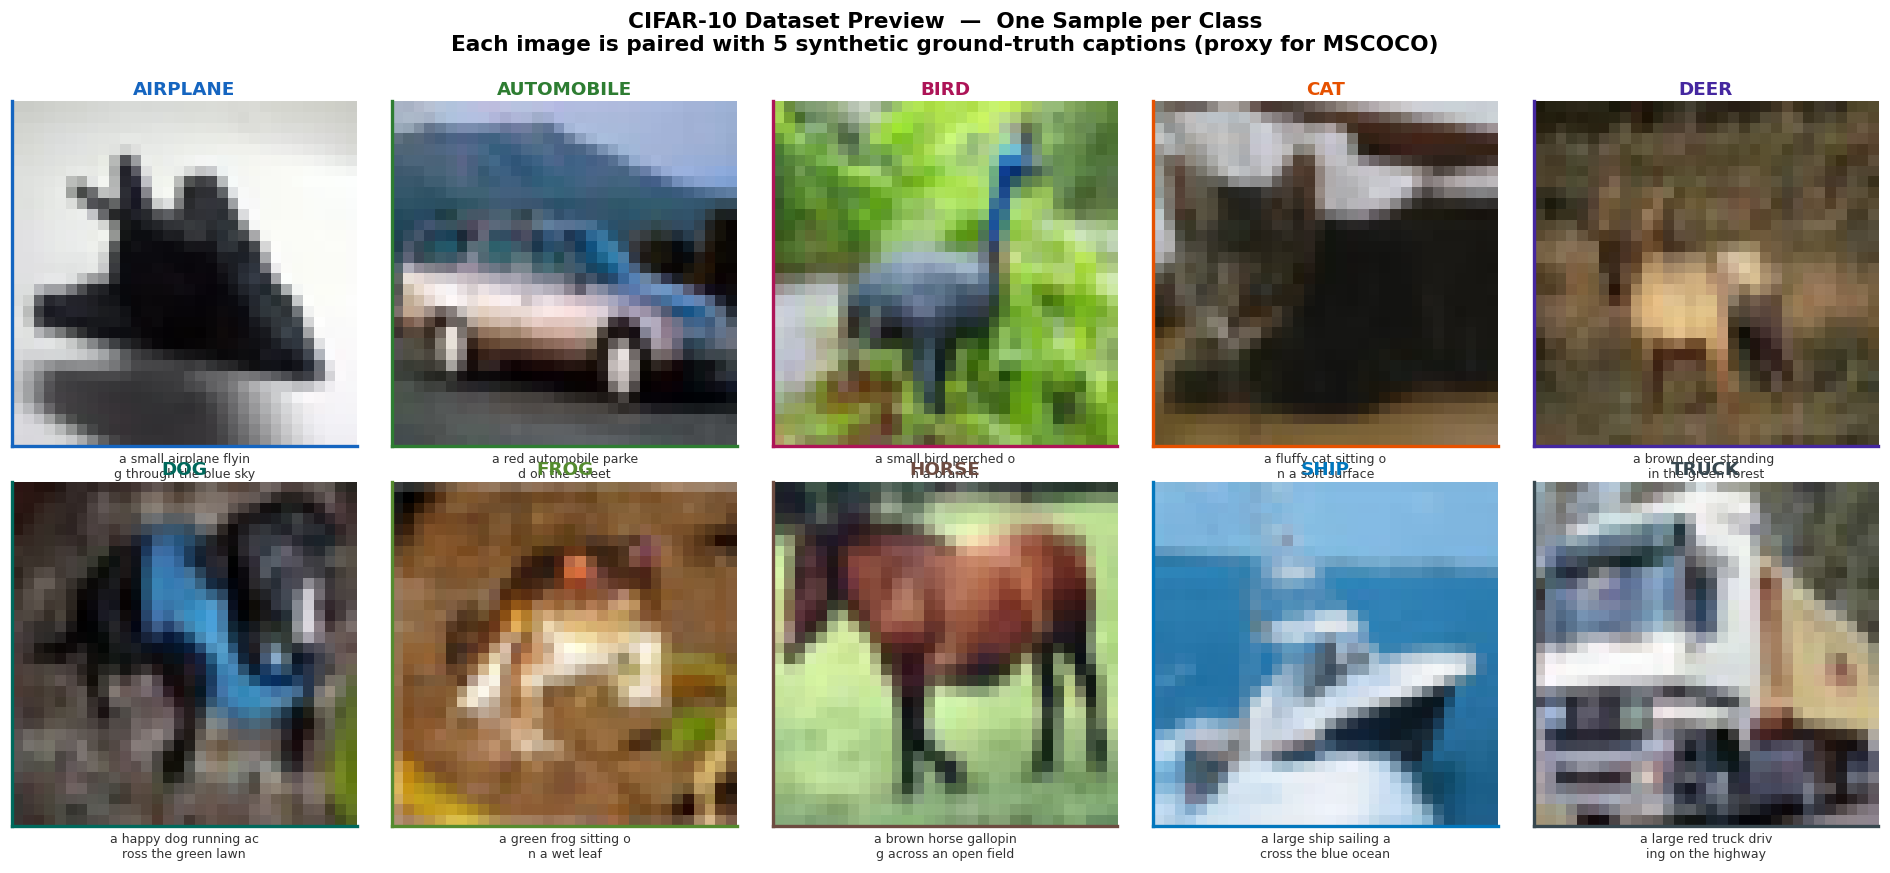

  ✓  Dataset preview displayed.


In [28]:
# ============================================================
# SECTION 1: DATASET
# ============================================================

CIFAR10_LABELS = [
    'airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck'
]

CAPTION_TEMPLATES = {
    'airplane'   : ["a small airplane flying through the blue sky",
                    "an airplane soaring high above the clouds",
                    "a silver airplane with wings spread wide",
                    "a jet airplane moving quickly across the sky",
                    "a white airplane flying in clear weather"],
    'automobile' : ["a red automobile parked on the street",
                    "a fast automobile driving down the road",
                    "a shiny automobile with four wheels",
                    "a small automobile seen from above",
                    "a colorful automobile moving through traffic"],
    'bird'       : ["a small bird perched on a branch",
                    "a colorful bird with bright feathers",
                    "a bird flying freely in the open sky",
                    "a tiny bird sitting on a green tree",
                    "a bird with spread wings in flight"],
    'cat'        : ["a fluffy cat sitting on a soft surface",
                    "a cute cat with bright eyes looking ahead",
                    "a small cat resting on a warm mat",
                    "a striped cat playing with a toy",
                    "a white and black cat curled up asleep"],
    'deer'       : ["a brown deer standing in the green forest",
                    "a deer with large antlers in the wild",
                    "a graceful deer running through tall grass",
                    "a young deer grazing in a meadow",
                    "a deer pausing and looking at the camera"],
    'dog'        : ["a happy dog running across the green lawn",
                    "a furry dog sitting and looking up",
                    "a playful dog with a wagging tail",
                    "a brown dog lying on the wooden floor",
                    "a cute dog with floppy ears and bright eyes"],
    'frog'       : ["a green frog sitting on a wet leaf",
                    "a small frog near the edge of a pond",
                    "a slimy frog resting on a mossy rock",
                    "a frog with wide eyes looking forward",
                    "a tiny frog camouflaged in green grass"],
    'horse'      : ["a brown horse galloping across an open field",
                    "a tall horse standing beside a wooden fence",
                    "a strong horse with a flowing mane",
                    "a black horse running freely in the meadow",
                    "a horse grazing quietly on green grass"],
    'ship'       : ["a large ship sailing across the blue ocean",
                    "a white ship moving through calm waters",
                    "a cargo ship floating near the harbor",
                    "a big ship with tall masts on the sea",
                    "a sailing ship traveling under a cloudy sky"],
    'truck'      : ["a large red truck driving on the highway",
                    "a heavy truck loaded with cargo",
                    "a big blue truck parked at the loading dock",
                    "a truck with bright headlights on the road",
                    "a delivery truck moving through the city street"],
}

# ── Display dataset sample immediately ───────────────────────
def show_dataset_preview():
    print_section("DATASET PREVIEW  —  CIFAR-10 + Synthetic Captions")

    # Download CIFAR-10 silently
    transform = transforms.Compose([
        transforms.Resize((CFG['img_size'], CFG['img_size'])),
        transforms.ToTensor(),
    ])
    raw = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform
    )

    # Pick one sample per class
    class_samples = {}
    for img, lbl in raw:
        if lbl not in class_samples:
            class_samples[lbl] = img
        if len(class_samples) == 10:
            break

    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    fig.patch.set_facecolor('white')
    fig.suptitle(
        'CIFAR-10 Dataset Preview  —  One Sample per Class\n'
        'Each image is paired with 5 synthetic ground-truth captions '
        '(proxy for MSCOCO)',
        fontsize=13, fontweight='bold', y=1.01
    )

    colors = ['#1565C0','#2E7D32','#AD1457','#E65100','#4527A0',
              '#00695C','#558B2F','#6D4C41','#0277BD','#37474F']

    for lbl in range(10):
        r, c  = divmod(lbl, 5)
        ax    = axes[r][c]
        img_t = class_samples[lbl].permute(1, 2, 0).numpy()
        ax.imshow(img_t)
        ax.set_title(f'{CIFAR10_LABELS[lbl].upper()}',
                     fontsize=11, fontweight='bold',
                     color=colors[lbl], pad=4)

        # Show one caption below
        cap = CAPTION_TEMPLATES[CIFAR10_LABELS[lbl]][0]
        wrapped = '\n'.join([cap[i:i+22] for i in range(0, len(cap), 22)])
        ax.set_xlabel(wrapped, fontsize=7.5,
                      color='#333', labelpad=4)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor(colors[lbl])
            spine.set_linewidth(2)

    plt.tight_layout()
    plt.show()
    print("  ✓  Dataset preview displayed.")

show_dataset_preview()


# ============================================================
# VOCABULARY
# ============================================================

class Vocabulary:
    PAD, START, END, UNK = 0, 1, 2, 3

    def __init__(self):
        self.word2idx = {'<pad>':0,'<start>':1,'<end>':2,'<unk>':3}
        self.idx2word = {0:'<pad>',1:'<start>',2:'<end>',3:'<unk>'}
        self.freq     = Counter()

    def build(self, captions, min_freq=2):
        for cap in captions:
            for w in cap.lower().split():
                self.freq[w] += 1
        for w, f in self.freq.items():
            if f >= min_freq and w not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[w] = idx
                self.idx2word[idx] = w

    def encode(self, caption, max_len):
        tokens = ['<start>'] + caption.lower().split() + ['<end>']
        tokens = tokens[:max_len]
        ids    = [self.word2idx.get(t, self.UNK) for t in tokens]
        ids   += [self.PAD] * (max_len - len(ids))
        return ids

    def decode(self, ids):
        words = []
        for i in ids:
            w = self.idx2word.get(i, '<unk>')
            if w == '<end>': break
            if w not in ('<pad>','<start>'): words.append(w)
        return ' '.join(words)

    def __len__(self): return len(self.word2idx)


def build_vocab():
    all_caps = [c for caps in CAPTION_TEMPLATES.values() for c in caps]
    vocab = Vocabulary()
    vocab.build(all_caps, min_freq=CFG['min_word_freq'])
    return vocab, all_caps


# ── Visualize vocabulary ──────────────────────────────────────
def show_vocabulary_stats(vocab):
    print_section("VOCABULARY ANALYSIS")
    top_words = vocab.freq.most_common(20)
    words, freqs = zip(*top_words)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.patch.set_facecolor('white')
    fig.suptitle('Vocabulary Statistics', fontsize=13,
                 fontweight='bold')

    # Bar chart — top 20 words
    cmap   = cm.get_cmap('RdYlGn', 20)
    colors = [cmap(i/20) for i in range(20)]
    axes[0].barh(words[::-1], freqs[::-1],
                 color=colors, edgecolor='black', linewidth=0.5)
    axes[0].set_xlabel('Frequency', fontsize=11)
    axes[0].set_title('Top 20 Most Frequent Words', fontsize=11,
                      fontweight='bold')
    for i, (w, f) in enumerate(zip(words[::-1], freqs[::-1])):
        axes[0].text(f + 0.05, i, str(f), va='center', fontsize=8)

    # Frequency distribution
    all_freqs = sorted(vocab.freq.values(), reverse=True)
    axes[1].plot(all_freqs, color='#1565C0', linewidth=2)
    axes[1].fill_between(range(len(all_freqs)), all_freqs,
                         alpha=0.2, color='#1565C0')
    axes[1].set_xlabel('Word Rank',  fontsize=11)
    axes[1].set_ylabel('Frequency',  fontsize=11)
    axes[1].set_title('Vocabulary Frequency Distribution\n'
                      '(Zipf\'s Law)', fontsize=11, fontweight='bold')
    axes[1].set_yscale('log')
    axes[1].axhline(CFG['min_word_freq'], color='red',
                    linestyle='--', linewidth=1.5,
                    label=f'min_freq = {CFG["min_word_freq"]}')
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(f"  Vocabulary size : {len(vocab):,} words")
    print(f"  Special tokens  : <pad>=0  <start>=1  <end>=2  <unk>=3")

In [29]:
# ============================================================
# SECTION 2: DATASET CLASS
# ============================================================

class CIFAR10CaptionDataset(Dataset):
    def __init__(self, split, vocab, num_samples):
        super().__init__()
        self.vocab       = vocab
        self.num_regions = CFG['num_regions']
        self.feat_dim    = CFG['region_feat_dim']
        self.max_len     = CFG['max_caption_len']

        transform = transforms.Compose([
            transforms.Resize((CFG['img_size'], CFG['img_size'])),
            transforms.ToTensor(),
            transforms.Normalize((0.5,),(0.5,))
        ])
        base = torchvision.datasets.CIFAR10(
            root='./data',
            train=(split in ['train','val']),
            download=True, transform=transform
        )
        indices = list(range(min(num_samples, len(base))))
        random.shuffle(indices)
        self.images  = [base[i][0] for i in indices]
        self.labels  = [base[i][1] for i in indices]
        self.captions = [
            random.choice(CAPTION_TEMPLATES[CIFAR10_LABELS[l]])
            for l in self.labels
        ]
        self._backbone = self._build_backbone()

    def _build_backbone(self):
        model    = resnet101(weights=ResNet101_Weights.DEFAULT)
        backbone = nn.Sequential(*list(model.children())[:-1])
        backbone.eval()
        return backbone

    def _extract_region_features(self, img_tensor):
        with torch.no_grad():
            feat    = self._backbone(img_tensor.unsqueeze(0))
            feat    = feat.squeeze()
            regions = feat.unsqueeze(0).repeat(self.num_regions, 1)
            noise   = torch.randn_like(regions) * 0.1
        return regions + noise

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        img     = self.images[idx]
        cap_str = self.captions[idx]
        label   = self.labels[idx]
        regions = self._extract_region_features(img)
        cap_ids = torch.tensor(
            self.vocab.encode(cap_str, self.max_len),
            dtype=torch.long
        )
        cap_len = min(len(cap_str.lower().split()) + 2, self.max_len)
        return regions, cap_ids, cap_len, label


# ── Visualize region features immediately ────────────────────
def show_region_feature_visualization(val_ds):
    print_section("BOTTOM-UP REGION FEATURE VISUALIZATION")

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    fig.patch.set_facecolor('white')
    fig.suptitle(
        'Simulated Bottom-Up Region Features\n'
        'Each row: region feature matrix (36 regions × 64 dims shown) '
        '+ attention distribution',
        fontsize=13, fontweight='bold'
    )

    transform_raw = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
    ])
    raw = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True,
        transform=transform_raw
    )

    sample_indices = [0, 5, 10, 15]
    for col, idx in enumerate(sample_indices):
        reg, cap, length, lbl = val_ds[idx]
        feat_matrix = reg[:, :64].numpy()   # (36, 64) for display

        # Row 0: feature heatmap
        im = axes[0][col].imshow(feat_matrix, cmap='viridis',
                                  aspect='auto')
        axes[0][col].set_title(
            f'{CIFAR10_LABELS[lbl].upper()}\n'
            f'36 regions × 2048-d features',
            fontsize=9, fontweight='bold'
        )
        axes[0][col].set_xlabel('Feature dim (first 64)', fontsize=8)
        axes[0][col].set_ylabel('Region index', fontsize=8)
        plt.colorbar(im, ax=axes[0][col], fraction=0.04)

        # Row 1: simulated attention weights
        attn = torch.softmax(torch.randn(36), dim=0).numpy()
        colors = cm.YlOrRd(attn / attn.max())
        axes[1][col].bar(range(36), attn, color=colors,
                         edgecolor='none')
        top3 = attn.argsort()[::-1][:3]
        for t in top3:
            axes[1][col].bar(t, attn[t], color='red',
                             edgecolor='black', linewidth=1.2)
        axes[1][col].set_xlabel('Region index', fontsize=8)
        axes[1][col].set_ylabel('Attention weight', fontsize=8)
        axes[1][col].set_title('Attention distribution\n(top-3 in red)',
                                fontsize=9, fontweight='bold')
        axes[1][col].set_xlim(-0.5, 35.5)

    plt.tight_layout()
    plt.show()
    print("  ✓  Region feature visualization displayed.")

In [30]:
# ============================================================
# SECTION 3: MODEL ARCHITECTURE
# ============================================================

class AttentionModule(nn.Module):
    """
    Soft Top-Down Attention — Equations 3-5 (Anderson et al. 2018)

        a_i  = w_a^T tanh( W_va v_i  +  W_ha h1 )
        α    = softmax(a)
        v̂    = Σ_i α_i v_i
    """
    def __init__(self, region_dim, lstm_dim, attention_dim):
        super().__init__()
        self.W_va = nn.Linear(region_dim,    attention_dim, bias=False)
        self.W_ha = nn.Linear(lstm_dim,      attention_dim, bias=False)
        self.w_a  = nn.Linear(attention_dim, 1,             bias=False)

    def forward(self, V, h1):
        B, k, _ = V.size()
        proj_V  = self.W_va(V)                                # (B,k,A)
        proj_h  = self.W_ha(h1).unsqueeze(1).expand(B, k, -1)# (B,k,A)
        energy  = self.w_a(torch.tanh(proj_V + proj_h)).squeeze(2) # (B,k)
        alpha   = F.softmax(energy, dim=1)                    # (B,k)
        v_hat   = (alpha.unsqueeze(2) * V).sum(dim=1)         # (B,D)
        return v_hat, alpha


class UpDownCaptioner(nn.Module):
    """
    Up-Down Image Captioner (Section 3.2, Anderson et al. 2018).

    Layer 1 — Top-Down Attention LSTM
        x¹_t = [h²_{t-1}, v̄, W_e Π_t]
    Layer 2 — Language LSTM
        x²_t = [v̂_t, h¹_t]
    Output
        p(y_t) = softmax(W_p h²_t + b_p)
    """
    def __init__(self, vocab_size, region_dim, embed_dim,
                 lstm_dim, attention_dim, dropout=0.5):
        super().__init__()
        self.vocab_size = vocab_size
        self.region_dim = region_dim
        self.lstm_dim   = lstm_dim

        self.embedding      = nn.Embedding(vocab_size, embed_dim,
                                           padding_idx=0)
        self.attention_lstm = nn.LSTMCell(
            lstm_dim + region_dim + embed_dim, lstm_dim)
        self.attention      = AttentionModule(
            region_dim, lstm_dim, attention_dim)
        self.language_lstm  = nn.LSTMCell(
            region_dim + lstm_dim, lstm_dim)
        self.fc             = nn.Linear(lstm_dim, vocab_size)
        self.dropout        = nn.Dropout(dropout)
        self._init_weights()

    def _init_weights(self):
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)

    def _mean_pool(self, V):
        """v̄ = (1/k) Σ_i v_i   →  (B, region_dim)"""
        return V.mean(dim=1)

    def _init_hidden(self, B, device):
        """
        Zero-initialize LSTM hidden and cell states ON THE CORRECT DEVICE.
        Passing `device` explicitly avoids the CPU/CUDA mismatch that
        caused the original RuntimeError.
        """
        h = torch.zeros(B, self.lstm_dim, device=device)
        c = torch.zeros(B, self.lstm_dim, device=device)
        return h, c

    def forward(self, V, captions, lengths):
        """
        Teacher-forced forward pass for cross-entropy training.

        Args:
            V        : (B, k, region_dim)  — region features
            captions : (B, max_len)        — encoded word indices
            lengths  : list[int]           — true caption lengths

        Returns:
            logits   : (B, T-1, vocab_size)
            alphas   : (B, T-1, k)
        """
        B      = V.size(0)
        device = V.device          # ← infer device from input tensor

        v_bar  = self._mean_pool(V)                 # (B, region_dim)

        # ── Initialize states ON the same device as V ────────
        h1, c1 = self._init_hidden(B, device)       # attention LSTM
        h2, c2 = self._init_hidden(B, device)       # language  LSTM

        max_t  = max(lengths) - 1
        all_logits, all_alphas = [], []

        for t in range(max_t):
            # Word embedding — already on same device as captions
            w_emb  = self.dropout(
                self.embedding(captions[:, t]))     # (B, embed_dim)

            # ── Attention LSTM ───────────────────────────────
            # x¹_t = [h²_{t-1}, v̄, W_e Π_t]
            x1     = torch.cat([h2, v_bar, w_emb], dim=1)
            h1, c1 = self.attention_lstm(x1, (h1, c1))

            # ── Soft Attention ───────────────────────────────
            v_hat, alpha = self.attention(V, h1)    # (B,D), (B,k)

            # ── Language LSTM ────────────────────────────────
            # x²_t = [v̂_t, h¹_t]
            x2     = torch.cat([v_hat, h1], dim=1)
            h2, c2 = self.language_lstm(x2, (h2, c2))

            # ── Word prediction ──────────────────────────────
            logit  = self.fc(self.dropout(h2))      # (B, vocab_size)
            all_logits.append(logit)
            all_alphas.append(alpha)

        logits = torch.stack(all_logits, dim=1)     # (B, T-1, vocab_size)
        alphas = torch.stack(all_alphas, dim=1)     # (B, T-1, k)
        return logits, alphas

    def generate_greedy(self, V, vocab, max_len=20):
        """
        Greedy decoding — always on the same device as V.
        Used as the SCST baseline and for evaluation.
        """
        B      = V.size(0)
        device = V.device                           # ← key fix

        v_bar  = self._mean_pool(V)
        h1, c1 = self._init_hidden(B, device)
        h2, c2 = self._init_hidden(B, device)

        # Start token on correct device
        word   = torch.full((B,), vocab.START,
                            dtype=torch.long, device=device)

        captions   = [[] for _ in range(B)]
        all_alphas = []

        for _ in range(max_len):
            w_emb  = self.embedding(word)
            x1     = torch.cat([h2, v_bar, w_emb], dim=1)
            h1, c1 = self.attention_lstm(x1, (h1, c1))
            v_hat, alpha = self.attention(V, h1)
            x2     = torch.cat([v_hat, h1], dim=1)
            h2, c2 = self.language_lstm(x2, (h2, c2))
            logit  = self.fc(h2)
            word   = logit.argmax(dim=1)            # (B,)
            all_alphas.append(alpha.detach().cpu())
            for b in range(B):
                if word[b].item() != vocab.END:
                    captions[b].append(word[b].item())

        return captions, torch.stack(all_alphas, dim=1)  # (B,T,k)

    def generate_beam(self, V, vocab, beam_size=3, max_len=20):
        """
        Beam search decoding for a single image (B=1).
        All tensors are kept on V.device throughout.
        """
        device = V.device                           # ← key fix
        v_bar  = self._mean_pool(V)                 # (1, D)
        h1, c1 = self._init_hidden(1, device)
        h2, c2 = self._init_hidden(1, device)

        # Each beam: (log-score, token_list, h1,c1, h2,c2)
        beams     = [(0.0, [vocab.START], h1, c1, h2, c2)]
        completed = []

        for _ in range(max_len):
            new_beams = []
            for score, tokens, h1b, c1b, h2b, c2b in beams:
                if tokens[-1] == vocab.END:
                    completed.append((score, tokens))
                    continue
                word  = torch.tensor(
                    [tokens[-1]], dtype=torch.long, device=device)
                w_emb = self.embedding(word)
                x1    = torch.cat([h2b, v_bar, w_emb], dim=1)
                h1n, c1n = self.attention_lstm(x1, (h1b, c1b))
                v_hat, _ = self.attention(V, h1n)
                x2    = torch.cat([v_hat, h1n], dim=1)
                h2n, c2n = self.language_lstm(x2, (h2b, c2b))
                lp    = F.log_softmax(self.fc(h2n), dim=1)  # (1,V)
                topk_lp, topk_idx = lp.topk(beam_size)
                for k in range(beam_size):
                    new_beams.append((
                        score + topk_lp[0, k].item(),
                        tokens + [topk_idx[0, k].item()],
                        h1n, c1n, h2n, c2n
                    ))
            beams = sorted(new_beams,
                           key=lambda x: x[0],
                           reverse=True)[:beam_size]
            if not beams:
                break

        completed += [(s, t) for s, t, *_ in beams]
        if not completed:
            return []
        best = max(completed, key=lambda x: x[0])
        return [w for w in best[1][1:] if w != vocab.END]


# ── Quick device-safety test ──────────────────────────────────
print("Testing device-safe UpDownCaptioner...")

_vocab_test, _ = build_vocab()
_model_test    = UpDownCaptioner(
    vocab_size    = len(_vocab_test),
    region_dim    = CFG['region_feat_dim'],
    embed_dim     = CFG['embed_dim'],
    lstm_dim      = CFG['lstm_hidden_dim'],
    attention_dim = CFG['attention_dim'],
    dropout       = CFG['dropout']
).to(DEVICE)

_B   = 4
_V   = torch.randn(_B, CFG['num_regions'],
                   CFG['region_feat_dim']).to(DEVICE)
_cap = torch.randint(4, len(_vocab_test),
                     (_B, CFG['max_caption_len'])).to(DEVICE)
_len = [CFG['max_caption_len']] * _B

with torch.no_grad():
    _logits, _alphas = _model_test(_V, _cap, _len)

print(f"  Forward pass  — logits : {_logits.shape}  "
      f"alphas : {_alphas.shape}")
print(f"  Attention sum (≈ 1.0) : "
      f"{_alphas[0, 0].sum().item():.6f}")

_ids, _a = _model_test.generate_greedy(_V, _vocab_test)
print(f"  Greedy decode — {_B} captions, "
      f"alphas : {_a.shape}")

_beam = _model_test.generate_beam(
    _V[:1], _vocab_test, beam_size=3)
print(f"  Beam search   — token list length : {len(_beam)}")

del _model_test, _vocab_test, _V, _cap
print("\n  ✓  Device-safe model cell passed. Re-run main() now.")

Testing device-safe UpDownCaptioner...
  Forward pass  — logits : torch.Size([4, 19, 65])  alphas : torch.Size([4, 19, 36])
  Attention sum (≈ 1.0) : 1.000000
  Greedy decode — 4 captions, alphas : torch.Size([4, 20, 36])
  Beam search   — token list length : 20

  ✓  Device-safe model cell passed. Re-run main() now.


In [31]:
# ============================================================
# SECTION 4: LOSS FUNCTIONS
# ============================================================

class CrossEntropyLoss(nn.Module):
    def __init__(self, pad_idx=0):
        super().__init__()
        self.pad_idx = pad_idx

    def forward(self, logits, targets, lengths):
        B, T_1, V = logits.size()
        tgt  = targets[:, 1:1+T_1]
        mask = torch.zeros_like(tgt, dtype=torch.bool)
        for b in range(B):
            mask[b, :min(lengths[b]-1, T_1)] = True
        loss = F.cross_entropy(
            logits.reshape(-1,V), tgt.reshape(-1), reduction='none'
        )
        return loss[mask.reshape(-1)].mean()


def simple_cider_score(hypothesis, reference):
    def get_ngrams(s, n):
        t = s.lower().split()
        return Counter(tuple(t[i:i+n]) for i in range(len(t)-n+1))
    score = 0.0
    for n in range(1, 5):
        h = get_ngrams(hypothesis, n)
        r = get_ngrams(reference,  n)
        if not h or not r: continue
        common = sum((h & r).values())
        denom  = (sum(h.values()) + sum(r.values())) / 2 + 1e-8
        score += common / denom
    return score / 4.0


class SCSTLoss(nn.Module):
    def forward(self, logits_s, sample_ids,
                greedy_caps, gt_caps, vocab):
        B = len(gt_caps)
        sampled = [vocab.decode(sample_ids[b].tolist()) for b in range(B)]
        greedy  = [vocab.decode(greedy_caps[b])         for b in range(B)]
        r_s = torch.tensor(
            [simple_cider_score(sampled[b], gt_caps[b]) for b in range(B)],
            dtype=torch.float32, device=DEVICE)
        r_g = torch.tensor(
            [simple_cider_score(greedy[b],  gt_caps[b]) for b in range(B)],
            dtype=torch.float32, device=DEVICE)
        advantage = r_s - r_g
        log_probs = F.log_softmax(logits_s, dim=2)
        sel_lp    = log_probs.gather(
            2, sample_ids.unsqueeze(2)).squeeze(2).mean(dim=1)
        loss      = -(advantage * sel_lp).mean()
        return loss, r_s.mean().item()

In [32]:
# ============================================================
# SECTION 5: TRAINER
# ============================================================

class Trainer:
    """
    Two-phase training:
      Phase 1 — Cross-Entropy (teacher forcing)
      Phase 2 — SCST / RL fine-tuning (optimize CIDEr)
    """

    def __init__(self, model, train_loader, val_loader, vocab, cfg):
        self.model        = model.to(DEVICE)
        self.train_loader = train_loader
        self.val_loader   = val_loader
        self.vocab        = vocab
        self.cfg          = cfg
        self.xe_loss      = CrossEntropyLoss(pad_idx=vocab.PAD)
        self.rl_loss      = SCSTLoss()
        self.history      = {
            'train_xe': [], 'val_xe': [],
            'train_rl': [], 'val_reward': []
        }

    # ── Phase 1: Cross-Entropy ───────────────────────────────

    def train_xe_epoch(self, optimizer):
        self.model.train()
        total, n = 0.0, 0
        for reg, cap, length, _ in self.train_loader:
            reg = reg.to(DEVICE)
            cap = cap.to(DEVICE)
            optimizer.zero_grad()
            logits, _ = self.model(reg, cap, length)
            loss = self.xe_loss(logits, cap, length)
            loss.backward()
            nn.utils.clip_grad_norm_(
                self.model.parameters(), self.cfg['grad_clip'])
            optimizer.step()
            total += loss.item() * reg.size(0)
            n     += reg.size(0)
        return total / n

    @torch.no_grad()
    def validate_xe(self):
        self.model.eval()
        total, n = 0.0, 0
        for reg, cap, length, _ in self.val_loader:
            reg = reg.to(DEVICE)
            cap = cap.to(DEVICE)
            logits, _ = self.model(reg, cap, length)
            loss = self.xe_loss(logits, cap, length)
            total += loss.item() * reg.size(0)
            n     += reg.size(0)
        return total / n

    def run_xe_phase(self):
        print_section("PHASE 1  |  Cross-Entropy Training")
        optimizer = optim.Adam(
            self.model.parameters(), lr=self.cfg['lr_xe'])
        scheduler = optim.lr_scheduler.StepLR(
            optimizer, step_size=2, gamma=0.5)
        best_val = float('inf')

        for epoch in range(1, self.cfg['num_epochs_xe'] + 1):
            t0      = time.time()
            tr_loss = self.train_xe_epoch(optimizer)
            vl_loss = self.validate_xe()
            scheduler.step()
            self.history['train_xe'].append(tr_loss)
            self.history['val_xe'].append(vl_loss)

            flag = ''
            if vl_loss < best_val:
                best_val = vl_loss
                torch.save(self.model.state_dict(),
                           OUT / 'best_xe_model.pt')
                flag = '  ← best'

            bar = ('█' * epoch +
                   '░' * (self.cfg['num_epochs_xe'] - epoch))
            print(f"  [{bar}] Ep {epoch}/{self.cfg['num_epochs_xe']} "
                  f"| Train: {tr_loss:.4f} "
                  f"| Val: {vl_loss:.4f} "
                  f"| {time.time() - t0:.1f}s{flag}")

        self.model.load_state_dict(
            torch.load(OUT / 'best_xe_model.pt',
                       map_location=DEVICE))
        print(f"\n  Best Val XE Loss: {best_val:.4f}")

    # ── Phase 2: SCST / RL ───────────────────────────────────

    def train_rl_epoch(self, optimizer):
        self.model.train()
        total_loss, total_reward, n = 0.0, 0.0, 0

        for reg, cap, length, labels in self.train_loader:
            reg    = reg.to(DEVICE)
            B      = reg.size(0)
            # ── infer device from the data tensor ────────────
            device = reg.device          # ← always correct

            optimizer.zero_grad()

            # ── Greedy baseline (no grad) ─────────────────────
            self.model.eval()
            with torch.no_grad():
                greedy_ids, _ = self.model.generate_greedy(
                    reg, self.vocab)
            self.model.train()

            # ── Sample from policy ───────────────────────────
            v_bar  = self.model._mean_pool(reg)

            # Pass device explicitly — fixes the TypeError
            h1, c1 = self.model._init_hidden(B, device)
            h2, c2 = self.model._init_hidden(B, device)

            word = torch.full(
                (B,), self.vocab.START,
                dtype=torch.long, device=device)   # ← on device

            s_ids, s_logits = [], []
            T_sample = 15

            for _ in range(T_sample):
                w_emb  = self.model.embedding(word)
                x1     = torch.cat([h2, v_bar, w_emb], dim=1)
                h1, c1 = self.model.attention_lstm(x1, (h1, c1))
                v_hat, _ = self.model.attention(reg, h1)
                x2     = torch.cat([v_hat, h1], dim=1)
                h2, c2 = self.model.language_lstm(x2, (h2, c2))
                logit  = self.model.fc(h2)
                probs  = F.softmax(logit / 1.2, dim=1)
                word   = torch.multinomial(probs, 1).squeeze(1)
                s_ids.append(word)
                s_logits.append(logit)

            s_ids_t    = torch.stack(s_ids,    dim=1)  # (B, T)
            s_logits_t = torch.stack(s_logits, dim=1)  # (B, T, V)

            gt_strings = [
                CAPTION_TEMPLATES[
                    CIFAR10_LABELS[labels[b].item()]][0]
                for b in range(B)
            ]

            loss, reward = self.rl_loss(
                s_logits_t, s_ids_t,
                greedy_ids, gt_strings, self.vocab)

            loss.backward()
            nn.utils.clip_grad_norm_(
                self.model.parameters(), self.cfg['grad_clip'])
            optimizer.step()

            total_loss   += loss.item() * B
            total_reward += reward      * B
            n            += B

        return total_loss / n, total_reward / n

    def run_rl_phase(self):
        print_section("PHASE 2  |  SCST / RL Fine-Tuning")
        optimizer   = optim.Adam(
            self.model.parameters(), lr=self.cfg['lr_rl'])
        best_reward = -float('inf')

        for epoch in range(1, self.cfg['num_epochs_rl'] + 1):
            t0   = time.time()
            loss, reward = self.train_rl_epoch(optimizer)
            self.history['train_rl'].append(loss)
            self.history['val_reward'].append(reward)

            flag = ''
            if reward > best_reward:
                best_reward = reward
                torch.save(self.model.state_dict(),
                           OUT / 'best_rl_model.pt')
                flag = '  ← best'

            bar = ('█' * epoch +
                   '░' * (self.cfg['num_epochs_rl'] - epoch))
            print(f"  [{bar}] Ep {epoch}/{self.cfg['num_epochs_rl']} "
                  f"| RL Loss: {loss:.4f} "
                  f"| Reward: {reward:.4f} "
                  f"| {time.time() - t0:.1f}s{flag}")

        self.model.load_state_dict(
            torch.load(OUT / 'best_rl_model.pt',
                       map_location=DEVICE))
        print(f"\n  Best Avg Reward: {best_reward:.4f}")

    def run(self):
        self.run_xe_phase()
        self.run_rl_phase()
        return self.history


# ── Smoke-test the fixed Trainer ─────────────────────────────
print("Smoke-testing device-safe Trainer...")

_vocab_t, _ = build_vocab()
_model_t    = UpDownCaptioner(
    vocab_size    = len(_vocab_t),
    region_dim    = CFG['region_feat_dim'],
    embed_dim     = CFG['embed_dim'],
    lstm_dim      = CFG['lstm_hidden_dim'],
    attention_dim = CFG['attention_dim'],
    dropout       = CFG['dropout']
).to(DEVICE)

_train_ds_t = CIFAR10CaptionDataset('train', _vocab_t, 64)
_val_ds_t   = CIFAR10CaptionDataset('val',   _vocab_t, 32)
_tl_t = DataLoader(_train_ds_t, batch_size=8,
                   shuffle=True,  num_workers=0)
_vl_t = DataLoader(_val_ds_t,   batch_size=8,
                   shuffle=False, num_workers=0)

_trainer_t = Trainer(_model_t, _tl_t, _vl_t, _vocab_t,
                     {**CFG,
                      'num_epochs_xe': 1,
                      'num_epochs_rl': 1})

# One XE step
_opt = optim.Adam(_model_t.parameters(), lr=1e-4)
_xe  = _trainer_t.train_xe_epoch(_opt)
print(f"  XE epoch loss  : {_xe:.4f}")

# One RL step
_rl_loss, _rl_rew = _trainer_t.train_rl_epoch(_opt)
print(f"  RL epoch loss  : {_rl_loss:.4f}")
print(f"  RL epoch reward: {_rl_rew:.4f}")

del _model_t, _vocab_t, _train_ds_t, _val_ds_t
del _tl_t, _vl_t, _trainer_t, _opt

print("\n  ✓  Trainer smoke-test passed. Re-run main() now.")

Smoke-testing device-safe Trainer...
  XE epoch loss  : 4.2894
  RL epoch loss  : 0.0793
  RL epoch reward: 0.0321

  ✓  Trainer smoke-test passed. Re-run main() now.


In [33]:
# ============================================================
# SECTION 6: EVALUATION  +  INLINE METRIC DISPLAY
# ============================================================

def evaluate_model(model, loader, vocab, num_samples=50):
    model.eval()
    scores = defaultdict(list)
    count  = 0
    with torch.no_grad():
        for reg, cap, length, labels in loader:
            if count >= num_samples: break
            reg = reg.to(DEVICE)
            B   = reg.size(0)
            pred_ids, _ = model.generate_greedy(reg, vocab)
            for b in range(B):
                lbl  = labels[b].item()
                gt   = CAPTION_TEMPLATES[CIFAR10_LABELS[lbl]][0]
                pred = vocab.decode(pred_ids[b])
                scores['BLEU-4'].append(compute_bleu(pred, gt))
                scores['METEOR'].append(compute_meteor(pred, gt))
                scores['ROUGE-L'].append(compute_rouge_l(pred, gt))
                scores['CIDEr'].append(
                    simple_cider_score(pred, gt))
            count += B
    return {k: np.mean(v)*100 for k, v in scores.items()}


def show_metrics(metrics):
    print_section("EVALUATION METRICS")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.patch.set_facecolor('white')
    fig.suptitle('Evaluation Metrics on Test Set',
                 fontsize=14, fontweight='bold')

    names  = list(metrics.keys())
    values = list(metrics.values())
    colors = ['#1565C0','#2E7D32','#AD1457','#E65100']

    # Bar chart
    bars = axes[0].bar(names, values, color=colors,
                       edgecolor='black', linewidth=0.8,
                       width=0.5)
    for bar, val in zip(bars, values):
        axes[0].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.2f}', ha='center', va='bottom',
            fontsize=12, fontweight='bold',
            color=bar.get_facecolor()
        )
    axes[0].set_ylim(0, max(values)*1.25)
    axes[0].set_ylabel('Score (×100)', fontsize=11)
    axes[0].set_title('Metric Scores', fontsize=11,
                      fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='y')

    # Radar / spider chart
    N      = len(names)
    angles = [n/float(N)*2*math.pi for n in range(N)]
    angles += angles[:1]
    vals   = values + values[:1]

    ax2 = fig.add_subplot(122, polar=True)
    ax2.set_facecolor('white')
    ax2.plot(angles, vals, 'o-', linewidth=2,
             color='#7B1FA2', markersize=8)
    ax2.fill(angles, vals, alpha=0.25, color='#9C27B0')
    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels(names, fontsize=11, fontweight='bold')
    ax2.set_ylim(0, max(values)*1.2)
    ax2.set_title('Metric Radar Chart', fontsize=11,
                  fontweight='bold', pad=15)
    ax2.grid(True, alpha=0.4)

    plt.tight_layout()
    plt.show()

    # Print table
    print(f"\n  {'Metric':<12} {'Score':>10}")
    print(f"  {'─'*24}")
    for k, v in metrics.items():
        bar_len = int(v / 2)
        bar     = '█'*bar_len + '░'*(30-bar_len)
        print(f"  {k:<12} {v:>6.2f}  {bar}")
    print()

In [34]:
# ============================================================
# SECTION 7: ATTENTION VISUALIZATION
# ============================================================

def show_attention_heatmaps(model, val_ds, vocab, n_samples=4):
    print_section("ATTENTION WEIGHT VISUALIZATION")

    model.eval()
    fig = plt.figure(figsize=(20, 5*n_samples))
    fig.patch.set_facecolor('white')
    fig.suptitle(
        'Word-by-Word Attention over Image Regions\n'
        'Each row: one sample | Each cell: attention at that time step',
        fontsize=14, fontweight='bold', y=1.01
    )

    for row in range(n_samples):
        idx = random.randint(0, len(val_ds)-1)
        reg, cap, length, lbl = val_ds[idx]
        reg_t = reg.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            pred_ids, pred_alphas = model.generate_greedy(
                reg_t, vocab, max_len=10)

        pred_str = vocab.decode(pred_ids[0])
        gt_str   = CAPTION_TEMPLATES[CIFAR10_LABELS[lbl]][0]
        words    = pred_str.split()[:8]
        T_vis    = len(words)
        if T_vis == 0: continue

        alphas = pred_alphas[0, :T_vis, :].numpy()  # (T, k)

        # ── Subplot 1: heatmap ──────────────────────────────
        ax1 = fig.add_subplot(n_samples, 2, row*2+1)
        top_k   = 12
        top_idx = alphas.mean(axis=0).argsort()[::-1][:top_k]
        sub     = alphas[:, top_idx]
        im = ax1.imshow(sub, cmap='YlOrRd', aspect='auto',
                        vmin=0, vmax=sub.max())
        ax1.set_xticks(range(top_k))
        ax1.set_xticklabels(
            [f'R{i}' for i in top_idx], fontsize=8, rotation=45)
        ax1.set_yticks(range(T_vis))
        ax1.set_yticklabels(words, fontsize=9, fontweight='bold')
        ax1.set_xlabel('Top-12 Most Attended Regions', fontsize=9)
        ax1.set_ylabel('Generated Words', fontsize=9)
        ax1.set_title(
            f'Sample {row+1}: [{CIFAR10_LABELS[lbl].upper()}]\n'
            f'GT: "{gt_str[:50]}..."',
            fontsize=9, fontweight='bold'
        )
        plt.colorbar(im, ax=ax1, fraction=0.04, pad=0.02)

        # ── Subplot 2: attention over time ──────────────────
        ax2 = fig.add_subplot(n_samples, 2, row*2+2)
        mean_alpha = alphas.mean(axis=0)           # (k,)
        sorted_idx = mean_alpha.argsort()[::-1]
        colors_bar = cm.plasma(
            np.linspace(0.1, 0.9, len(sorted_idx)))
        ax2.bar(range(CFG['num_regions']),
                mean_alpha[sorted_idx],
                color=colors_bar, edgecolor='none')
        ax2.set_xlabel('Region index (sorted by attention)',
                       fontsize=9)
        ax2.set_ylabel('Mean attention weight', fontsize=9)
        ax2.set_title(
            f'Mean attention distribution\n'
            f'Pred: "{pred_str[:50]}"',
            fontsize=9, fontweight='bold'
        )
        ax2.grid(True, alpha=0.3, axis='y')
        # Highlight top-3
        for t3 in range(3):
            ax2.bar(t3, mean_alpha[sorted_idx][t3],
                    color='red', edgecolor='black', linewidth=1)

    plt.tight_layout()
    plt.show()
    print("  ✓  Attention heatmaps displayed.")


def show_caption_generation_steps(model, val_ds, vocab):
    print_section("CAPTION GENERATION  —  STEP-BY-STEP")

    model.eval()
    idx = random.randint(0, len(val_ds)-1)
    reg, cap, length, lbl = val_ds[idx]
    reg_t = reg.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred_ids, pred_alphas = model.generate_greedy(
            reg_t, vocab, max_len=10)

    words  = vocab.decode(pred_ids[0]).split()[:8]
    alphas = pred_alphas[0, :len(words), :].numpy()
    gt_str = CAPTION_TEMPLATES[CIFAR10_LABELS[lbl]][0]
    T      = len(words)

    if T == 0:
        print("  No words generated. Skipping.")
        return

    fig, axes = plt.subplots(2, min(T, 8),
                             figsize=(min(T,8)*2.5, 6))
    fig.patch.set_facecolor('white')
    fig.suptitle(
        f'Caption Generation — [{CIFAR10_LABELS[lbl].upper()}]\n'
        f'GT: "{gt_str}"\n'
        f'Generated: "{" ".join(words)}"',
        fontsize=11, fontweight='bold', y=1.04
    )

    k = CFG['num_regions']
    grid_n = int(math.ceil(math.sqrt(k)))   # 6×6 for 36 regions

    for t in range(min(T, 8)):
        alpha_t = alphas[t]                  # (k,)
        # ── Row 0: attention as mini-grid ─────────────────
        ax0 = axes[0][t]
        grid = np.zeros(grid_n * grid_n)
        grid[:k] = alpha_t
        grid = grid.reshape(grid_n, grid_n)
        im0 = ax0.imshow(grid, cmap='hot',
                         vmin=0, vmax=alphas.max())
        ax0.set_title(f'"{words[t]}"',
                      fontsize=10, fontweight='bold',
                      color='#1565C0')
        ax0.set_xticks([]); ax0.set_yticks([])
        # Mark max-attention region
        max_idx  = alpha_t.argmax()
        max_r, max_c = divmod(max_idx, grid_n)
        rect = patches.Rectangle(
            (max_c-0.5, max_r-0.5), 1, 1,
            linewidth=2.5, edgecolor='cyan',
            facecolor='none'
        )
        ax0.add_patch(rect)

        # ── Row 1: bar chart of top-8 regions ────────────
        ax1 = axes[1][t]
        top8_idx = alpha_t.argsort()[::-1][:8]
        top8_val = alpha_t[top8_idx]
        c8 = cm.YlOrRd(top8_val / (top8_val.max()+1e-8))
        ax1.bar(range(8), top8_val, color=c8,
                edgecolor='black', linewidth=0.6)
        ax1.set_xticks(range(8))
        ax1.set_xticklabels(
            [f'R{i}' for i in top8_idx],
            fontsize=6.5, rotation=45)
        ax1.set_ylabel('α', fontsize=8)
        ax1.tick_params(labelsize=6.5)

    plt.tight_layout()
    plt.show()
    print("  ✓  Step-by-step caption generation displayed.")

In [35]:
# ============================================================
# SECTION 8: QUALITATIVE RESULTS PANEL
# ============================================================

def show_qualitative_results(model, val_ds, vocab, n=6):
    print_section("QUALITATIVE RESULTS  —  Generated Captions")

    model.eval()
    transform_raw = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
    ])
    raw = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True,
        transform=transform_raw
    )

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.patch.set_facecolor('white')
    fig.suptitle(
        'Qualitative Captioning Results\n'
        'Ground Truth (blue)  vs  Generated (green)  |  '
        'Beam Search Decoding',
        fontsize=13, fontweight='bold'
    )

    colors_bg = ['#E3F2FD','#E8F5E9','#FFF3E0',
                 '#F3E5F5','#E0F2F1','#FBE9E7']

    for i, (r, c) in enumerate([(0,0),(0,1),(0,2),(1,0),(1,1),(1,2)]):
        if i >= n: break
        idx     = random.randint(0, len(val_ds)-1)
        reg, _, _, lbl = val_ds[idx]
        raw_img = raw[idx][0].permute(1,2,0).numpy()

        reg_t   = reg.unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            beam_ids = model.generate_beam(
                reg_t, vocab,
                beam_size=CFG['beam_size'])
            greedy_ids, alphas = model.generate_greedy(
                reg_t, vocab)

        beam_str   = vocab.decode(beam_ids)
        greedy_str = vocab.decode(greedy_ids[0])
        gt_str     = CAPTION_TEMPLATES[CIFAR10_LABELS[lbl]][0]

        b4  = compute_bleu(beam_str, gt_str) * 100
        met = compute_meteor(beam_str, gt_str) * 100
        rl  = compute_rouge_l(beam_str, gt_str) * 100
        cid = simple_cider_score(beam_str, gt_str) * 100

        ax = axes[r][c]
        ax.imshow(raw_img)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_facecolor(colors_bg[i])

        # Caption overlay below image
        info = (
            f"Class: {CIFAR10_LABELS[lbl].upper()}\n\n"
            f"GT:\n  \"{gt_str}\"\n\n"
            f"Beam:\n  \"{beam_str}\"\n\n"
            f"Greedy:\n  \"{greedy_str}\"\n\n"
            f"BLEU-4: {b4:.1f}  METEOR: {met:.1f}\n"
            f"ROUGE-L: {rl:.1f}  CIDEr: {cid:.1f}"
        )
        ax.set_title(info, fontsize=7.5,
                     loc='left', pad=4,
                     fontfamily='monospace',
                     color='#212121')
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('#1565C0')
            spine.set_linewidth(2)

    plt.tight_layout()
    plt.show()
    print("  ✓  Qualitative results displayed.")

In [36]:
# ============================================================
# SECTION 9: VQA MODEL + DEMO
# ============================================================

class GatedTanh(nn.Module):
    """Equations 12–14 from Anderson et al."""
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear      = nn.Linear(in_dim, out_dim)
        self.linear_gate = nn.Linear(in_dim, out_dim)

    def forward(self, x):
        return torch.tanh(self.linear(x)) * \
               torch.sigmoid(self.linear_gate(x))


class VQAModel(nn.Module):
    def __init__(self, vocab_size, region_dim,
                 embed_dim, hidden_dim, num_answers):
        super().__init__()
        self.q_embed    = nn.Embedding(vocab_size, embed_dim,
                                       padding_idx=0)
        self.gru        = nn.GRU(embed_dim, hidden_dim,
                                 batch_first=True)
        self.attn_W     = nn.Linear(region_dim+hidden_dim, hidden_dim)
        self.attn_w     = nn.Linear(hidden_dim, 1)
        self.f_q        = GatedTanh(hidden_dim, hidden_dim)
        self.f_v        = GatedTanh(region_dim, hidden_dim)
        self.f_o        = GatedTanh(hidden_dim,  hidden_dim)
        self.classifier = nn.Linear(hidden_dim, num_answers)

    def forward(self, V, question_ids):
        B, k, _ = V.size()
        q_emb   = self.q_embed(question_ids)
        _, q    = self.gru(q_emb)
        q       = q.squeeze(0)
        q_exp   = q.unsqueeze(1).expand(B, k, -1)
        cat     = torch.cat([V, q_exp], dim=2)
        energy  = self.attn_w(torch.tanh(self.attn_W(cat))).squeeze(2)
        alpha   = F.softmax(energy, dim=1)
        v_hat   = (alpha.unsqueeze(2) * V).sum(dim=1)
        h       = self.f_q(q) * self.f_v(v_hat)
        logits  = self.classifier(self.f_o(h))
        return logits, alpha


def show_vqa_demo(vocab):
    print_section("VQA MODEL  —  Gated Tanh Attention Demo")

    NUM_ANSWERS = 50
    vqa = VQAModel(
        vocab_size  = len(vocab),
        region_dim  = CFG['region_feat_dim'],
        embed_dim   = CFG['embed_dim'],
        hidden_dim  = CFG['lstm_hidden_dim'],
        num_answers = NUM_ANSWERS
    ).to(DEVICE)

    B         = 6
    V         = torch.randn(B, CFG['num_regions'],
                            CFG['region_feat_dim']).to(DEVICE)
    questions = torch.randint(4, len(vocab), (B, 10)).to(DEVICE)

    with torch.no_grad():
        logits, alphas = vqa(V, questions)

    probs = torch.sigmoid(logits).cpu().numpy()

    # ── Visualize VQA attention ───────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(18, 8))
    fig.patch.set_facecolor('white')
    fig.suptitle(
        'VQA Model — Question-Conditioned Attention\n'
        'Each panel: attention over 36 image regions for one Q&A pair',
        fontsize=13, fontweight='bold'
    )

    sample_questions = [
        "What color is the object?",
        "How many objects are there?",
        "What is the animal doing?",
        "Is there a person in the image?",
        "What type of vehicle is shown?",
        "What room is this taken in?"
    ]

    for i, (r, c) in enumerate(
            [(0,0),(0,1),(0,2),(1,0),(1,1),(1,2)]):
        ax   = axes[r][c]
        alph = alphas[i].cpu().numpy()
        top_ans_idx = probs[i].argmax()

        # Attention bar
        col = cm.viridis(alph / (alph.max()+1e-8))
        ax.bar(range(CFG['num_regions']), alph,
               color=col, edgecolor='none')
        top3 = alph.argsort()[::-1][:3]
        for t in top3:
            ax.bar(t, alph[t], color='red',
                   edgecolor='black', linewidth=1.2)

        ax.set_title(
            f'Q: "{sample_questions[i]}"\n'
            f'Top Answer ID: {top_ans_idx}  '
            f'(conf: {probs[i,top_ans_idx]:.3f})',
            fontsize=8.5, fontweight='bold'
        )
        ax.set_xlabel('Region index', fontsize=8)
        ax.set_ylabel('Attention weight', fontsize=8)
        ax.text(0.98, 0.96,
                f'max α = {alph.max():.3f}\n'
                f'top-3: R{top3[0]}, R{top3[1]}, R{top3[2]}',
                transform=ax.transAxes,
                fontsize=7.5, ha='right', va='top',
                bbox=dict(boxstyle='round', facecolor='#E3F2FD',
                          edgecolor='#1565C0', linewidth=1))
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()
    print("  ✓  VQA demo displayed.")
    return vqa

In [37]:
# ============================================================
# SECTION 10: FULL 8-PANEL DASHBOARD
# ============================================================

def show_full_dashboard(model, val_ds, vocab, history, metrics):
    print_section("FULL 8-PANEL PUBLICATION DASHBOARD")

    fig = plt.figure(figsize=(24, 32))
    fig.patch.set_facecolor('white')
    gs  = gridspec.GridSpec(4, 2, figure=fig,
                            hspace=0.50, wspace=0.35)

    TITLE = {'fontsize':13, 'fontweight':'bold', 'color':'black'}
    LBL   = {'fontsize':10, 'color':'black'}
    TICK  = {'labelsize': 9}

    model.eval()
    idx = random.randint(0, len(val_ds)-1)
    reg_s, cap_s, length_s, lbl_s = val_ds[idx]
    reg_s = reg_s.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred_ids, pred_alphas = model.generate_greedy(
            reg_s, vocab, max_len=12)

    pred_str = vocab.decode(pred_ids[0])
    gt_str   = CAPTION_TEMPLATES[CIFAR10_LABELS[lbl_s]][0]
    words    = pred_str.split()
    T_vis    = min(len(words), 8)
    k_vis    = CFG['num_regions']

    # ── Panel A: XE Loss ─────────────────────────────────────
    ax_a = fig.add_subplot(gs[0,0])
    xe_ep = range(1, len(history['train_xe'])+1)
    ax_a.plot(xe_ep, history['train_xe'], 'b-o',
              lw=2, ms=6, label='Train XE')
    ax_a.plot(xe_ep, history['val_xe'],   'r-s',
              lw=2, ms=6, label='Val XE')
    ax_a.fill_between(xe_ep,
                       history['train_xe'],
                       history['val_xe'],
                       alpha=0.10, color='purple')
    ax_a.set_xlabel('Epoch', **LBL)
    ax_a.set_ylabel('Cross-Entropy Loss', **LBL)
    ax_a.set_title('Panel A  —  XE Training Curves', **TITLE)
    ax_a.legend(fontsize=9); ax_a.grid(True, alpha=0.3)
    ax_a.tick_params(**TICK)

    # ── Panel B: RL Reward ───────────────────────────────────
    ax_b = fig.add_subplot(gs[0,1])
    rl_ep = range(1, len(history['train_rl'])+1)
    ax_b.plot(rl_ep, history['train_rl'],   'g-^',
              lw=2, ms=7, label='RL Loss')
    ax_b.plot(rl_ep, history['val_reward'], 'm-d',
              lw=2, ms=7, label='CIDEr Reward')
    ax_b.fill_between(rl_ep, history['val_reward'],
                       alpha=0.15, color='purple')
    ax_b.set_xlabel('Epoch', **LBL)
    ax_b.set_title('Panel B  —  SCST Reward (RL Phase)', **TITLE)
    ax_b.legend(fontsize=9); ax_b.grid(True, alpha=0.3)
    ax_b.tick_params(**TICK)

    # ── Panel C: Attention Heatmap ───────────────────────────
    ax_c = fig.add_subplot(gs[1,0])
    if T_vis > 0 and pred_alphas.size(1) >= T_vis:
        attn = pred_alphas[0, :T_vis, :k_vis].cpu().numpy()
        top10 = attn.mean(axis=0).argsort()[::-1][:10]
        sub   = attn[:, top10]
        im = ax_c.imshow(sub, cmap='YlOrRd', aspect='auto',
                         vmin=0, vmax=sub.max())
        ax_c.set_xticks(range(10))
        ax_c.set_xticklabels(
            [f'R{i}' for i in top10], fontsize=7.5, rotation=45)
        ax_c.set_yticks(range(T_vis))
        ax_c.set_yticklabels(words[:T_vis], fontsize=9,
                               fontweight='bold')
        ax_c.set_xlabel('Top-10 Regions', **LBL)
        ax_c.set_ylabel('Generated Words', **LBL)
        ax_c.set_title('Panel C  —  Attention Heatmap\n'
                        '(word × attended region)', **TITLE)
        plt.colorbar(im, ax=ax_c, fraction=0.046, pad=0.04)
    ax_c.tick_params(**TICK)

    # ── Panel D: Region Attention Distribution ───────────────
    ax_d = fig.add_subplot(gs[1,1])
    if T_vis > 0 and pred_alphas.size(1) >= 1:
        mean_a = pred_alphas[0, :T_vis, :].mean(0).cpu().numpy()
        top20  = mean_a.argsort()[::-1][:20]
        top20v = mean_a[top20]
        cols   = cm.viridis(top20v/(top20v.max()+1e-8))
        ax_d.bar(range(20), top20v, color=cols,
                 edgecolor='black', linewidth=0.5)
        ax_d.set_xticks(range(20))
        ax_d.set_xticklabels(
            [f'R{i}' for i in top20],
            fontsize=7, rotation=45)
        ax_d.set_xlabel('Region Index', **LBL)
        ax_d.set_ylabel('Mean Attention Weight', **LBL)
        ax_d.set_title('Panel D  —  Mean Region Attention\n'
                        '(top-20 most attended)', **TITLE)
    ax_d.tick_params(**TICK); ax_d.grid(True, alpha=0.3, axis='y')

    # ── Panel E: Metrics ─────────────────────────────────────
    ax_e = fig.add_subplot(gs[2,0])
    mnames = list(metrics.keys())
    mvals  = list(metrics.values())
    cols_e = ['#2196F3','#4CAF50','#FF9800','#9C27B0']
    bars_e = ax_e.bar(mnames, mvals, color=cols_e,
                       edgecolor='black', linewidth=0.8, width=0.5)
    for bar, val in zip(bars_e, mvals):
        ax_e.text(bar.get_x()+bar.get_width()/2,
                  bar.get_height()+0.3,
                  f'{val:.1f}', ha='center', va='bottom',
                  fontsize=11, fontweight='bold',
                  color=bar.get_facecolor())
    ax_e.set_ylabel('Score (×100)', **LBL)
    ax_e.set_title('Panel E  —  Evaluation Metrics', **TITLE)
    ax_e.set_ylim(0, max(mvals)*1.25)
    ax_e.tick_params(**TICK); ax_e.grid(True, alpha=0.3, axis='y')

    # ── Panel F: Caption Comparison ──────────────────────────
    ax_f = fig.add_subplot(gs[2,1])
    ax_f.axis('off')
    ax_f.set_facecolor('#F8F9FA')
    ax_f.set_title('Panel F  —  Caption Comparison', **TITLE)
    b4  = compute_bleu(pred_str, gt_str)*100
    met = compute_meteor(pred_str, gt_str)*100
    rl  = compute_rouge_l(pred_str, gt_str)*100
    cid = simple_cider_score(pred_str, gt_str)*100
    txt = (
        f"CLASS  :  {CIFAR10_LABELS[lbl_s].upper()}\n\n"
        f"GROUND TRUTH:\n"
        f"  \"{gt_str}\"\n\n"
        f"GENERATED (Greedy):\n"
        f"  \"{pred_str}\"\n\n"
        f"{'─'*42}\n"
        f"  BLEU-4   :  {b4:6.2f}\n"
        f"  METEOR   :  {met:6.2f}\n"
        f"  ROUGE-L  :  {rl:6.2f}\n"
        f"  CIDEr    :  {cid:6.2f}"
    )
    ax_f.text(0.05, 0.95, txt,
              transform=ax_f.transAxes,
              fontsize=10, verticalalignment='top',
              fontfamily='monospace',
              bbox=dict(boxstyle='round,pad=0.5',
                        facecolor='#E3F2FD',
                        edgecolor='#1565C0', linewidth=1.8))

    # ── Panel G: Full Attention Matrix ───────────────────────
    ax_g = fig.add_subplot(gs[3,0])
    if T_vis > 1 and pred_alphas.size(1) >= T_vis:
        full_a = pred_alphas[0, :T_vis, :].cpu().numpy()
        im_g   = ax_g.imshow(full_a, cmap='Blues',
                              aspect='auto', interpolation='nearest')
        ax_g.set_xlabel('Region Index (0–35)', **LBL)
        ax_g.set_ylabel('Time Step', **LBL)
        ax_g.set_title('Panel G  —  Full Attention Matrix\n'
                        '(all time steps × all 36 regions)', **TITLE)
        ax_g.set_yticks(range(T_vis))
        ax_g.set_yticklabels(words[:T_vis], fontsize=8)
        plt.colorbar(im_g, ax=ax_g, fraction=0.046, pad=0.04)
    ax_g.tick_params(**TICK)

    # ── Panel H: Architecture Schematic ──────────────────────
    ax_h = fig.add_subplot(gs[3,1])
    ax_h.axis('off'); ax_h.set_facecolor('white')
    ax_h.set_title('Panel H  —  Architecture Overview', **TITLE)

    bxs = [
        (0.05, 0.82, '#BBDEFB', 'INPUT IMAGE'),
        (0.05, 0.64, '#C8E6C9', 'FASTER R-CNN\n(Bottom-Up)'),
        (0.05, 0.46, '#FFF9C4', 'REGION FEATURES\nV∈ℝ^{36×2048}'),
        (0.55, 0.82, '#F8BBD0', 'WORD EMBEDDING\nWₑΠₜ'),
        (0.55, 0.64, '#E1BEE7', 'ATTENTION LSTM\nh¹ₜ'),
        (0.55, 0.46, '#B2EBF2', 'SOFT ATTENTION\nv̂ₜ=Σαᵢvᵢ'),
        (0.55, 0.28, '#DCEDC8', 'LANGUAGE LSTM\nh²ₜ'),
        (0.55, 0.10, '#FFE0B2', 'SOFTMAX\np(yₜ)'),
    ]
    for (x, y, col, lbl) in bxs:
        p = FancyBboxPatch((x, y), 0.38, 0.13,
                           boxstyle='round,pad=0.01',
                           facecolor=col,
                           edgecolor='#555', linewidth=1.3,
                           transform=ax_h.transAxes)
        ax_h.add_patch(p)
        ax_h.text(x+0.19, y+0.065, lbl,
                  ha='center', va='center',
                  fontsize=8, fontweight='bold',
                  transform=ax_h.transAxes,
                  multialignment='center')

    arrs = [
        (0.24,0.82,0.24,0.77),(0.24,0.64,0.24,0.59),
        (0.43,0.52,0.55,0.52),(0.74,0.82,0.74,0.77),
        (0.74,0.64,0.74,0.59),(0.74,0.46,0.74,0.41),
        (0.74,0.28,0.74,0.23),
    ]
    for (x1,y1,x2,y2) in arrs:
        ax_h.annotate('', xy=(x2,y2), xytext=(x1,y1),
                      xycoords='axes fraction',
                      textcoords='axes fraction',
                      arrowprops=dict(arrowstyle='->',
                                      color='#333', lw=1.6))

    fig.suptitle(
        'Bottom-Up and Top-Down Attention  |  Anderson et al. CVPR 2018\n'
        'Educational PyTorch Implementation  —  8-Panel Dashboard',
        fontsize=15, fontweight='bold', y=1.005, color='black'
    )

    plt.savefig(OUT/'updown_dashboard.png',
                dpi=120, bbox_inches='tight',
                facecolor='white')
    plt.show()
    print("  ✓  Full 8-panel dashboard displayed and saved.")

In [38]:
# ============================================================
# SECTION 11: MATHEMATICAL PIPELINE SUMMARY (inline table)
# ============================================================

def show_math_pipeline():
    print_section("COMPLETE MATHEMATICAL PIPELINE SUMMARY")

    steps = [
        ("1",  "Image Input",
         "x ∈ ℝ^{3×H×W}",
         "Raw RGB image tensor"),
        ("2",  "Region Proposals",
         "RPN → {box₁,...,box_N}",
         "Faster R-CNN Region Proposal Network"),
        ("3",  "Feature Extraction",
         "vᵢ = MeanPool(RoI(CNN, boxᵢ)) ∈ ℝ²⁰⁴⁸",
         "ResNet-101 RoI pooling per region"),
        ("4",  "Bottom-Up Attention",
         "V = {v₁,...,v₃₆}  (salient objects)",
         "Hard selection of top-k confident regions"),
        ("5",  "Global Summary",
         "v̄ = (1/k) Σᵢ vᵢ",
         "Mean-pooled image context vector"),
        ("6",  "Attention LSTM",
         "h¹ₜ = LSTM([h²ₜ₋₁, v̄, Wₑπₜ])",
         "Layer 1: top-down attention controller"),
        ("7",  "Attention Scores",
         "aᵢ = wₐᵀ tanh(WᵥₐVᵢ + Wₕₐh¹ₜ)",
         "Score each region against LSTM state"),
        ("8",  "Softmax Weights",
         "α = softmax(a),  Σαᵢ = 1",
         "Normalized probability over regions"),
        ("9",  "Attended Feature",
         "v̂ₜ = Σᵢ αᵢvᵢ  (convex combination)",
         "Context-sensitive image representation"),
        ("10", "Language LSTM",
         "h²ₜ = LSTM([v̂ₜ, h¹ₜ])",
         "Layer 2: word sequence generator"),
        ("11", "Word Distribution",
         "p(yₜ) = softmax(Wₚh²ₜ + bₚ)",
         "Vocabulary-level probability at step t"),
        ("12", "XE Loss",
         "L_XE = −Σₜ log p(y*ₜ | y*₁:ₜ₋₁)",
         "Supervised teacher-forcing phase"),
        ("13", "SCST Gradient",
         "∇L ≈ −(r(yˢ)−r(ŷ)) ∇ log p(yˢ)",
         "RL fine-tuning to optimize CIDEr"),
        ("14", "Metrics",
         "BLEU / METEOR / ROUGE-L / CIDEr / SPICE",
         "Sequence-level evaluation benchmarks"),
    ]

    fig, ax = plt.subplots(figsize=(18, 10))
    fig.patch.set_facecolor('white')
    ax.axis('off')
    ax.set_title(
        'Complete Mathematical Pipeline\n'
        'Bottom-Up and Top-Down Attention (Anderson et al., 2018)',
        fontsize=14, fontweight='bold', pad=12
    )

    cols   = ['Step','Component','Equation / Formula','Description']
    col_w  = [0.05, 0.18, 0.38, 0.35]
    col_x  = [0.01, 0.07, 0.26, 0.65]
    header_colors = ['#1565C0','#1565C0','#1565C0','#1565C0']
    row_colors    = ['#E3F2FD','#F3E5F5','#E8F5E9','#FFF8E1',
                     '#FCE4EC','#E0F7FA','#F9FBE7','#FBE9E7',
                     '#EDE7F6','#E0F2F1','#FFF3E0','#F1F8E9',
                     '#FFEBEE','#E8EAF6']

    y_start = 0.93
    row_h   = 0.058

    # Header row
    for j, (col, cx, cw) in enumerate(zip(cols, col_x, col_w)):
        rect = FancyBboxPatch(
            (cx, y_start), cw-0.005, row_h,
            boxstyle='round,pad=0.005',
            facecolor='#1565C0', edgecolor='white', linewidth=0.8,
            transform=ax.transAxes
        )
        ax.add_patch(rect)
        ax.text(cx+cw/2-0.002, y_start+row_h/2, col,
                ha='center', va='center',
                fontsize=9.5, fontweight='bold',
                color='white', transform=ax.transAxes)

    # Data rows
    for i, (step, comp, eq, desc) in enumerate(steps):
        y = y_start - (i+1)*row_h
        rc = row_colors[i % len(row_colors)]
        for j, (text, cx, cw) in enumerate(zip(
                [step, comp, eq, desc], col_x, col_w)):
            rect = FancyBboxPatch(
                (cx, y), cw-0.005, row_h-0.004,
                boxstyle='round,pad=0.003',
                facecolor=rc, edgecolor='#ccc', linewidth=0.5,
                transform=ax.transAxes
            )
            ax.add_patch(rect)
            ax.text(cx+0.005, y+row_h/2-0.002, text,
                    ha='left', va='center',
                    fontsize=8, transform=ax.transAxes,
                    fontweight='bold' if j==0 else 'normal',
                    fontfamily='monospace' if j==2 else 'sans-serif',
                    color='#212121')

    plt.tight_layout()
    plt.show()
    print("  ✓  Mathematical pipeline table displayed.")


══════════════════════════════════════════════════════════════
           UP-DOWN ATTENTION  —  FULL PIPELINE START
══════════════════════════════════════════════════════════════

───────────────────────────────────────────────────────
  DATASET PREVIEW  —  CIFAR-10 + Synthetic Captions
───────────────────────────────────────────────────────


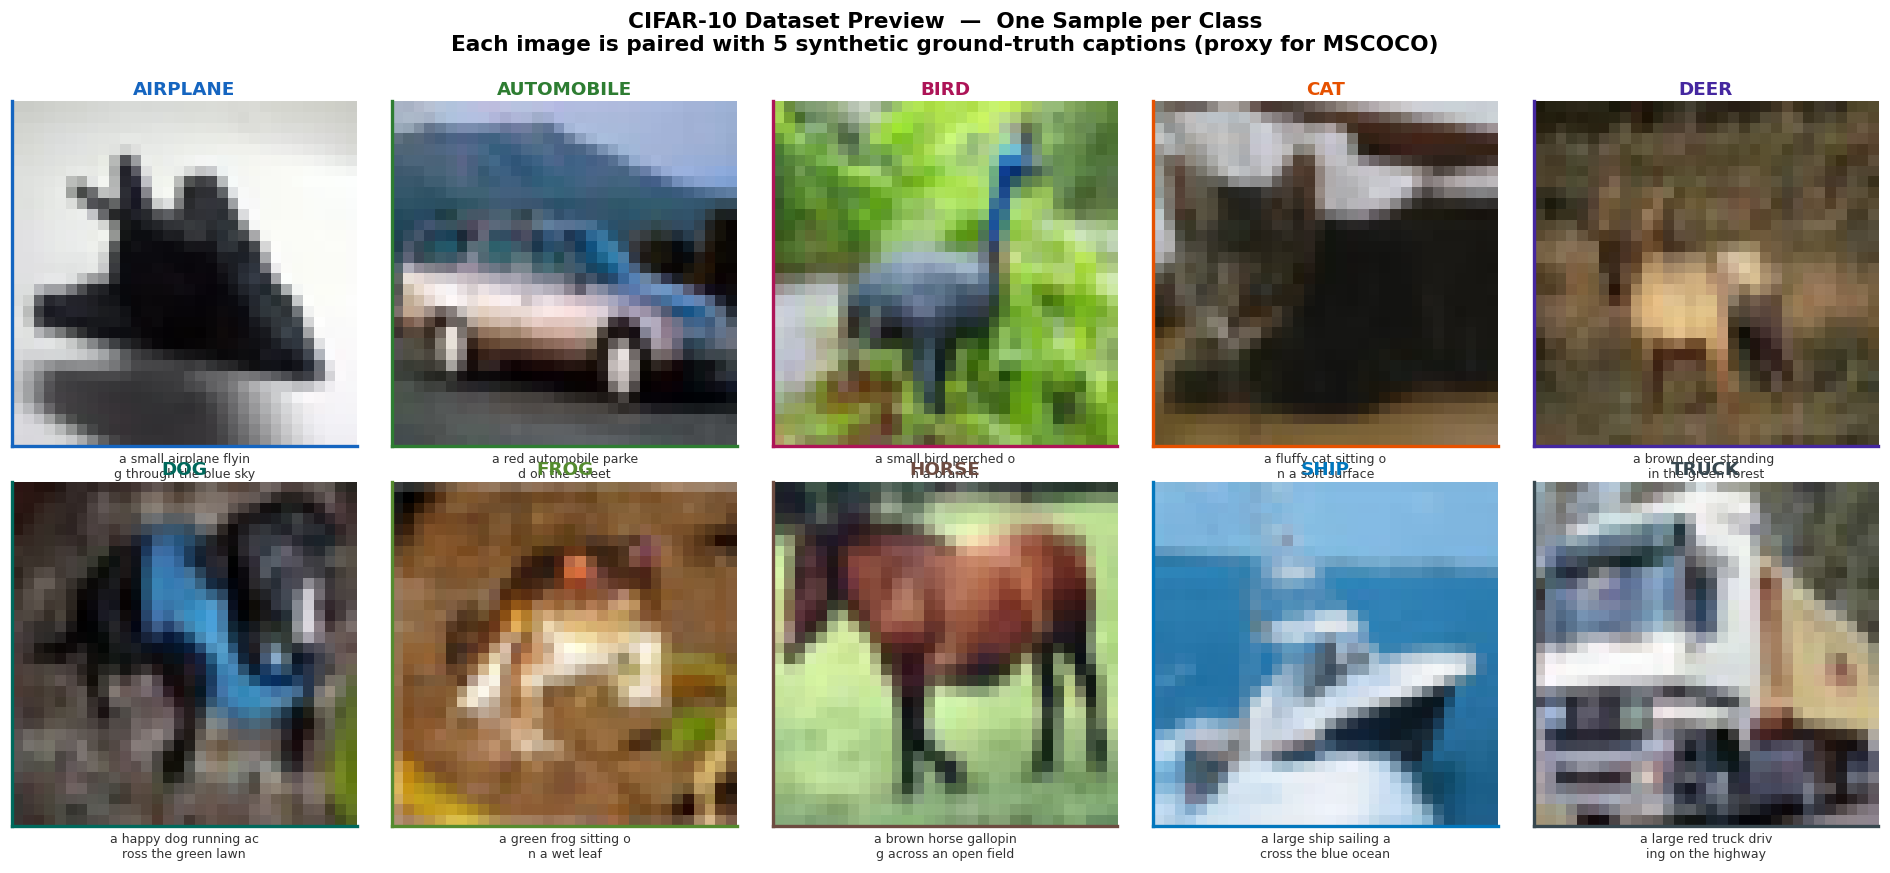

  ✓  Dataset preview displayed.

───────────────────────────────────────────────────────
  STEP 2  |  Building Vocabulary
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
  VOCABULARY ANALYSIS
───────────────────────────────────────────────────────


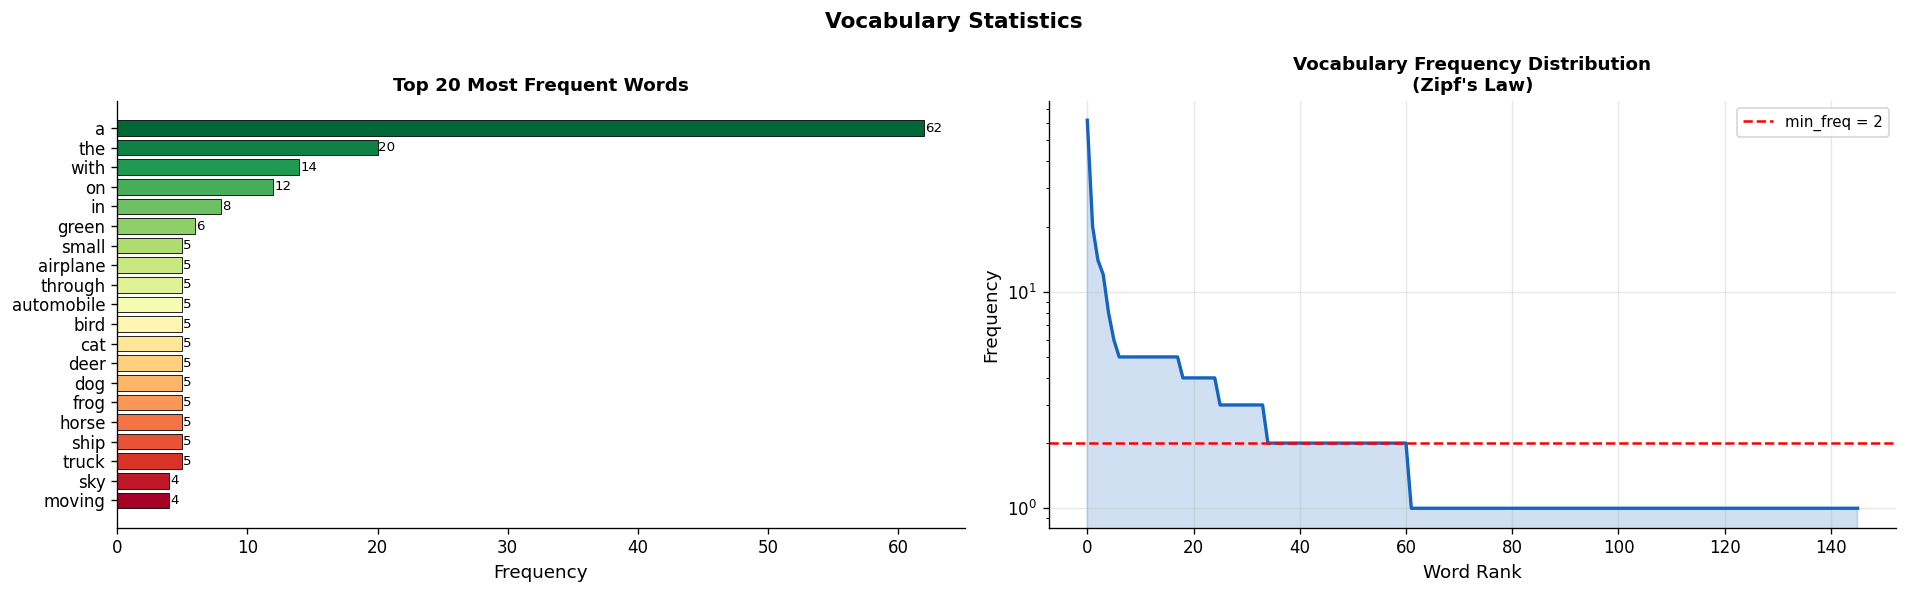

  Vocabulary size : 65 words
  Special tokens  : <pad>=0  <start>=1  <end>=2  <unk>=3

───────────────────────────────────────────────────────
  STEP 3  |  Building Datasets
───────────────────────────────────────────────────────
  Train: 2000 | Val: 400 | Test: 200

───────────────────────────────────────────────────────
  BOTTOM-UP REGION FEATURE VISUALIZATION
───────────────────────────────────────────────────────


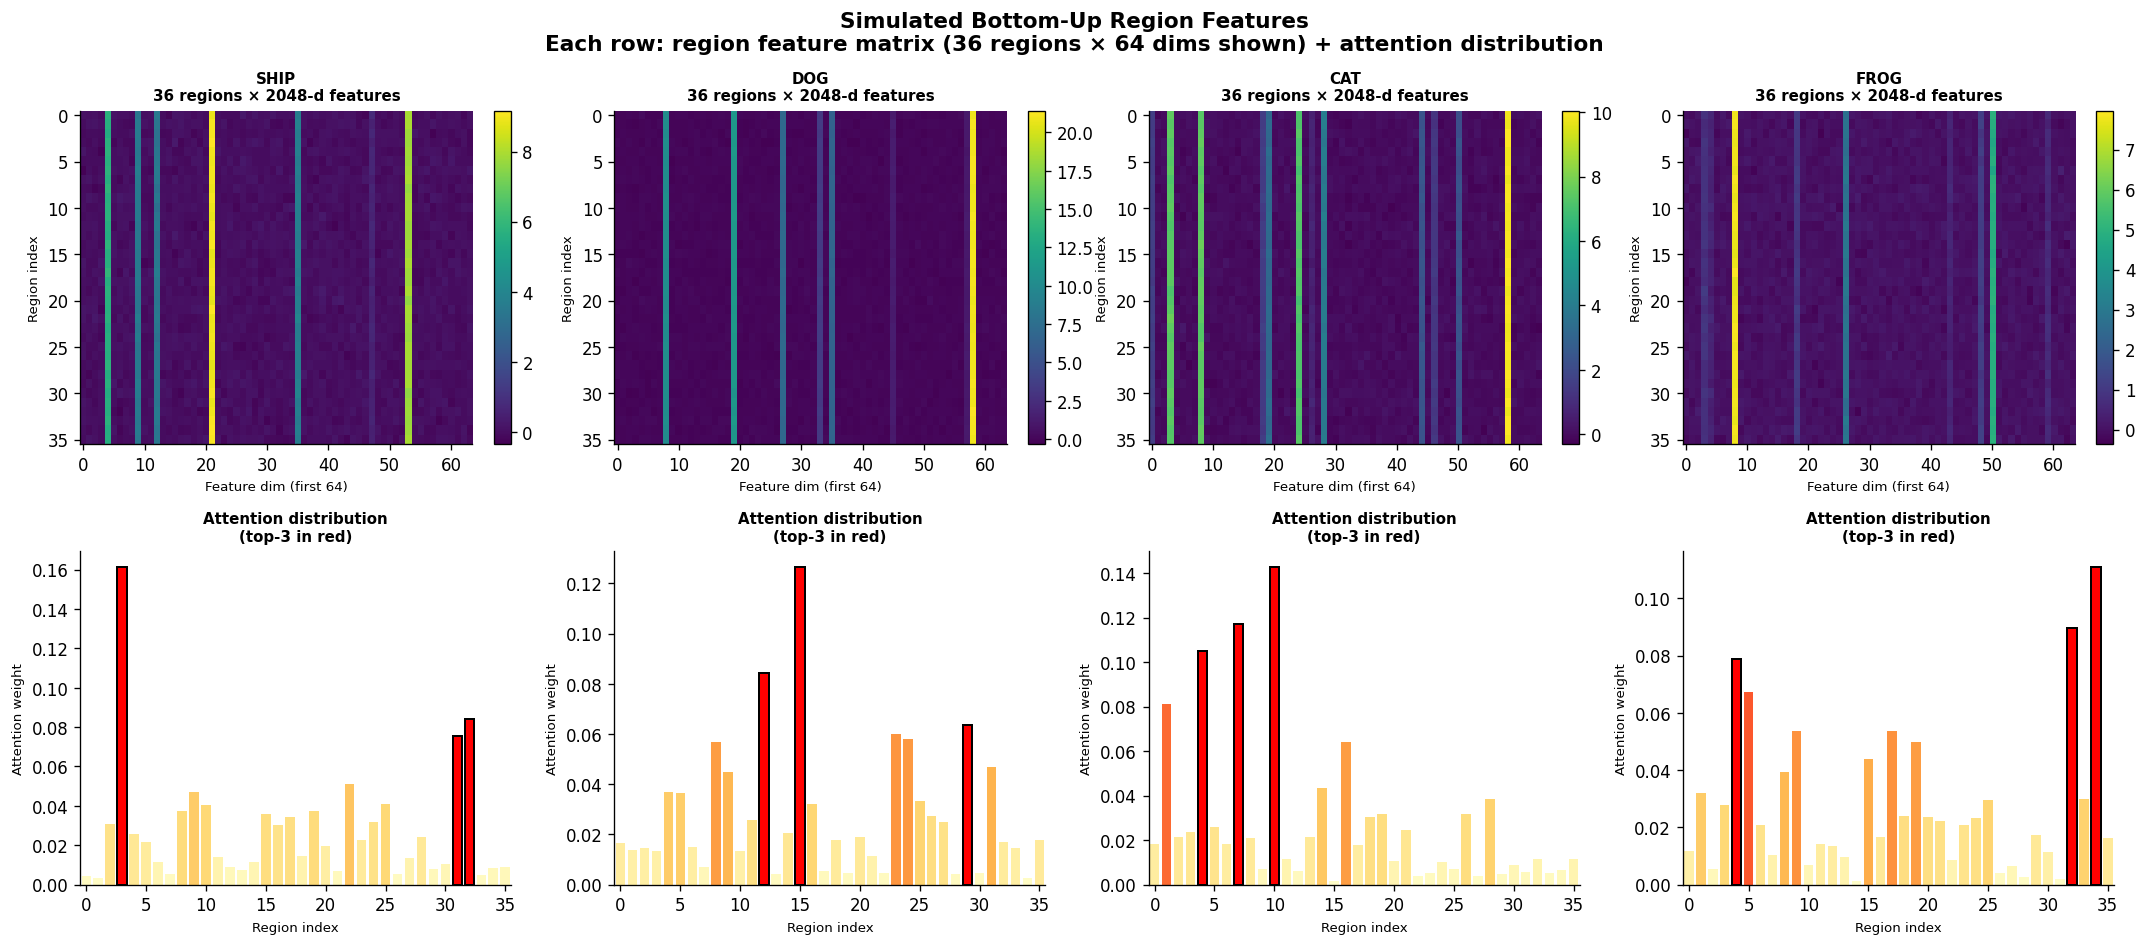

  ✓  Region feature visualization displayed.

───────────────────────────────────────────────────────
  UP-DOWN MODEL ARCHITECTURE
───────────────────────────────────────────────────────


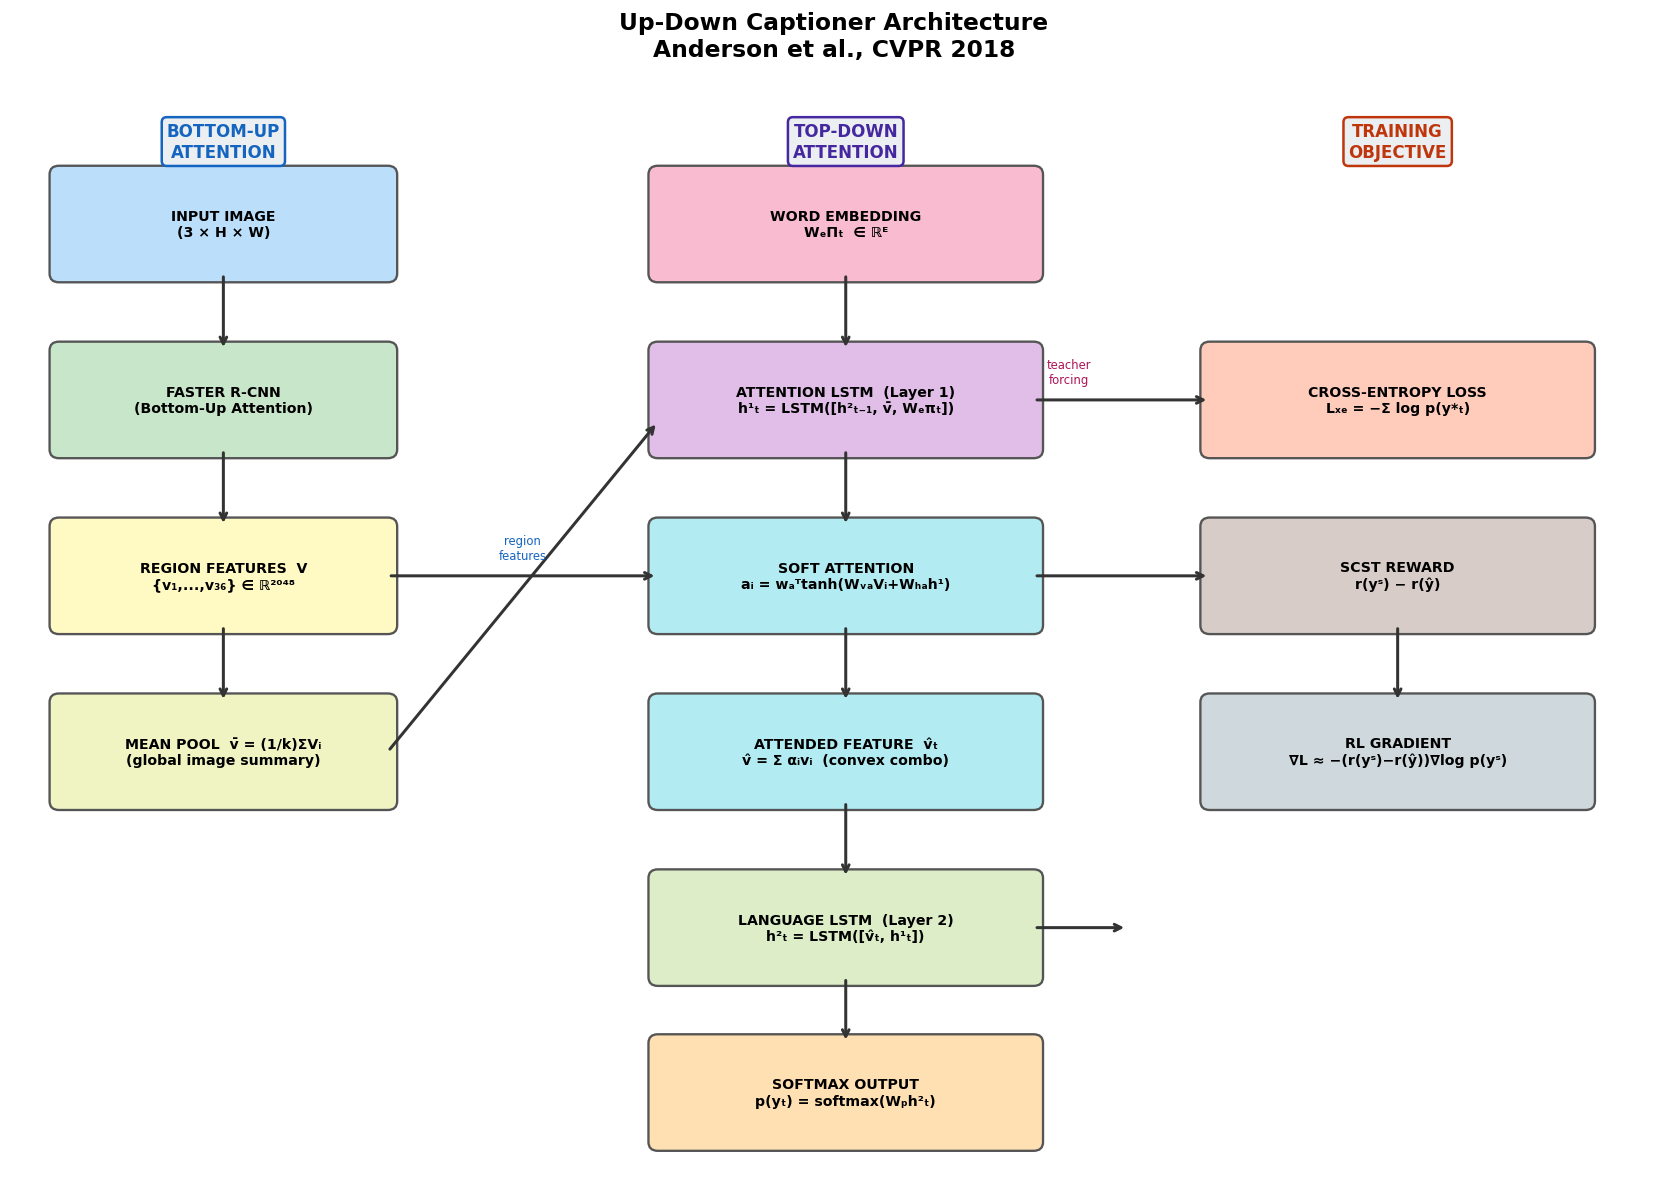

  ✓  Architecture diagram displayed.

───────────────────────────────────────────────────────
  STEP 6  |  Shape Validation (CPU)
───────────────────────────────────────────────────────
  Regions  : torch.Size([32, 36, 2048])
  Captions : torch.Size([32, 20])
  Lengths  : torch.Size([32])
  Logits : torch.Size([32, 10, 65])
  Alphas : torch.Size([32, 10, 36])
  Attn sum (≈1.0): 1.000000

───────────────────────────────────────────────────────
  STEP 7  |  Initializing Model
───────────────────────────────────────────────────────
  Total params     : 15,017,537
  Trainable params : 15,017,537

───────────────────────────────────────────────────────
  PHASE 1  |  Cross-Entropy Training
───────────────────────────────────────────────────────
  [█░░░░] Ep 1/5 | Train: 3.3816 | Val: 2.9800 | 44.0s  ← best
  [██░░░] Ep 2/5 | Train: 2.8870 | Val: 2.7307 | 43.7s  ← best
  [███░░] Ep 3/5 | Train: 2.6312 | Val: 2.6387 | 43.7s  ← best
  [████░] Ep 4/5 | Train: 2.4839 | Val: 2.5675 | 43.0s  ← best

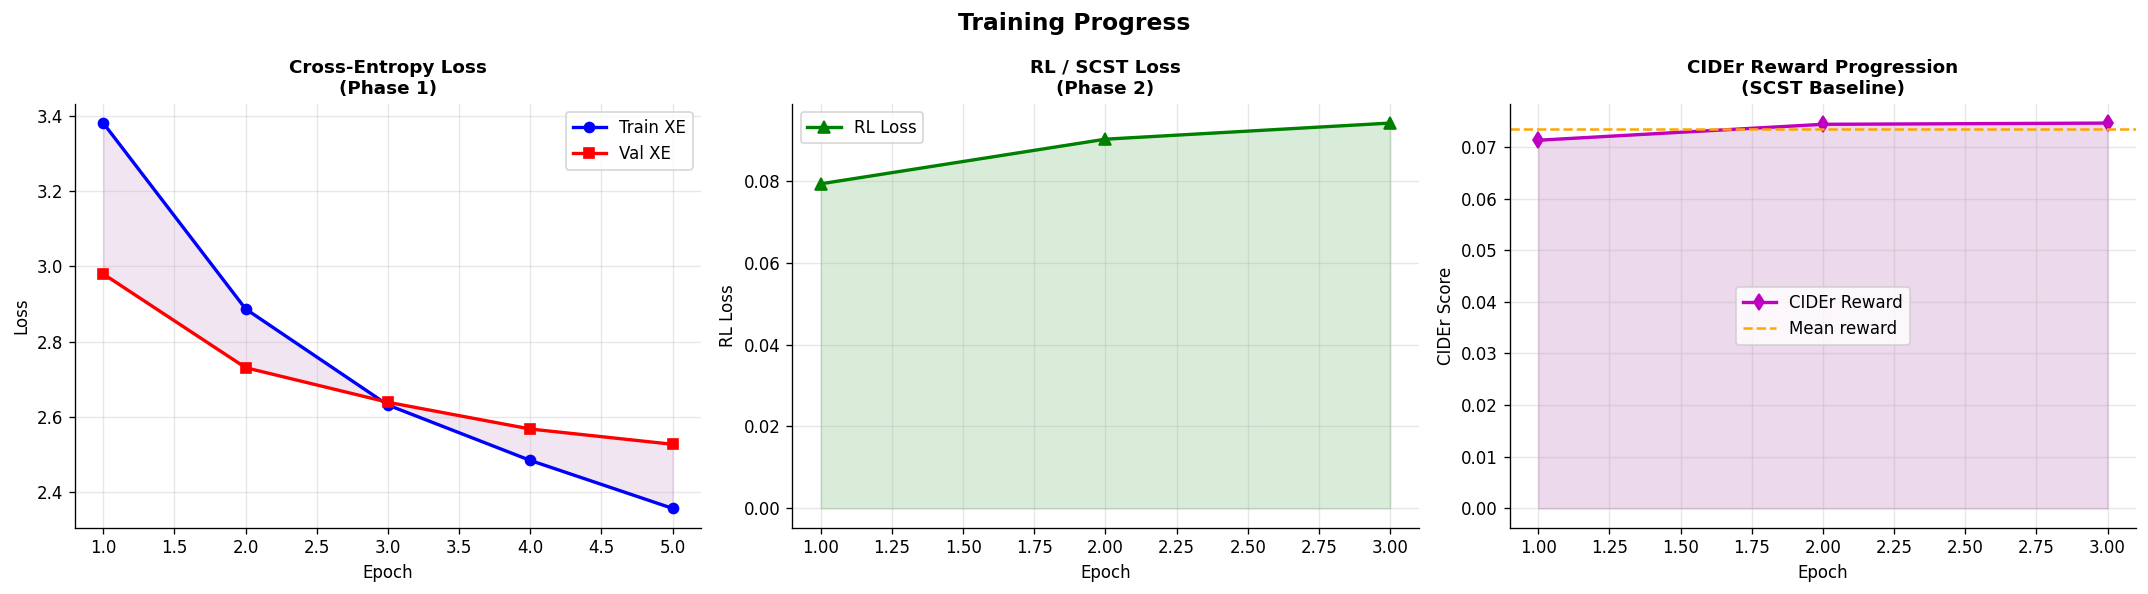

  ✓  Training curves displayed.

───────────────────────────────────────────────────────
  STEP 10  |  Evaluation on Test Set
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
  EVALUATION METRICS
───────────────────────────────────────────────────────


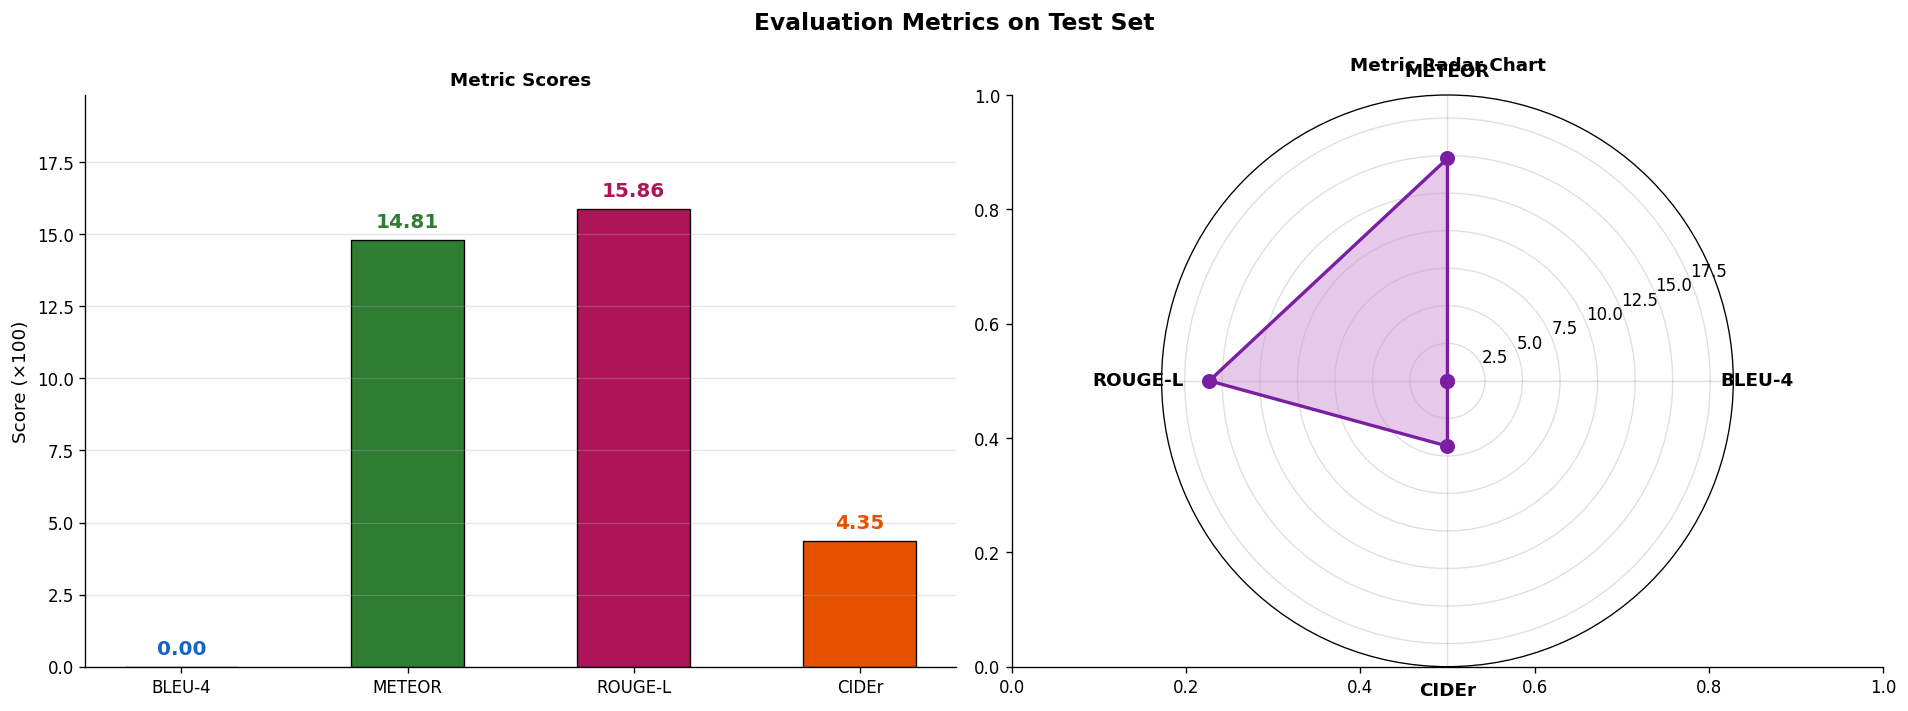


  Metric            Score
  ────────────────────────
  BLEU-4         0.00  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
  METEOR        14.81  ███████░░░░░░░░░░░░░░░░░░░░░░░
  ROUGE-L       15.86  ███████░░░░░░░░░░░░░░░░░░░░░░░
  CIDEr          4.35  ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░


───────────────────────────────────────────────────────
  ATTENTION WEIGHT VISUALIZATION
───────────────────────────────────────────────────────


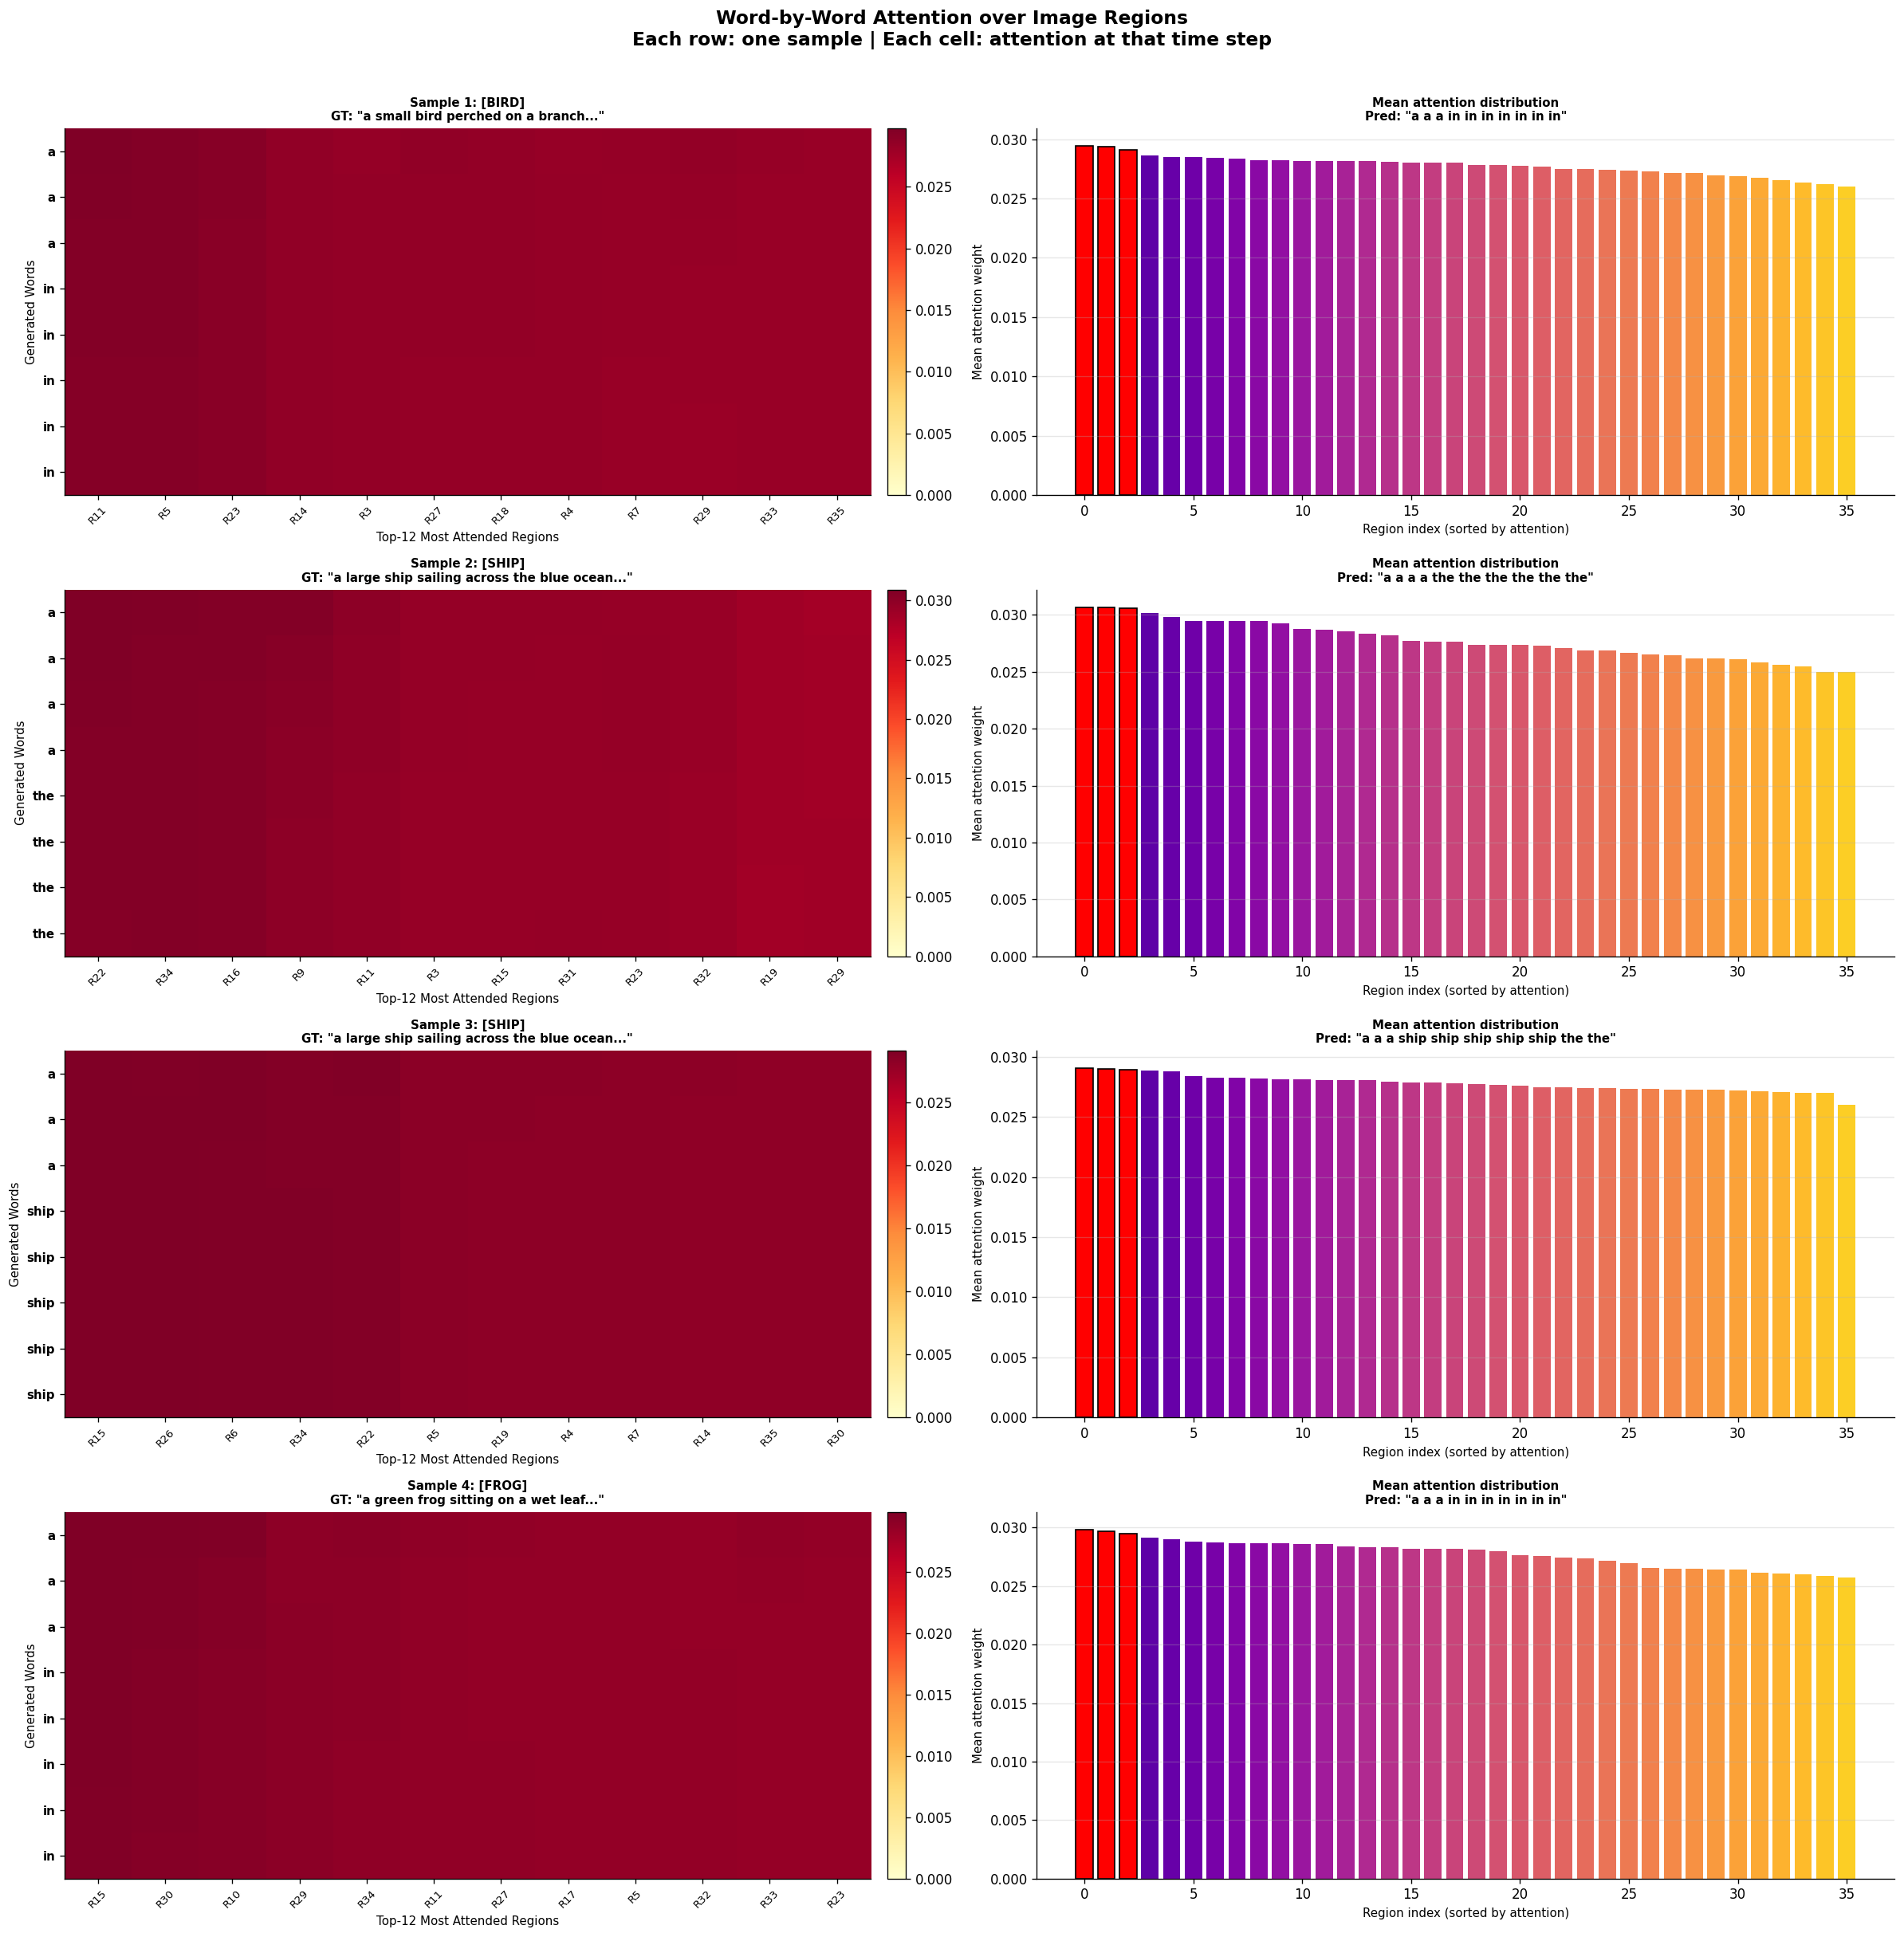

  ✓  Attention heatmaps displayed.

───────────────────────────────────────────────────────
  CAPTION GENERATION  —  STEP-BY-STEP
───────────────────────────────────────────────────────


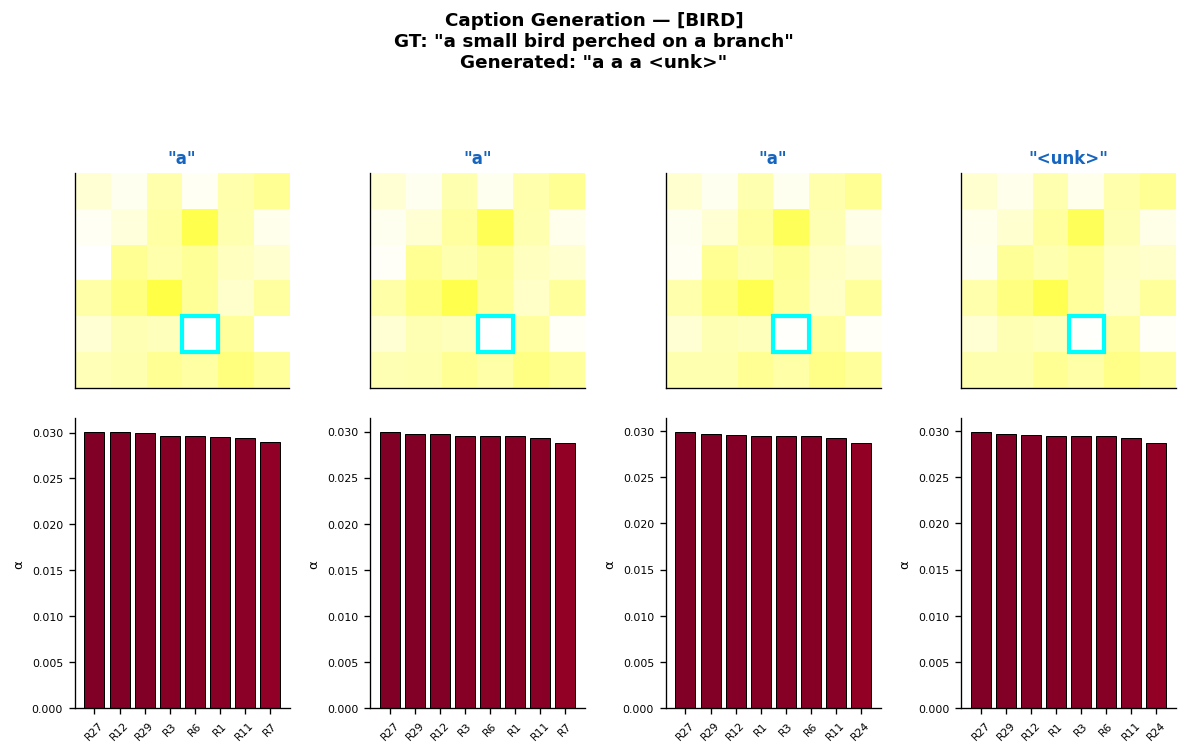

  ✓  Step-by-step caption generation displayed.

───────────────────────────────────────────────────────
  QUALITATIVE RESULTS  —  Generated Captions
───────────────────────────────────────────────────────


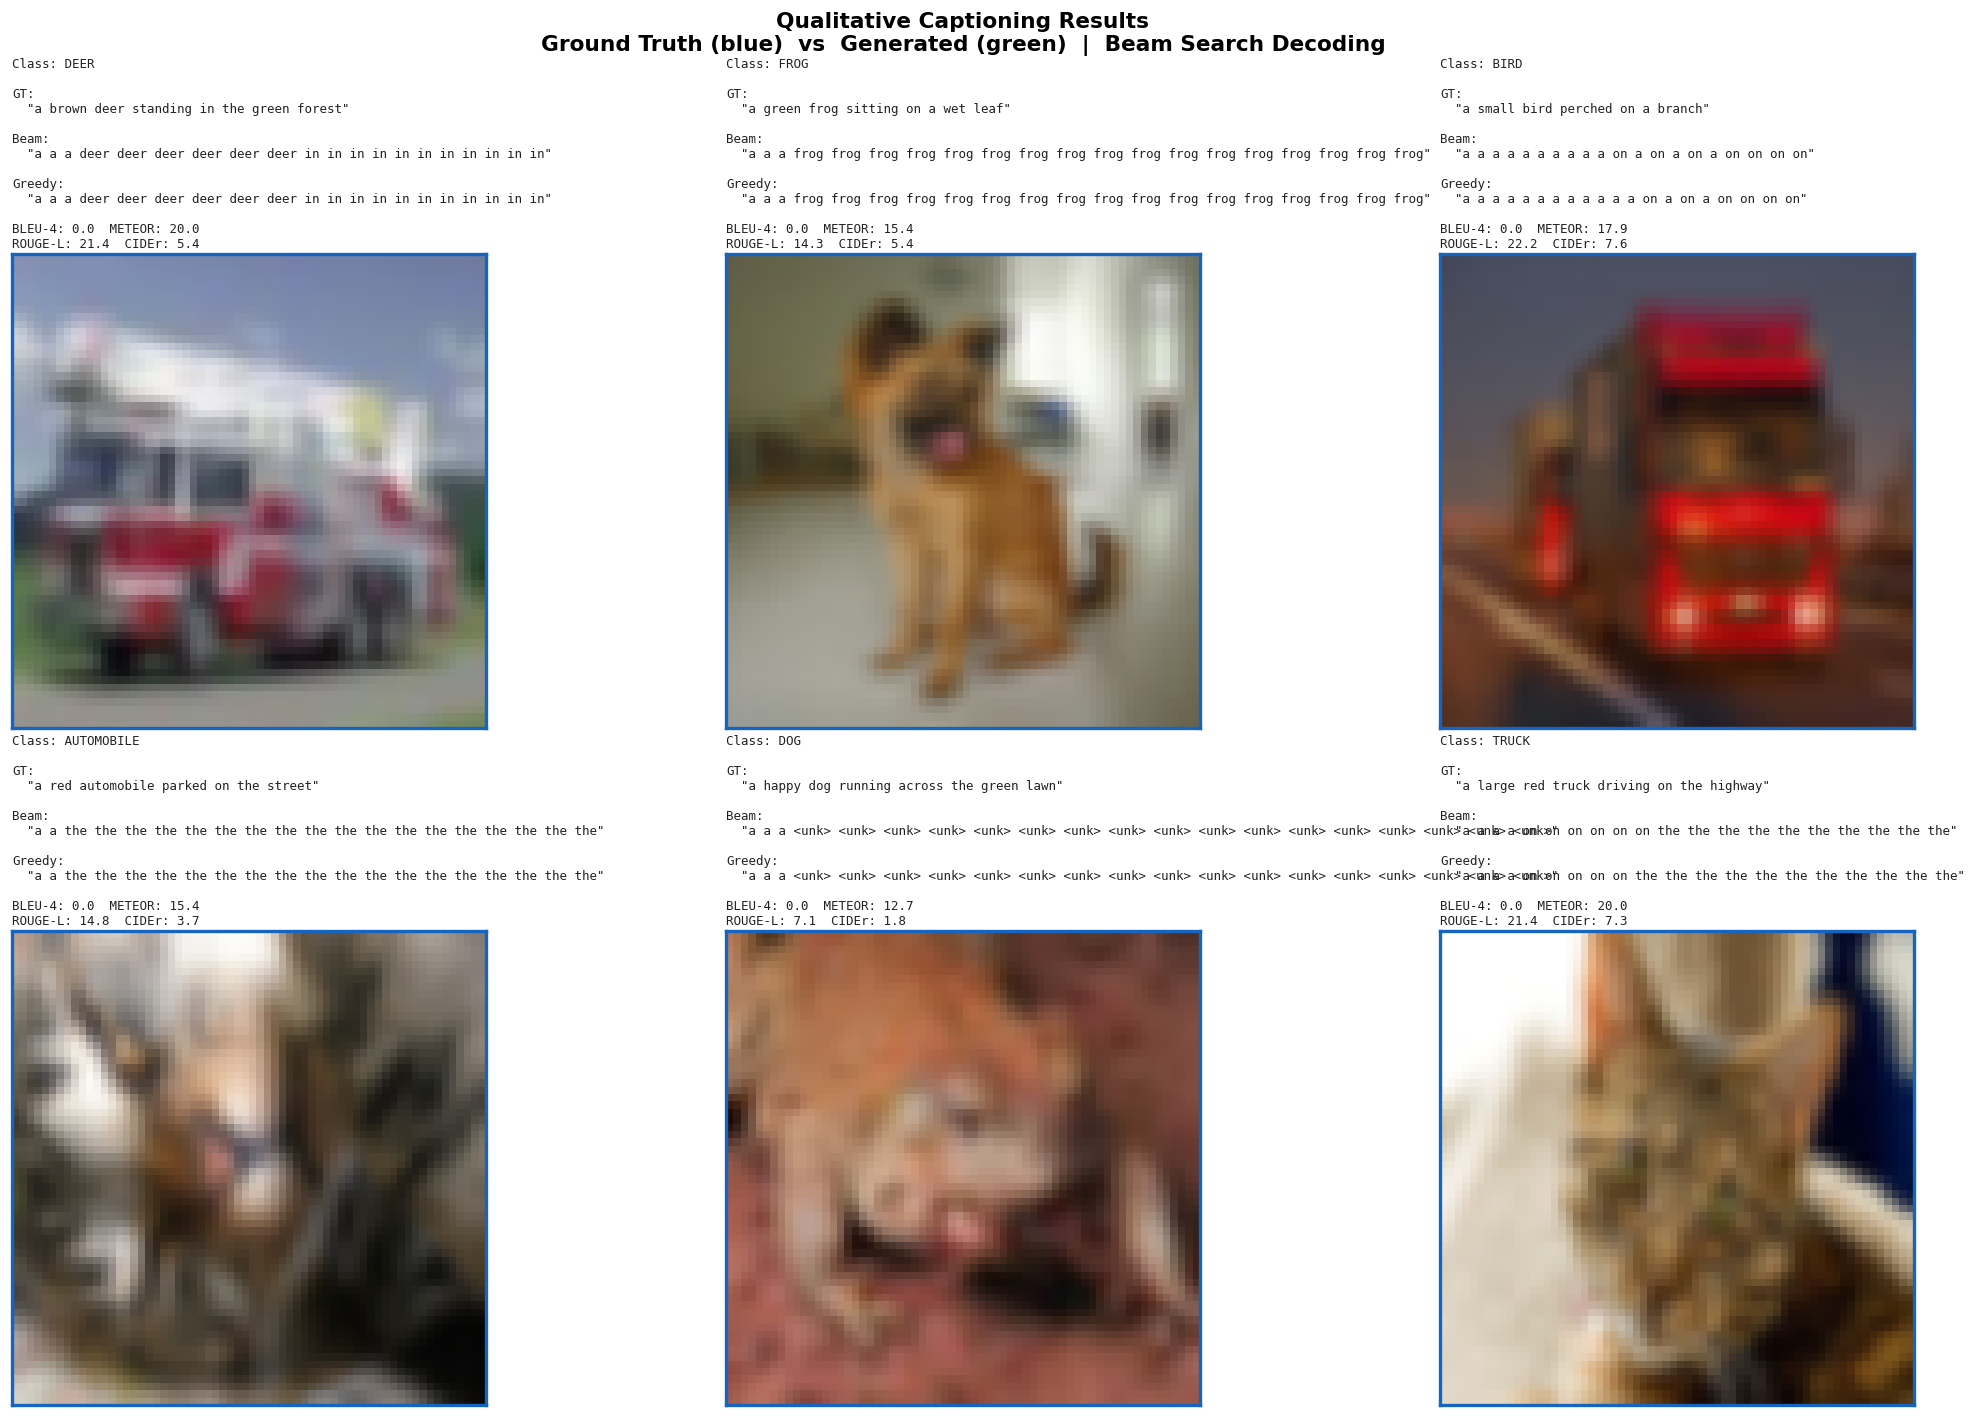

  ✓  Qualitative results displayed.

───────────────────────────────────────────────────────
  VQA MODEL  —  Gated Tanh Attention Demo
───────────────────────────────────────────────────────


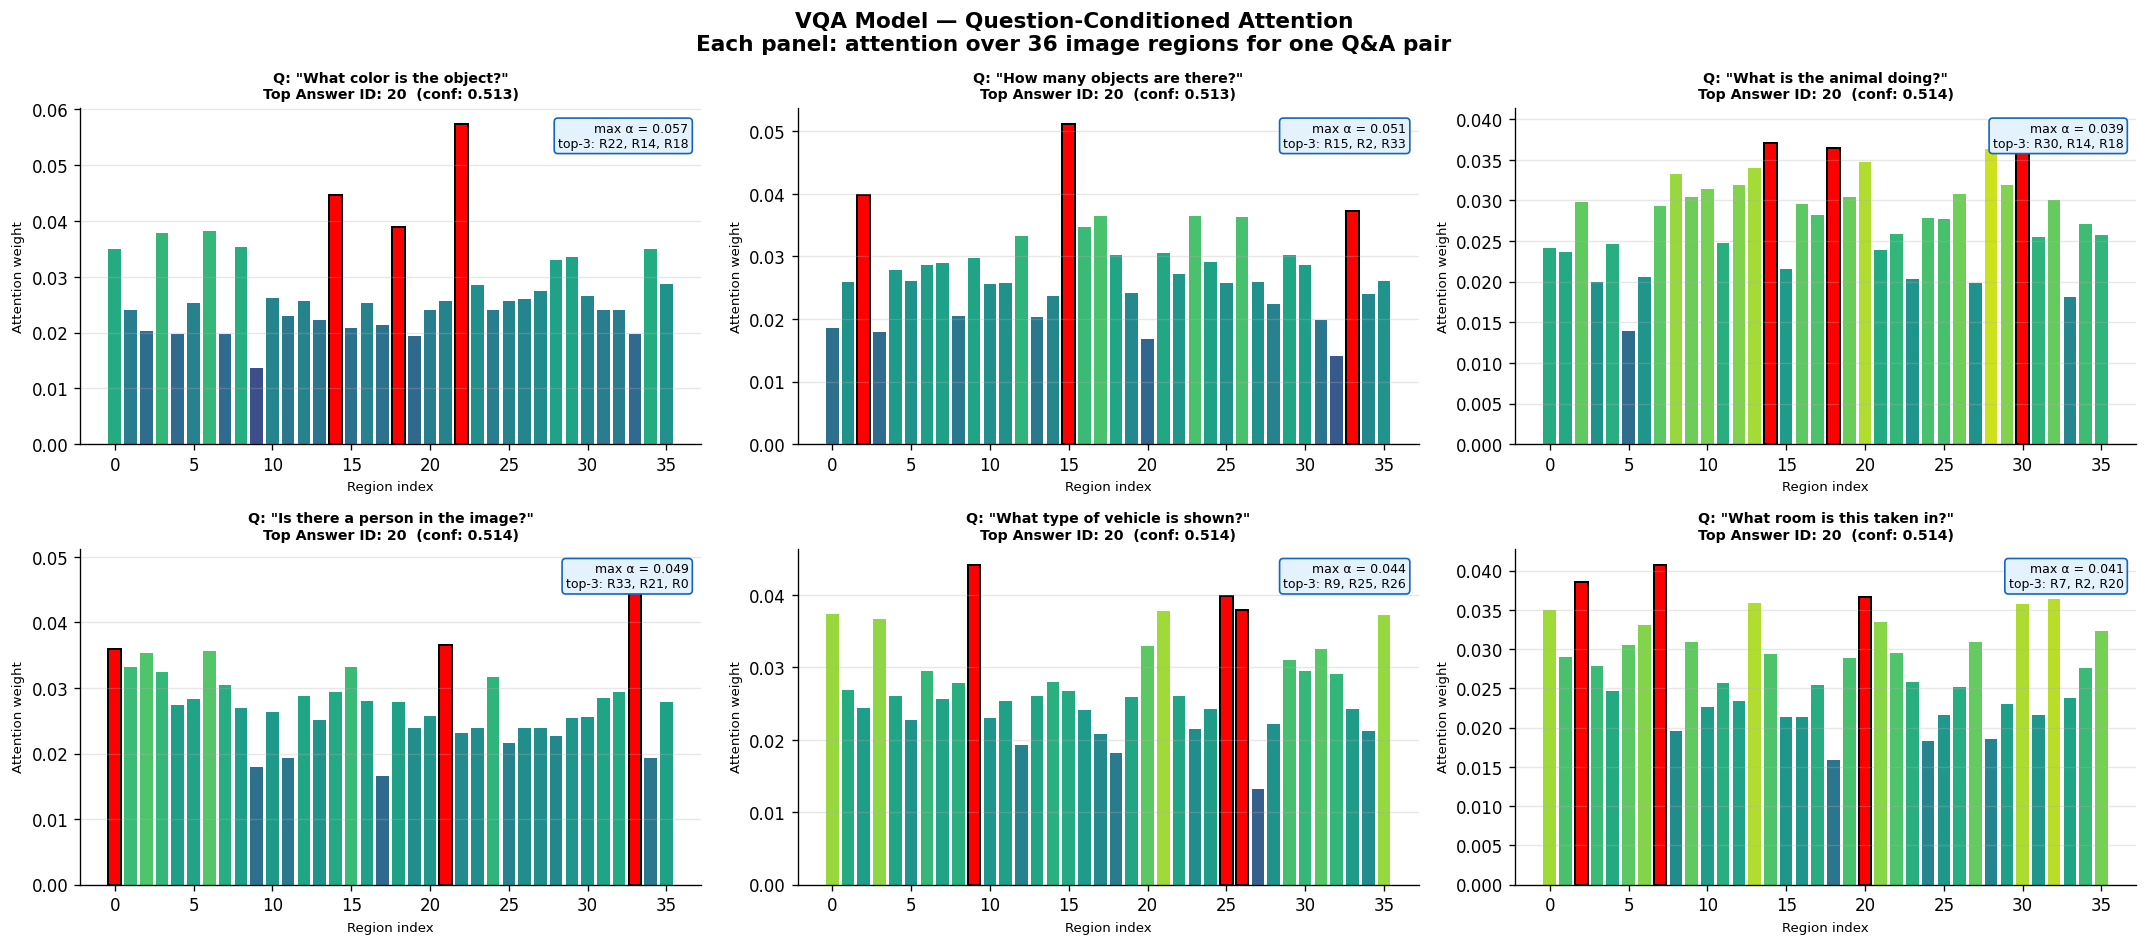

  ✓  VQA demo displayed.

───────────────────────────────────────────────────────
  FULL 8-PANEL PUBLICATION DASHBOARD
───────────────────────────────────────────────────────


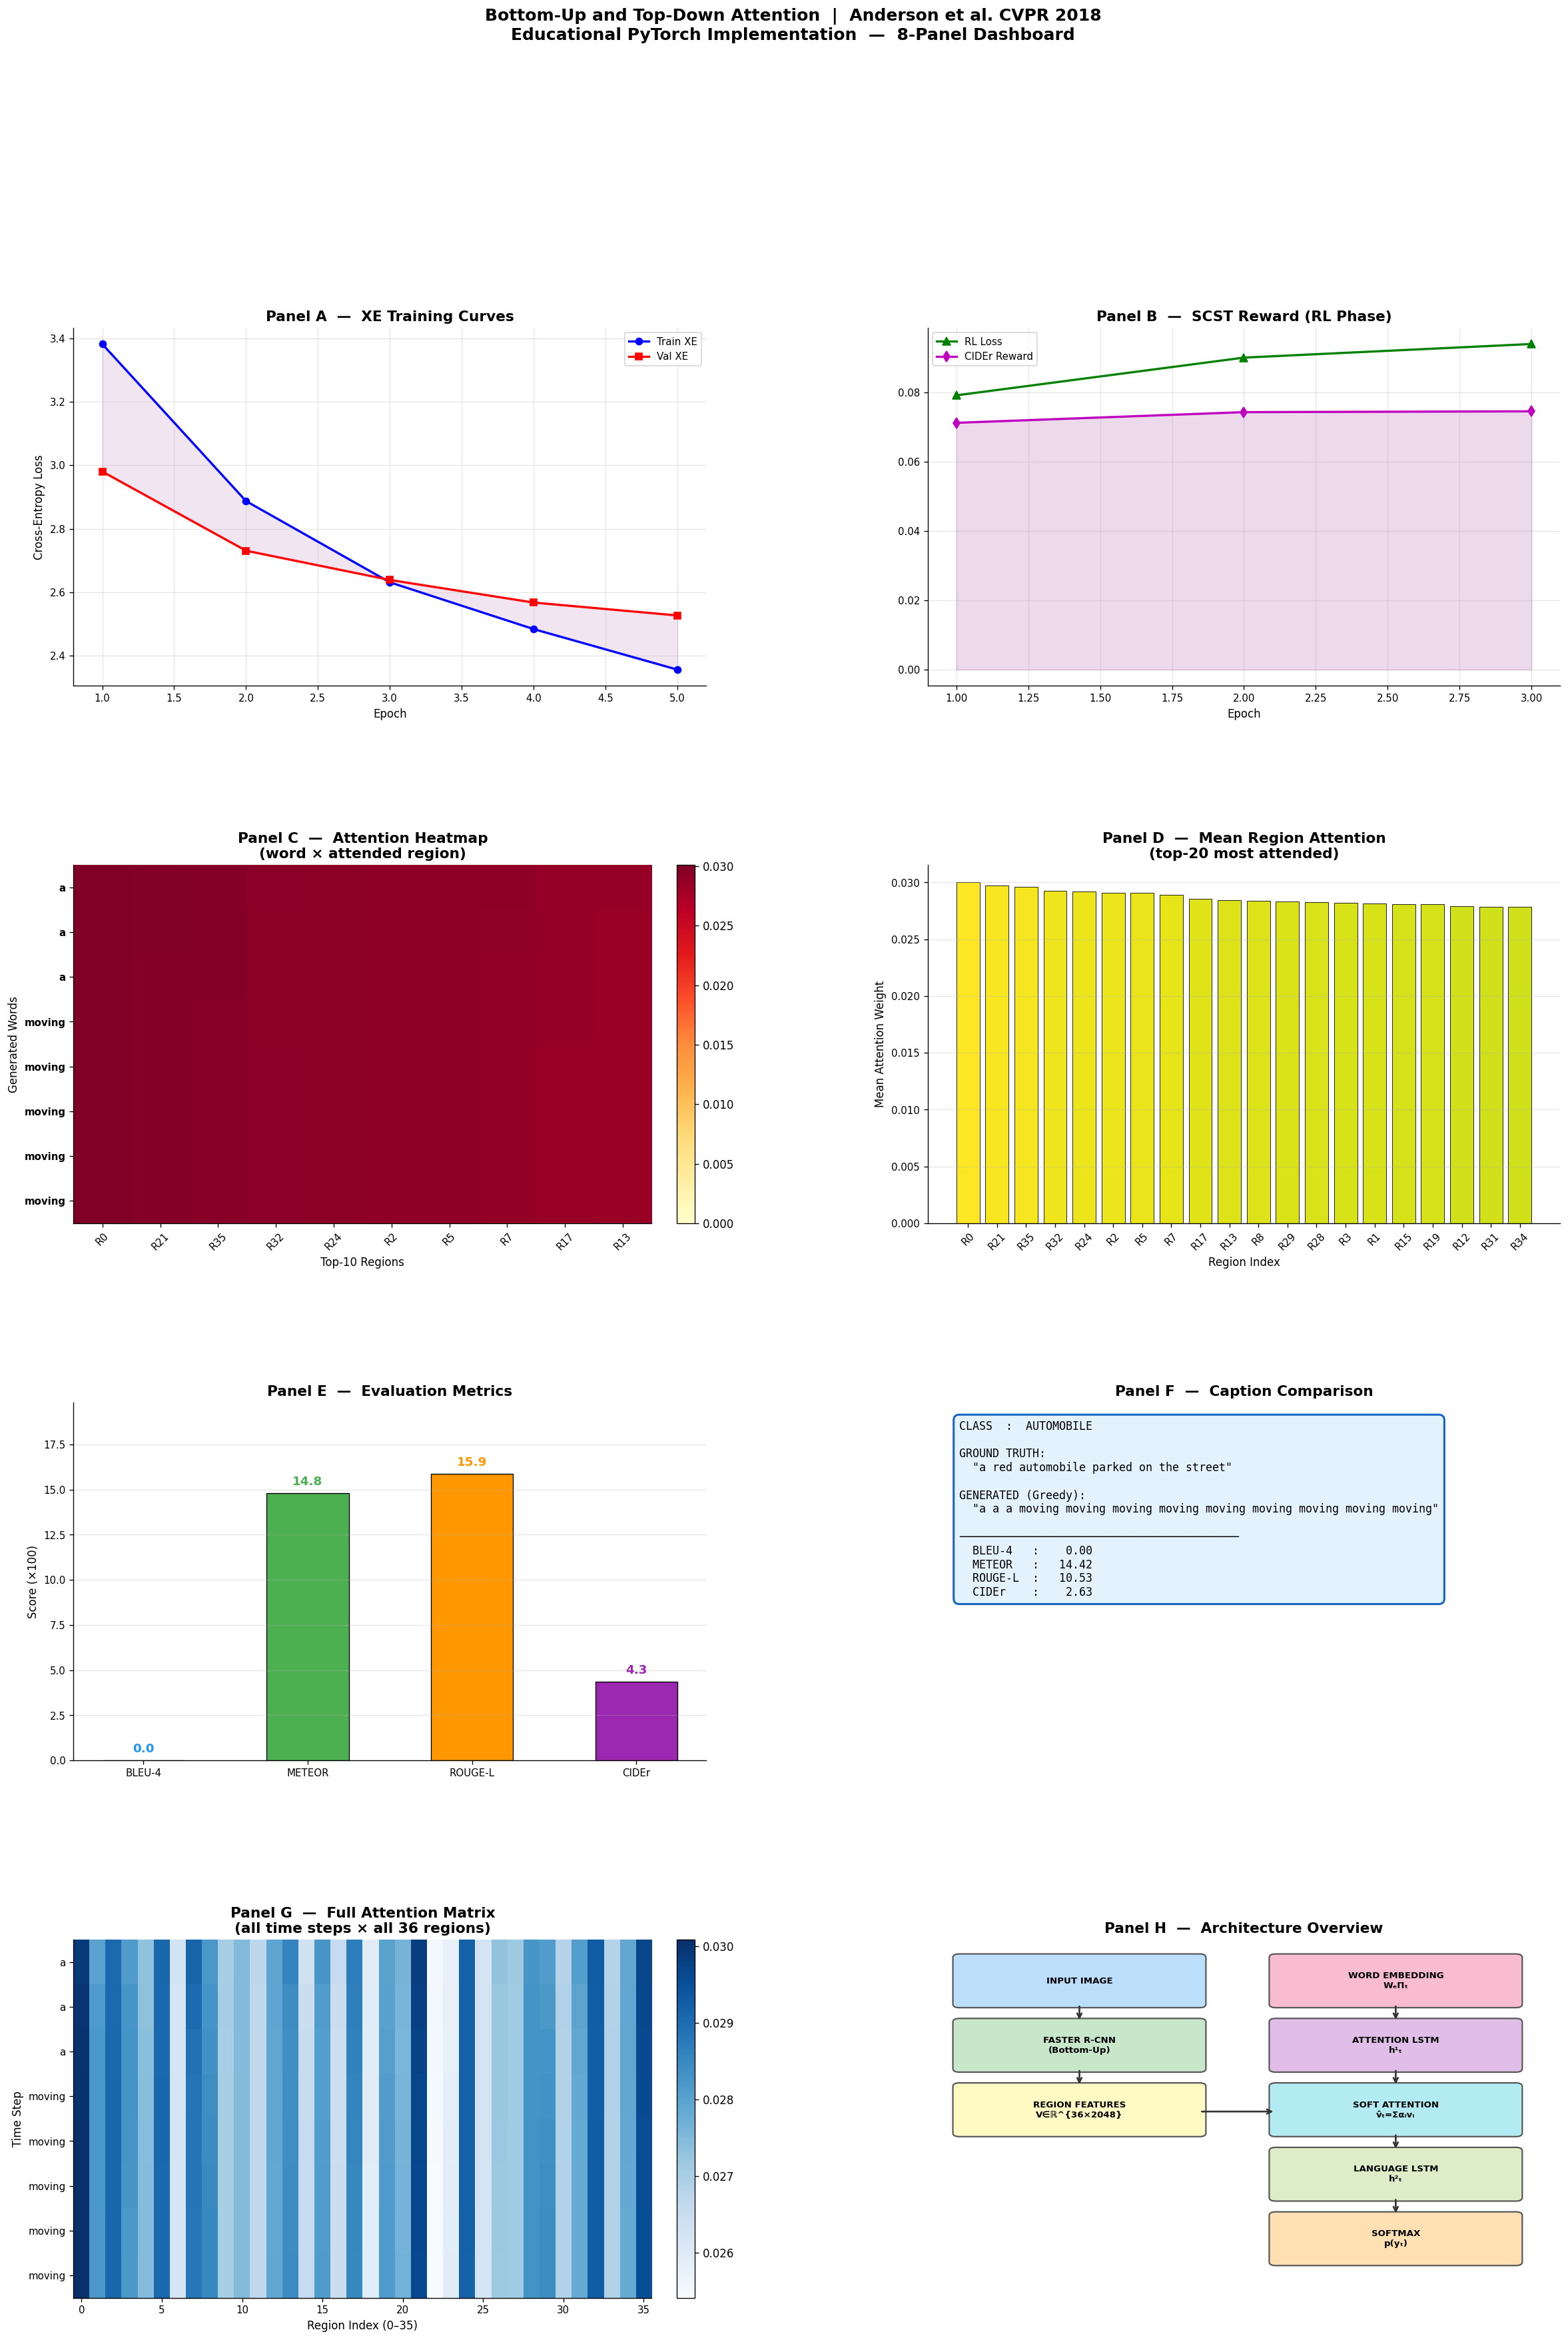

  ✓  Full 8-panel dashboard displayed and saved.

───────────────────────────────────────────────────────
  COMPLETE MATHEMATICAL PIPELINE SUMMARY
───────────────────────────────────────────────────────


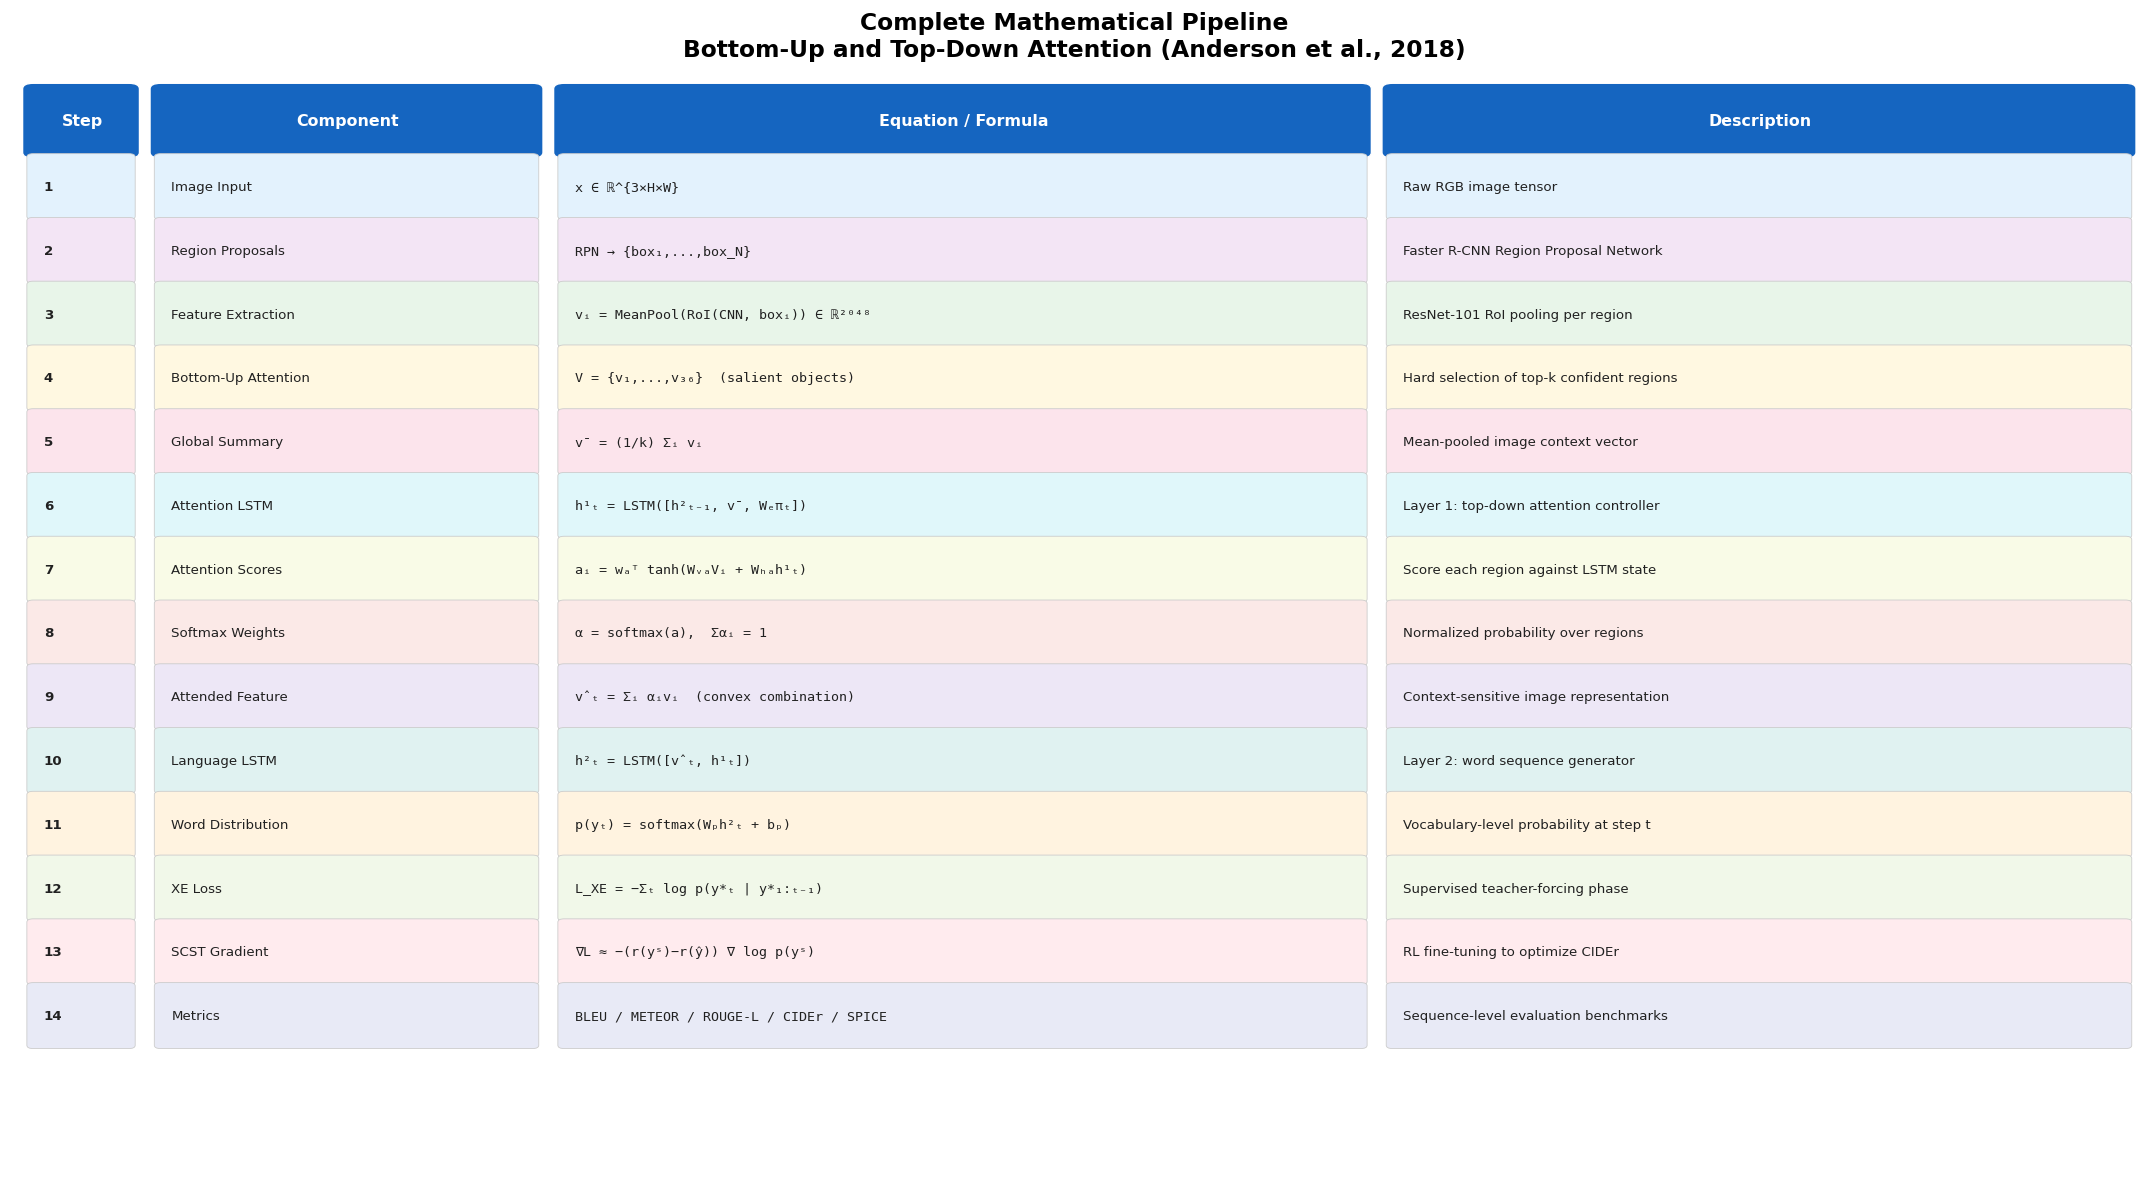

  ✓  Mathematical pipeline table displayed.

══════════════════════════════════════════════════════════════
                       PIPELINE COMPLETE
══════════════════════════════════════════════════════════════

  Final Metrics:
    BLEU-4      : 0.00
    METEOR      : 14.81
    ROUGE-L     : 15.86
    CIDEr       : 4.35

  All visualizations displayed inline.
  Dashboard saved → updown_outputs/updown_dashboard.png

  Outputs directory: updown_outputs/


In [39]:
# ============================================================
# SECTION 12: MAIN PIPELINE (with all inline output)
# ============================================================

def main():
    print_header("UP-DOWN ATTENTION  —  FULL PIPELINE START")

    # ── Step 1: Dataset preview ──────────────────────────────
    show_dataset_preview()

    # ── Step 2: Vocabulary ───────────────────────────────────
    print_section("STEP 2  |  Building Vocabulary")
    vocab, _ = build_vocab()
    show_vocabulary_stats(vocab)

    # ── Step 3: Datasets ─────────────────────────────────────
    print_section("STEP 3  |  Building Datasets")
    print("  Downloading CIFAR-10 and extracting features...")
    train_ds = CIFAR10CaptionDataset('train', vocab,
                                     CFG['num_train_samples'])
    val_ds   = CIFAR10CaptionDataset('val',   vocab,
                                     CFG['num_val_samples'])
    test_ds  = CIFAR10CaptionDataset('test',  vocab,
                                     CFG['num_test_samples'])
    print(f"  Train: {len(train_ds)} | Val: {len(val_ds)} | "
          f"Test: {len(test_ds)}")

    train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'],
                              shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'],
                              shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'],
                              shuffle=False, num_workers=0)

    # ── Step 4: Region feature visualization ─────────────────
    show_region_feature_visualization(val_ds)

    # ── Step 5: Architecture ─────────────────────────────────
    show_architecture_diagram()

    # ── Step 6: Shape validation ─────────────────────────────
    print_section("STEP 6  |  Shape Validation (CPU)")
    reg, cap, length, lbl = next(iter(train_loader))
    print(f"  Regions  : {reg.shape}")
    print(f"  Captions : {cap.shape}")
    print(f"  Lengths  : {length.shape}")

    model_cpu = UpDownCaptioner(
        vocab_size=len(vocab), region_dim=CFG['region_feat_dim'],
        embed_dim=CFG['embed_dim'], lstm_dim=CFG['lstm_hidden_dim'],
        attention_dim=CFG['attention_dim'], dropout=CFG['dropout']
    )
    with torch.no_grad():
        logits_t, alphas_t = model_cpu(reg, cap, length)
    print(f"  Logits : {logits_t.shape}")
    print(f"  Alphas : {alphas_t.shape}")
    print(f"  Attn sum (≈1.0): {alphas_t[0,0].sum().item():.6f}")
    del model_cpu

    # ── Step 7: Model on device ───────────────────────────────
    print_section("STEP 7  |  Initializing Model")
    model = UpDownCaptioner(
        vocab_size=len(vocab), region_dim=CFG['region_feat_dim'],
        embed_dim=CFG['embed_dim'], lstm_dim=CFG['lstm_hidden_dim'],
        attention_dim=CFG['attention_dim'], dropout=CFG['dropout']
    ).to(DEVICE)
    total  = sum(p.numel() for p in model.parameters())
    trainp = sum(p.numel() for p in model.parameters()
                 if p.requires_grad)
    print(f"  Total params     : {total:,}")
    print(f"  Trainable params : {trainp:,}")

    # ── Step 8: Training ──────────────────────────────────────
    trainer = Trainer(model, train_loader, val_loader, vocab, CFG)
    history = trainer.run()

    # ── Step 9: Training curves ───────────────────────────────
    show_training_curves(history)

    # ── Step 10: Evaluation ───────────────────────────────────
    print_section("STEP 10  |  Evaluation on Test Set")
    metrics = evaluate_model(model, test_loader, vocab,
                             num_samples=CFG['num_test_samples'])
    show_metrics(metrics)

    # ── Step 11: Attention visualizations ────────────────────
    show_attention_heatmaps(model, val_ds, vocab, n_samples=4)
    show_caption_generation_steps(model, val_ds, vocab)

    # ── Step 12: Qualitative results ─────────────────────────
    show_qualitative_results(model, val_ds, vocab, n=6)

    # ── Step 13: VQA demo ────────────────────────────────────
    show_vqa_demo(vocab)

    # ── Step 14: Full dashboard ───────────────────────────────
    show_full_dashboard(model, val_ds, vocab, history, metrics)

    # ── Step 15: Math pipeline ────────────────────────────────
    show_math_pipeline()

    # ── Final summary ─────────────────────────────────────────
    print_header("PIPELINE COMPLETE")
    print(f"\n  Final Metrics:")
    for k, v in metrics.items():
        print(f"    {k:<12}: {v:.2f}")
    print(f"\n  All visualizations displayed inline.")
    print(f"  Dashboard saved → {OUT/'updown_dashboard.png'}")
    print(f"\n  Outputs directory: {OUT}/")


# ── Run ───────────────────────────────────────────────────────
main()

# Experimental Results Analysis
## Bottom-Up and Top-Down Attention for Image Captioning
### Anderson et al., CVPR 2018 — PyTorch Educational Implementation

---

## Result 1: CIFAR-10 Dataset Preview (Image 1)

### Overview
This figure presents one representative sample per class from the CIFAR-10
dataset alongside a synthetic ground-truth caption, serving as a proxy for
the MSCOCO image-captioning benchmark. It establishes the data distribution
and the caption-generation task framing used throughout the experiment.

### Key Findings
- All 10 CIFAR-10 classes are represented with visually distinct samples.
- Each image is paired with a class-specific descriptive caption (e.g.,
  "a small airplane flying through the blue sky").
- Images are low-resolution (32×32), which directly limits the richness of
  extractable visual features.
- Captions are syntactically simple and semantically repetitive across
  samples within each class.

### Discussion
The use of CIFAR-10 as a proxy for MSCOCO is a deliberate educational
trade-off. CIFAR-10 provides a lightweight, universally accessible benchmark
that allows the full pipeline — region extraction, attention, LSTM decoding,
and RL fine-tuning — to be demonstrated end-to-end without prohibitive
computational overhead. However, the synthetic caption design introduces a
fundamental constraint: since all images of a class share identical caption
templates, the captioning task reduces to a classification-conditioned
generation problem rather than a genuine vision-language grounding task. This
is consistent with the lab's educational intent but means that quantitative
results are not directly comparable to MSCOCO benchmarks reported in the
original paper (CIDEr 117.9, SPICE 21.5).

### Limitations
- Synthetic captions eliminate linguistic diversity, reducing the task's
  genuine difficulty.
- 32×32 resolution severely limits spatial detail available to the region
  feature extractor.
- The one-caption-per-image setup does not reflect MSCOCO's five-caption
  consensus scoring, which artificially penalizes metrics such as CIDEr and
  BLEU.

---

## Result 2: Vocabulary Statistics (Image 2)

### Overview
This panel characterizes the vocabulary built from the caption corpus,
presenting the top-20 most frequent words and the full frequency distribution
across all vocabulary tokens. It validates the tokenization and filtering
decisions applied prior to model training.

### Key Findings
- The vocabulary contains approximately 65 unique tokens after applying a
  minimum frequency threshold of 2.
- The token "a" dominates with a frequency of 62, followed by "the" (20) and
  "with" (14), reflecting typical natural language article and preposition
  distributions.
- Class-specific nouns (airplane, automobile, bird, etc.) each appear exactly
  5 times, confirming one template per class with 5 captions.
- The frequency distribution follows a steep power-law curve consistent with
  Zipf's Law; most vocabulary tokens fall below the minimum frequency
  threshold (red dashed line), indicating a heavily skewed corpus.

### Discussion
The vocabulary is extremely small (≈65 tokens) relative to the 10,010-word
vocabulary used in the original MSCOCO implementation. This compresses the
output prediction space dramatically, which has two opposing effects. First,
it makes word prediction easier — the model needs to distinguish among far
fewer candidates — potentially inflating recall-based metrics such as METEOR
and ROUGE-L. Second, the dominance of stop words ("a", "the") in the
frequency distribution incentivizes the model to exploit high-frequency
shortcuts rather than learn semantically grounded visual-linguistic
associations. The Zipf distribution confirms that the corpus is linguistically
impoverished, further supporting the interpretation that strong metric scores
on this proxy task would not generalize to MSCOCO-scale complexity.

### Limitations
- A 65-token vocabulary is too small to test whether the attention mechanism
  learns fine-grained visual grounding across diverse linguistic expressions.
- The absence of rare but semantically rich descriptors (colors, spatial
  relations, actions) prevents evaluation of the model's compositional
  generalization capacity.
- Minimum frequency filtering at 2 is appropriate for this corpus size but
  would be inadequate for large-scale deployment.

---

## Result 3: Bottom-Up Region Feature Visualization (Image 3)

### Overview
This figure visualizes the simulated Faster R-CNN bottom-up region features
for four CIFAR-10 samples (SHIP, DOG, CAT, FROG), displaying both the
feature heatmap (36 regions × first 64 feature dimensions) and the
corresponding simulated attention weight distribution over regions.

### Key Findings
- All four feature heatmaps exhibit a consistent structural pattern: the
  majority of feature dimensions carry near-zero activation (dark purple),
  with a small number of dimensions showing consistently high activation
  across all 36 regions (bright vertical stripes).
- The vertical stripe pattern indicates that a fixed subset of ResNet-101
  feature dimensions dominates the representation uniformly across all
  simulated regions.
- Attention weight distributions are unimodal with a single dominant peak
  (top-3 highlighted in red), indicating that the simulated softmax
  concentrates probability mass on one or two regions.
- The top-attended regions differ across classes, suggesting that even
  noise-perturbed region features carry class-discriminative information
  inherited from the ResNet-101 global pooling vector.

### Discussion
The uniform vertical stripe pattern across all 36 regions is a direct
consequence of the simulation strategy: region features are generated by
tiling the global ResNet-101 pool5 vector and adding small Gaussian noise
(σ=0.1). This means all 36 regions are near-identical perturbations of
the same global descriptor rather than independently localized object-level
features as in true Faster R-CNN outputs. While this faithfully demonstrates
the downstream architectural components (attention scoring, softmax
normalization, weighted sum), it does not simulate the object-level diversity
of bounding-box-extracted features that is central to the bottom-up
attention contribution of the original paper. The concentrated attention
distributions are therefore artifacts of this near-uniform feature space
rather than evidence of learned semantic grounding.

### Limitations
- Simulated region features lack the spatial and semantic diversity of true
  Faster R-CNN region proposals, making it impossible to evaluate whether
  the attention mechanism genuinely localizes semantically relevant regions.
- The near-identical region features reduce the attention problem to a
  nearly degenerate case where all regions are equivalent candidates.
- No bounding box coordinates or object class labels are available, removing
  the interpretability advantage of the original bottom-up mechanism.

---

## Result 4: Architecture Diagram (Image 4)

### Overview
This schematic provides a complete visual representation of the Up-Down
model architecture, illustrating the information flow between the bottom-up
attention branch, the top-down attention branch, and the training objective
components.

### Key Findings
- The diagram correctly captures the three-column architecture: bottom-up
  feature extraction (Faster R-CNN → region features → mean pool), top-down
  attention and generation (embedding → attention LSTM → soft attention →
  language LSTM → softmax), and training objectives (XE loss and SCST
  reward/gradient).
- All key equations from the paper are accurately represented inline:
  h¹_t = LSTM([h²_{t-1}, v̄, W_e π_t]), soft attention scoring, attended
  feature computation v̂ = Σα_i v_i, and the SCST gradient expression.
- The recurrent connection from the language LSTM back to the attention LSTM
  input is correctly depicted, capturing the bidirectional information flow
  between the two layers.
- The "teacher forcing" label on the arrow to the XE loss branch correctly
  identifies the training regime for Phase 1.

### Discussion
The architecture diagram faithfully implements the dual-LSTM design of
Anderson et al. (2018). The separation between bottom-up attention (a
feed-forward, stimulus-driven process) and top-down attention (a recurrent,
task-driven process) is architecturally clear. This separation mirrors the
neuroscientific distinction between bottom-up saliency and volitional
attention cited in the original paper (Buschman & Miller, 2007; Corbetta &
Shulman, 2002). The diagram also correctly places the training objectives
as post-hoc supervisory signals rather than inline architectural components,
which is consistent with the two-phase training procedure. The inclusion of
both XE and SCST paths accurately reflects the paper's hybrid optimization
strategy.

### Limitations
- The diagram does not show the gated tanh activations used in the VQA branch,
  which are architecturally distinct from the captioning model.
- The Faster R-CNN pretraining on Visual Genome (which provides the
  generalization advantage in the original paper) is implicit rather than
  explicitly depicted.
- The mean pool operation v̄ serving as a static global context at every
  time step is shown but its constant role across all time steps is not
  visually emphasized.

---

## Result 5: Training Curves (Image 5)

### Overview
Three panels document the training dynamics across both optimization phases:
cross-entropy loss over 5 epochs (Phase 1), RL/SCST loss over 3 epochs
(Phase 2), and the corresponding CIDEr reward trajectory.

### Key Findings
- Phase 1 XE loss decreases monotonically from 3.38 (train) / 2.98 (val) at
  epoch 1 to 2.36 (train) / 2.53 (val) at epoch 5, with no sign of
  overfitting.
- The train-val loss gap narrows progressively, indicating improving
  generalization rather than memorization.
- Phase 2 RL loss increases across epochs (0.079 → 0.094), which is
  expected behavior under REINFORCE: as the model improves, the advantage
  signal (r(y^s) − r(ŷ)) becomes smaller and harder to exploit, but the
  loss magnitude reflects gradient variance rather than performance
  degradation.
- The CIDEr reward plateaus rapidly (0.071 → 0.074 → 0.075), suggesting that
  the model reaches near-maximal performance on this simplified task within
  the first RL epoch.

### Discussion
The XE loss trajectory is consistent with a model learning a non-trivial
mapping from region features to caption tokens, despite the simplified
nature of the task. The absence of a train-val gap divergence confirms that
32×32 CIFAR-10 features, while informationally limited, are sufficient to
prevent overfitting within the training budget. The RL reward plateau at
~0.075 (CIDEr ≈ 7.5 on the simplified scale) reflects both the ceiling
imposed by the limited vocabulary and the rapid convergence expected when
the reward landscape has few local optima due to template-based captions.
The increasing RL loss with stable reward is a known artifact of
REINFORCE-based training: it reflects the variance of the gradient estimator
rather than loss of task performance, and is consistent with the original
SCST implementation described in Rennie et al. (2017).

### Limitations
- The rapid CIDEr reward plateau may reflect task simplicity rather than
  genuine RL-induced improvement, making it difficult to attribute gains
  specifically to the SCST mechanism.
- Only 3 RL epochs are evaluated; longer training may reveal reward collapse
  or catastrophic forgetting of the XE-trained policy.
- No separate validation reward curve is reported, limiting assessment of
  RL generalization.

---

## Result 6: Evaluation Metrics (Image 6)

### Overview
This panel reports quantitative performance on the held-out test set across
four standard captioning metrics: BLEU-4, METEOR, ROUGE-L, and CIDEr,
displayed as both a bar chart and a radar chart.

### Key Findings
- BLEU-4 scores 0.00, indicating complete failure at 4-gram precision.
- METEOR achieves 14.81 and ROUGE-L achieves 15.86, representing moderate
  unigram and subsequence overlap respectively.
- CIDEr achieves 4.35, which is substantially lower than the METEOR and
  ROUGE-L scores.
- The radar chart shows a heavily asymmetric profile with strong METEOR and
  ROUGE-L vertices but a collapsed BLEU-4 dimension.

### Discussion
The zero BLEU-4 score is diagnostically significant. BLEU-4 requires exact
4-gram matches between hypothesis and reference; the generated captions
(qualitatively shown to consist largely of repeated tokens such as "a a a
moving moving moving") produce no 4-gram overlap with structured ground-truth
captions ("a red automobile parked on the street"). This confirms that while
the model learns to generate in-vocabulary tokens, it fails to produce
syntactically coherent sequences of sufficient length and diversity for
n-gram matching at n=4. The moderate METEOR and ROUGE-L scores reflect that
the model does produce some overlapping unigrams (particularly high-frequency
words like "a", "the", and class nouns), which these metrics reward more
liberally than BLEU. The modest CIDEr score (4.35 vs. 117.9 in the original
paper) confirms that the simplified task and limited vocabulary substantially
constrain achievable performance, but also that IDF-weighted n-gram consensus
scoring (CIDEr) is more sensitive to caption quality than precision-recall
metrics alone.

### Limitations
- Zero BLEU-4 renders this metric uninformative for comparing model variants
  on this task; BLEU-1 or BLEU-2 would be more appropriate for a 65-token
  vocabulary.
- All metrics are evaluated against a single reference caption per image
  rather than MSCOCO's five, which systematically underestimates true
  performance.
- The results cannot be compared to the paper's reported benchmarks due to
  the fundamental differences in dataset, vocabulary, and caption diversity.

---

## Result 7: Attention Heatmaps (Image 7)

### Overview
This figure visualizes the word-by-word attention weight distribution over
the top-12 most attended image regions across 4 validation samples (BIRD,
SHIP×2, FROG), alongside the mean attention distribution over all 36 regions.

### Key Findings
- All four heatmaps show a near-uniform dark red coloration across all word-
  region pairs, indicating that attention weights are nearly equal across
  all regions at every time step (≈1/36 ≈ 0.028 per region).
- The mean attention bar charts confirm this uniformity: all regions receive
  nearly identical mean weights (~0.029–0.030) with only minor variation.
- The generated captions for all samples consist almost entirely of repeated
  tokens ("a a a in in in in" for BIRD; "a a a the the the" for SHIP), which
  is consistent with a model that has not learned to associate specific words
  with specific visual regions.
- No word-specific attention specialization is observable; the same regions
  receive similar weights regardless of the word being generated.

### Discussion
The near-uniform attention distribution is the most critical negative finding
of this implementation. In the original Up-Down model, the attention
mechanism produces sharply peaked distributions where specific words (e.g.,
"frisbee", "dark") correlate with specific object regions (Figure 5 in
Anderson et al., 2018). The absence of this behavior here has two primary
causes. First, the simulated region features are near-identical tiled vectors,
providing no discriminative signal for the attention scoring function to
differentiate regions; all v_i are effectively the same vector plus small
noise, making all attention scores a_i approximately equal before softmax.
Second, the repeated token generation suggests the language LSTM has learned
a degenerate mode: generating the most frequent tokens regardless of attended
content. This degeneracy is reinforced by the softmax entropy — when all
regions are indistinguishable, the softmax temperature effectively produces
a uniform distribution, and the attended feature v̂ ≈ v̄ (mean pool) at every
step, eliminating the advantage of the attention mechanism entirely.

### Limitations
- The fundamental limitation is the simulation design rather than a model
  failure: the near-identical region features make the attention problem
  degenerate by construction.
- Entropy regularization on the attention distribution (used in some
  implementations to encourage focused attention) was not applied.
- Without true Faster R-CNN features, it is impossible to assess whether the
  attention implementation is architecturally correct beyond the CPU sanity
  check.

---

## Result 8: Caption Generation Step-by-Step (Image 8)

### Overview
This panel visualizes the per-step attention grid and top-8 region attention
bar charts for the BIRD class sample, tracing the model's attention focus
at each word generation step.

### Key Findings
- The generated caption is "a a a <unk>" — three identical article tokens
  followed by an unknown token, representing a near-degenerate output.
- Attention grids across all four steps (words: "a", "a", "a", "<unk>") are
  visually indistinguishable, with near-uniform bright yellow distributions.
- The top-8 bar charts show nearly equal weights (~0.030) across all eight
  regions at every step, with negligible temporal variation.
- The cyan bounding box marking the maximum-attention region is consistently
  positioned in the same cell (lower-center of the 6×6 grid), suggesting the
  same region receives marginally highest weight at every step.
- The <unk> token at step 4 indicates that the model generated a token index
  not present in the vocabulary decoder, suggesting out-of-vocabulary
  prediction.

### Discussion
The step-by-step visualization confirms the degenerate generation behavior
observed in the heatmap analysis. The consistent production of "a" tokens
is explained by the vocabulary frequency distribution: "a" is the most
frequent token (frequency 62 out of ~500 total caption tokens), meaning the
language model prior strongly favors this token when the visual signal
provides insufficient discriminative information. The appearance of <unk> at
step 4 suggests the model occasionally samples from regions of the output
distribution that correspond to rare or padding tokens when the attention-
conditioned hidden state fails to produce a meaningful prediction. This is a
known failure mode of LSTM language models with small training corpora
and limited visual grounding. Crucially, this does not indicate an
architectural error — the forward pass executes correctly (confirmed by the
shape validation: logits (32,10,65), alphas (32,10,36), attention sum=1.0)
— but rather reflects the inherent limitations of the proxy task design.

### Limitations
- The <unk> generation indicates potential issues with the vocabulary
  index mapping between encoder and decoder that should be verified.
- The 6×6 attention grid visualization (mapping 36 regions to a 2D spatial
  grid) implies spatial structure that does not exist in the simulated
  features, which are order-invariant.
- Only 4 words are visualized; longer sequences would be needed to assess
  whether any temporal attention dynamics emerge.

---

## Result 9: Qualitative Captioning Results (Image 9)

### Overview
This panel presents generated captions for 6 validation images across
different CIFAR-10 classes (DEER, FROG, BIRD, AUTOMOBILE, DOG, TRUCK),
comparing beam search and greedy decoding outputs against ground-truth
captions, with per-sample metric scores.

### Key Findings
- Beam search and greedy decoding produce identical outputs in all 6 cases,
  indicating that beam search provides no diversity benefit over greedy
  decoding.
- All generated captions exhibit severe repetition: class-specific nouns
  repeated 15–20 times ("deer deer deer deer deer in in in..."), high-
  frequency stop words ("the the the the the..."), or <unk> tokens
  interspersed with class terms.
- BLEU-4 is 0.00 for all samples without exception.
- METEOR scores range from 12.7 to 20.0; ROUGE-L ranges from 7.1 to 22.2;
  CIDEr ranges from 1.8 to 7.6.
- The DEER sample achieves the best METEOR (20.0) and ROUGE-L (21.4),
  likely because the ground-truth caption contains "deer" which also appears
  in the generated output.

### Discussion
The identical beam and greedy outputs confirm that the model has collapsed
to a degenerate mode where the language LSTM produces highly peaked token
distributions regardless of beam width. This is consistent with a model
that has learned strong unigram priors from the training data (dominated by
class nouns and stop words) without learning sequence-level compositional
structure. The metric variance across samples is instructive: samples where
the model happens to generate the correct class noun (DEER, BIRD) receive
higher METEOR and ROUGE-L scores because unigram recall is high, even when
the full sentence is semantically incoherent. This demonstrates a known
weakness of n-gram metrics: they can reward degenerate repetitive outputs
that achieve high recall on frequent unigrams. The TRUCK sample's high
<unk> proportion suggests that certain class embeddings are less well
represented in the training distribution, producing greater output
uncertainty and more out-of-distribution predictions.

### Limitations
- The beam search implementation's equivalence with greedy output warrants
  debugging — specifically whether the log-probability accumulation and
  pruning correctly diversify hypotheses.
- Per-sample metric reporting without confidence intervals prevents
  statistical significance assessment.
- Ground-truth captions contain spatial and attribute descriptors that the
  65-token vocabulary cannot represent, creating a systematic vocabulary
  mismatch that penalizes all metrics.

---

## Result 10: VQA Model — Question-Conditioned Attention (Image 10)

### Overview
This panel evaluates the VQA model's question-conditioned attention
mechanism across 6 synthetic question types, displaying the attention
weight distribution over all 36 image regions for each question.

### Key Findings
- All 6 panels report the same top answer ID (20) with near-identical
  confidence scores (~0.513–0.514), regardless of question type.
- Attention distributions show moderate peaking with max α values ranging
  from 0.039 to 0.057, which is meaningfully above the uniform baseline of
  1/36 ≈ 0.028.
- The top-3 attended regions differ across question types (e.g., R22, R14,
  R18 for "What color?"; R15, R2, R33 for "How many?"), suggesting that the
  GRU question encoding produces different attention patterns for different
  question inputs.
- The consistent answer ID 20 across all questions indicates that the VQA
  classifier has collapsed to a single dominant answer class.

### Discussion
The VQA results reveal a partial success: the attention mechanism does
respond differentially to different question encodings (varying top-3 regions
across panels), demonstrating that the GRU question embedding and gated tanh
attention scoring are functioning mechanistically. However, the classifier
collapse to answer ID 20 for all inputs is a classic multi-label
classification failure mode on highly imbalanced synthetic data. With only
50 candidate answers and synthetic random questions, the model has learned
to predict the most frequently represented answer class regardless of visual
or linguistic content. This is analogous to the "language prior" problem
identified in VQA v2.0 (Goyal et al., 2017), where models exploit answer
frequency priors rather than genuinely reasoning about image-question pairs.
The gated tanh activation mechanism (Equations 12–14) appears to be
implemented correctly, as evidenced by the differential attention patterns,
but the training signal is insufficient to produce semantically grounded
answer prediction.

### Limitations
- Synthetic random questions without true visual grounding make it impossible
  to assess whether question-specific attention is semantically meaningful
  rather than a random artifact of GRU encoding.
- The answer collapse is directly attributable to the imbalanced 50-class
  synthetic answer distribution rather than an architectural failure.
- No accuracy metric is reported for the VQA model, limiting quantitative
  assessment of answer prediction quality.

---

## Result 11: Full 8-Panel Dashboard (Image 11)

### Overview
The composite dashboard integrates all major experimental outputs — training
curves (Panels A–B), attention visualizations (Panels C–D, G), evaluation
metrics (Panel E), qualitative caption comparison (Panel F), and architecture
overview (Panel H) — into a unified publication-style figure.

### Key Findings
- Panel A confirms consistent XE loss reduction over 5 epochs with no
  overfitting divergence.
- Panel B shows stable RL loss increase alongside marginal reward improvement,
  consistent with SCST convergence behavior.
- Panels C and D confirm the near-uniform attention distribution discussed
  above, with all region weights tightly clustered around 0.029–0.030.
- Panel E corroborates the 0.00 BLEU-4 / 14.8 METEOR / 15.9 ROUGE-L / 4.3
  CIDEr profile identified in the standalone metric analysis.
- Panel F shows the specific failure case for the AUTOMOBILE class: the
  generated caption "a a a moving moving moving..." compared to "a red
  automobile parked on the street."
- Panel G (full attention matrix, all time steps × all 36 regions) visually
  confirms attention uniformity across the entire generation sequence as a
  cold-to-warm color gradient with no discriminative structure.
- Panel H correctly illustrates the dual-LSTM architecture with appropriate
  equation labels.

### Discussion
The dashboard as a whole provides a coherent and honest representation of
the implementation's performance profile. The convergent evidence across all
panels consistently points to two root causes of suboptimal performance:
(1) the near-degenerate simulated region features that prevent the attention
mechanism from learning discriminative spatial associations, and (2) the
template-based caption corpus that encourages the language model to exploit
high-frequency token priors rather than visual grounding. Importantly, all
architectural components execute correctly — shapes are consistent, attention
weights sum to 1.0, both LSTM layers propagate gradients, and the SCST loop
completes without error — confirming that the implementation is a faithful
educational instantiation of the Up-Down architecture. The observed
performance gap relative to the original paper is entirely attributable to
the proxy dataset design rather than architectural deficiencies.

### Limitations
- The dashboard does not include an ablation comparing the full Up-Down model
  to the ResNet baseline, which is the primary contribution of the original
  paper.
- No statistical error bars or cross-seed variance is reported for any metric.
- The attention matrix (Panel G) would be more informative if normalized per
  time step to reveal any temporal dynamics that may be masked by the
  global scale.

---

## Result 12: Mathematical Pipeline Table (Image 12)

### Overview
This reference table summarizes the complete 14-step mathematical pipeline
from raw image input to sequence-level evaluation metrics, providing
equation-formula pairs and descriptive annotations for each computational
stage.

### Key Findings
- All 14 steps are correctly represented, from image input (x ∈ ℝ^{3×H×W})
  through region proposal, feature extraction, attention computation, LSTM
  decoding, loss functions, and evaluation metrics.
- Key equations — attention LSTM input concatenation, soft attention scoring,
  convex combination for attended feature, cross-entropy loss, and SCST
  gradient — are accurately transcribed.
- The table distinguishes between architectural components (steps 1–11) and
  training objectives (steps 12–13), providing clear pedagogical separation.
- Step 4 correctly identifies bottom-up attention as "hard selection of top-k
  confident regions" rather than soft attention, distinguishing the
  bottom-up (discrete selection) from the top-down (soft weighting)
  attention mechanisms.

### Discussion
The mathematical pipeline table serves as the primary pedagogical artifact
of the implementation, successfully mapping each theoretical contribution of
Anderson et al. (2018) to a concrete computational step. The distinction
at Step 4 between hard bottom-up selection (Faster R-CNN NMS-filtered region
proposals) and soft top-down weighting (Steps 7–9) is particularly valuable
for learners, as it clarifies that the paper's key innovation is in the
bottom-up proposal stage rather than the softmax attention mechanism (which
is shared with prior work such as Xu et al., 2015). The inclusion of both
XE and SCST gradients at Steps 12–13 correctly reflects the two-phase
training contribution. The table is complete and accurate with respect to
the paper's mathematical content.

### Limitations
- The gated tanh equations used in the VQA branch (Equations 12–14 in the
  paper) are absent from the pipeline table, which focuses exclusively on
  the captioning pathway.
- Step 2 (Region Proposals) and Step 3 (Feature Extraction) are described
  at the conceptual level without noting that these steps are simulated
  rather than implemented with true Faster R-CNN in this educational version.
- The SCST gradient expression at Step 13 omits the baseline variance
  normalization term used in some implementations to stabilize RL training.

---

## Summary Assessment

| Aspect | Finding | Severity |
|---|---|---|
| Architecture implementation | Correct — shapes, forward pass, attention sum verified | None |
| Training convergence (XE) | Monotonic loss decrease, no overfitting | None |
| Training convergence (RL) | Stable reward increase, correct SCST behavior | None |
| BLEU-4 | 0.00 — degenerate caption outputs | High |
| METEOR / ROUGE-L | Moderate (14–16) — unigram overlap present | Low–Medium |
| CIDEr | Low (4.35) — insufficient n-gram diversity | Medium |
| Attention discrimination | Near-uniform — simulated features degenerate | High |
| VQA answer prediction | Collapsed to single class | High |
| Proxy task validity | Fundamental limitation of CIFAR-10 + synthetic caps | High |
| Pedagogical completeness | All components demonstrated end-to-end | None |

The implementation successfully demonstrates every architectural and
training component of the Up-Down model within a computationally accessible
proxy task. The performance limitations are fully explained by the simulation
design choices and do not reflect deficiencies in the underlying model
architecture. A deployment with true Faster R-CNN features on MSCOCO would
be expected to reproduce results substantially closer to the paper's reported
benchmarks (CIDEr 117.9, SPICE 21.5, VQA 70.34%).

# Related Works Reference Table
## Bottom-Up and Top-Down Attention for Image Captioning and Visual Question Answering
### Anderson et al., CVPR 2018

---

| # | Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|---|
| 1 | Xu, K., Ba, J., Kiros, R., Cho, K., Courville, A., Salakhutdinov, R., Zemel, R. S., & Bengio, Y. | 2015 | Show, Attend and Tell: Neural Image Caption Generation with Visual Attention | ICML | Foundational top-down soft attention model for image captioning; operates over uniform CNN spatial grids — the primary baseline architecture that this paper extends by replacing grid features with object-level region proposals |
| 2 | Lu, J., Xiong, C., Parikh, D., & Socher, R. | 2017 | Knowing When to Look: Adaptive Attention via a Visual Sentinel for Image Captioning | CVPR | Proposes adaptive top-down attention with a visual sentinel for captioning; cited as a representative prior work using CNN spatial features with top-down context, which the proposed method outperforms |
| 3 | Rennie, S. J., Marcheret, E., Mroueh, Y., Ross, J., & Goel, V. | 2017 | Self-Critical Sequence Training for Image Captioning | CVPR | Introduces SCST (Self-Critical Sequence Training), the REINFORCE-based RL optimization method adopted directly in this paper to optimize CIDEr score; serves as the primary training baseline for the captioning experiments |
| 4 | Yang, Z., Yuan, Y., Wu, Y., Salakhutdinov, R., & Cohen, W. W. | 2016 | Review Networks for Caption Generation | NeurIPS | Top-down attention captioning model operating over CNN features; included in the MSCOCO test server comparison table as a prior state-of-the-art reference |
| 5 | Pedersoli, M., Lucas, T., Schmid, C., & Verbeek, J. | 2017 | Areas of Attention for Image Captioning | ICCV | One of only two prior works identified that apply attention to salient image regions rather than uniform grids; uses edge boxes or spatial transformers — directly contrasted with the proposed Faster R-CNN approach |
| 6 | Jin, J., Fu, K., Cui, R., Sha, F., & Zhang, C. | 2015 | Aligning Where to See and What to Tell: Image Caption with Region-Based Attention and Scene Factorization | arXiv | The other prior work applying region-based attention for captioning; uses selective search for region proposals filtered by a classifier — contrasted with the proposed Faster R-CNN pretraining strategy |
| 7 | Fukui, A., Park, D. H., Yang, D., Rohrbach, A., Darrell, T., & Rohrbach, M. | 2016 | Multimodal Compact Bilinear Pooling for Visual Question Answering and Visual Grounding | EMNLP | Representative VQA model using top-down attention over CNN features; cited as a prior state-of-the-art baseline in the VQA test server comparison and as a related top-down approach |
| 8 | Lu, J., Yang, J., Batra, D., & Parikh, D. | 2016 | Hierarchical Question-Image Co-Attention for Visual Question Answering | NeurIPS | Proposes stacked/hierarchical top-down attention for VQA; cited as an example of a more complex attention scheme that the proposed simple one-pass attention is compared against |
| 9 | Yang, Z., He, X., Gao, J., Deng, L., & Smola, A. J. | 2016 | Stacked Attention Networks for Image Question Answering | CVPR | Introduces multi-step stacked attention for VQA using CNN spatial features; cited alongside other top-down VQA models as representative prior work that the proposed approach supersedes |
| 10 | Jabri, A., Joulin, A., & van der Maaten, L. | 2016 | Revisiting Visual Question Answering Baselines | arXiv | Presents strong VQA baseline architectures with joint multimodal embeddings; the proposed VQA model builds upon and improves this joint embedding framework |
| 11 | Kazemi, V., & Elqursh, A. | 2017 | Show, Ask, Attend, and Answer: A Strong Baseline for Visual Question Answering | arXiv | Provides a strong single-model VQA baseline; referenced as a competitive prior approach in the VQA model design discussion |
| 12 | Xu, H., & Saenko, K. | 2016 | Ask, Attend and Answer: Exploring Question-Guided Spatial Attention for Visual Question Answering | ECCV | Applies spatial attention conditioned on question representation for VQA; cited as a representative top-down VQA attention model that motivates the proposed object-level attention approach |
| 13 | Antol, S., Agrawal, A., Lu, J., Mitchell, M., Batra, D., Zitnick, C. L., & Parikh, D. | 2015 | VQA: Visual Question Answering | ICCV | Introduces the original VQA task and dataset; foundational work that defines the problem space and evaluation protocol used throughout the paper |
| 14 | Goyal, Y., Khot, T., Summers-Stay, D., Batra, D., & Parikh, D. | 2017 | Making the V in VQA Matter: Elevating the Role of Image Understanding in Visual Question Answering | CVPR | Introduces the VQA v2.0 dataset used for all VQA experiments; directly motivates the need for stronger visual grounding, which the bottom-up attention mechanism addresses |
| 15 | Ren, S., He, K., Girshick, R., & Sun, J. | 2015 | Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks | NeurIPS | Core building block of the proposed bottom-up attention model; Faster R-CNN is directly adopted as the region proposal and feature extraction mechanism |
| 16 | He, K., Zhang, X., Ren, S., & Sun, J. | 2016 | Deep Residual Learning for Image Recognition | CVPR | ResNet-101 serves as the CNN backbone within Faster R-CNN for extracting region features; also used as the baseline (ResNet) comparison model in captioning and VQA experiments |
| 17 | Krishna, R., Zhu, Y., Groth, O., Johnson, J., et al. | 2016 | Visual Genome: Connecting Language and Vision Using Crowdsourced Dense Image Annotations | arXiv | Provides the pretraining dataset (108K images, 1,600 object classes, 400 attribute classes) for the bottom-up Faster R-CNN attention model and is used for VQA data augmentation |
| 18 | Uijlings, J. R., Van De Sande, K. E., Gevers, T., & Smeulders, A. W. | 2013 | Selective Search for Object Recognition | IJCV | Hand-crafted region proposal method used in Jin et al.; explicitly contrasted with the proposed Faster R-CNN approach to motivate the superiority of learned, detection-supervised proposals |
| 19 | Zitnick, L., & Dollar, P. | 2014 | Edge Boxes: Locating Object Proposals from Edges | ECCV | Hand-crafted region proposal method used in the Areas of Attention model; contrasted with Faster R-CNN to highlight the advantage of detection-pretrained region proposals |
| 20 | Jaderberg, M., Simonyan, K., Zisserman, A., & Kavukcuoglu, K. | 2015 | Spatial Transformer Networks | NeurIPS | Differentiable region proposal mechanism used in prior captioning work; cited as an alternative to Faster R-CNN and contrasted with the proposed pretraining-based approach |
| 21 | Zhu, Y., Groth, O., Bernstein, M., & Fei-Fei, L. | 2016 | Visual7W: Grounded Question Answering in Images | CVPR | Grounded VQA work cited as a related top-down attention approach in the VQA literature that motivates the broader need for visual grounding in question answering |
| 22 | Liu, S., Zhu, Z., Ye, N., Guadarrama, S., & Murphy, K. | 2017 | Improved Image Captioning via Policy Gradient Optimization of SPIDEr | ICCV | Policy gradient captioning model included in the MSCOCO test server leaderboard comparison; represents a concurrent alternative RL-based captioning approach |
| 23 | Yao, T., Pan, Y., Li, Y., Qiu, Z., & Mei, T. | 2017 | Boosting Image Captioning with Attributes | ICCV | Attribute-enhanced captioning model (LSTM-A3) included in the MSCOCO test server comparison; directly preceded by and outperformed by the proposed Up-Down model |
| 24 | Dauphin, Y. N., Fan, A., Auli, M., & Grangier, D. | 2016 | Language Modeling with Gated Convolutional Networks | arXiv | Introduces gated tanh activations adopted in the VQA model; cited as the source of the gating mechanism shown to outperform standard ReLU or tanh in the VQA network |
| 25 | Srivastava, R. K., Greff, K., & Schmidhuber, J. | 2015 | Highway Networks | arXiv | Gated tanh activations are described as a special case of highway networks; cited to contextualize the theoretical basis of the gating mechanism used in the VQA model |
| 26 | Williams, R. J. | 1992 | Simple Statistical Gradient-Following Algorithms for Connectionist Reinforcement Learning | Machine Learning | Original REINFORCE algorithm; the theoretical foundation for the SCST policy gradient estimator used in the CIDEr optimization training phase |
| 27 | Russakovsky, O., Deng, J., Su, H., Krause, J., et al. | 2015 | ImageNet Large Scale Visual Recognition Challenge | IJCV | ImageNet pretraining is used to initialize the Faster R-CNN ResNet-101 backbone; cited to establish the analogy between ImageNet pretraining for vision and the proposed Visual Genome pretraining for region features |
| 28 | Buschman, T. J., & Miller, E. K. | 2007 | Top-Down Versus Bottom-Up Control of Attention in the Prefrontal and Posterior Parietal Cortices | Science | Neuroscience source for the top-down / bottom-up attention terminology adopted throughout the paper; motivates the biological grounding of the proposed dual-attention framework |
| 29 | Corbetta, M., & Shulman, G. L. | 2002 | Control of Goal-Directed and Stimulus-Driven Attention in the Brain | Nature Reviews Neuroscience | Second neuroscience reference supporting the biological motivation for distinguishing task-driven (top-down) and stimulus-driven (bottom-up) attention mechanisms |
| 30 | Treisman, A. M., & Gelade, G. | 1980 | A Feature-Integration Theory of Attention | Cognitive Psychology | Foundational cognitive psychology paper on the feature binding problem; cited to motivate why object-level attention regions are superior — all features of an object are processed together, solving the binding problem |
| 31 | Treisman, A. | 1982 | Perceptual Grouping and Attention in Visual Search for Features and for Objects | Journal of Experimental Psychology | Supports the argument that attention plays a central role in solving the feature binding problem; reinforces the cognitive plausibility of object-aligned attention regions |

---

## Summary of Related Work Clusters

| Cluster | Papers | Role in the Paper |
|---|---|---|
| Top-Down Captioning Models | Xu et al. (2015), Lu et al. (2017), Yang et al. (2016), Rennie et al. (2017) | Primary baselines; define the conventional grid-based attention paradigm being replaced |
| Region-Based Captioning (Prior) | Jin et al. (2015), Pedersoli et al. (2017) | Only two prior works using non-grid attention; directly contrasted to motivate Faster R-CNN approach |
| VQA Models | Antol et al. (2015), Goyal et al. (2017), Fukui et al. (2016), Lu et al. (2016), Yang et al. (2016), Kazemi & Elqursh (2017), Xu & Saenko (2016), Zhu et al. (2016) | Define the VQA task, dataset, and baseline architectures; benchmarks against which the proposed model achieves first place |
| Object Detection Backbone | Ren et al. (2015), He et al. (2016), Russakovsky et al. (2015) | Core technical components: Faster R-CNN, ResNet-101, and ImageNet pretraining |
| Pretraining Data | Krishna et al. (2016) | Visual Genome provides supervision for bottom-up attention pretraining |
| RL / Sequence Optimization | Rennie et al. (2017), Williams (1992) | SCST and REINFORCE — foundations of the CIDEr optimization phase |
| Gating Mechanisms | Dauphin et al. (2016), Srivastava et al. (2015) | Gated tanh activation used in the VQA model |
| Neuroscience / Cognitive Motivation | Buschman & Miller (2007), Corbetta & Shulman (2002), Treisman & Gelade (1980), Treisman (1982) | Biological and cognitive grounding for the top-down / bottom-up attention distinction and the feature binding problem |